# NSE Quantitative Pipeline — v6

A regime-conditioned, factor-based equity strategy for the Indian market, built on the
NIFTY-500 universe and tested walk-forward from January 2022 to May 2026.

## What the pipeline does

The chain of reasoning runs in one direction, and every stage feeds the next:

**price & fundamental panels → factor exposures → market regime → factor weights →
cross-sectional alpha → Black-Litterman views → regime-specific allocation → net-of-cost
walk-forward backtest**

More precisely:

1. A **survivorship-aware universe** is assembled as the union of every NIFTY-500
   membership snapshot available, so names that were later delisted or renamed are still
   in the download set. A time-varying *investable mask* decides who could actually be
   bought on any given day.
2. A **12-factor library** (momentum, quality, low-volatility, liquidity, mean-reversion,
   sector relative strength) is computed cross-sectionally at every rebalance date.
3. A **4-state Student-t hidden Markov model** on seven market-wide features labels the
   prevailing regime and, critically, reports *filtered* state probabilities — the belief
   an investor could actually have held on that date.
4. Factor weights are set from **regime-specific information coefficients**, softened by a
   shrinkage-confidence multiplier and gated by the market's **ADX** trend strength.
5. A **LightGBM cross-sectional model** scores the investable universe; those scores become
   Black-Litterman views through the **Grinold fundamental law**, E(Rᵢ) = IC · σᵢ · zᵢ,
   with the IC estimated strictly out-of-sample.
6. The final portfolio mix follows a **regime allocation table** (Bull → full BL-MVO,
   through to Crisis → inverse-volatility with a large cash buffer).
7. Performance is reported **net of the full Indian transaction cost stack** — STT,
   exchange and SEBI fees, IPFT, stamp duty, GST on services, and market impact.

## Design commitments

Three rules were applied without exception, because each of them is the kind of thing a
referee checks first:

| Commitment | How it is enforced |
|---|---|
| **No look-ahead in the regime signal** | The HMM's scaler and parameters are estimated only on data up to `HMM_FIT_END`, and inference uses the forward (filtered) recursion, so P(sₜ) at date *t* depends on observations up to *t* alone. |
| **No look-ahead in the skill estimate** | The Grinold IC scalar is measured by scoring the incumbent model on cross-sections it was never fitted to, purged by the forecast horizon, and shrunk toward zero. |
| **No free trading** | Every rebalance is charged separately on the buy and sell legs, weights drift between rebalances instead of being silently re-imposed daily, and portfolio returns compound arithmetically. |

## Scope limitations, stated up front

These are known and deliberately left open rather than papered over:

- **Sector classification** is a keyword heuristic on security names, which leaves 180 of
  904 names in an "Other" bucket. Those names fall back to the market benchmark for
  relative strength.
- **Value factors are switched off.** No free data source supplies point-in-time Indian
  fundamentals with filing dates across 2015–2026 including delisted firms, so earnings
  yield and book-to-price are dropped rather than approximated with a biased proxy
  (see §6b).
- **The risk-free rate is a constant 6.5%**, and the Black-Litterman equilibrium prior uses
  1/N rather than float-adjusted market-cap weights.
- **The Crisis regime never fires** in the 2022–2026 evaluation window, so that branch of
  the allocation table is untested out-of-sample.
- **145 of 900 union symbols** still lack usable price history; 73 of them were index
  members during the walk-forward and are the only ones that can bias the reported result.

## How to read this notebook

Sections 1–9 build data and features. Sections 10–13 handle regime detection and factor
weighting. Sections 14–15b cover the alpha model, portfolio construction, and costs.
Sections 16–19 run the backtest and report results. Every section prints diagnostics as it
goes; where a diagnostic fails, the failure is printed rather than suppressed.

## 1 · Package Installation

Installs the third-party libraries the notebook depends on. Safe to re-run — `pip` skips
anything already present. If the environment is already provisioned, this cell can be
skipped entirely.

In [1]:
import subprocess, sys
REQUIRED = ["yfinance","pandas","numpy","matplotlib","seaborn","statsmodels",
            "scikit-learn","xgboost","lightgbm","arch","scipy","hmmlearn"]
for pkg in REQUIRED:
    subprocess.check_call([sys.executable,"-m","pip","install",pkg,"-q"],
                          stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
print("✅ Packages installed.")


✅ Packages installed.


## 2 · Imports & Global Configuration

Everything tunable lives in the single `CFG` dictionary below, so a reader can see the
entire specification of the strategy in one place and reproduce a run by changing one
value at a time. The groups worth understanding before reading further:

- **Dates.** Data starts 2015-06-01 (a buffer so 252-day features are warm by 2016).
  Training runs to 2021-12-31; the walk-forward evaluation window is 2022-01-01 to
  2026-05-27 and is never touched by any fitting step.
- **Horizon and sampling.** The forecast horizon is 10 trading days, and observations are
  sampled every 10 trading days. Setting `SAMPLE_FREQ = HORIZON` makes the sample
  **non-overlapping**, so the t-statistics reported later need no overlap correction.
- **`HMM_FIT_END` / `HMM_INFERENCE`.** The regime model sees data only up to the fit-end
  date, and `"filtered"` selects the causal forward recursion. `"smoothed"` exists purely
  as a leakage ablation and must not be used for reported results.
- **`VALUE_MODE`.** `"off"` is the headline configuration. `"pit_csv"` accepts a vendor
  extract with genuine filing dates; `"info_snapshot"` is a deliberately biased diagnostic.
- **`IC_*`.** Controls the out-of-sample estimation of the Grinold scalar: a purged seed
  holdout, James–Stein shrinkage toward zero, and a floor of exactly 0 — no measured
  skill means no view.
- **`COST_*`.** The full NSE delivery-segment cost stack in basis points, plus the market
  impact model. Each rate is separate so any one of them can be sensitivity-tested.

Also note the two portfolio-accounting switches: `PORTFOLIO_RETURN_MODE = "simple"` uses
the arithmetic portfolio return w′(eʳ − 1), and `WEIGHT_DRIFT = True` lets positions drift
with realised returns between rebalances instead of being reset daily for free.

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Imports, plotting defaults, and the single configuration dictionary that
# defines the entire strategy. Nothing below this cell hard-codes a parameter:
# if a number matters, it lives in CFG and can be changed here alone.
# ─────────────────────────────────────────────────────────────────────────────
import os, warnings, random, re, time, math
from pathlib import Path
from itertools import product as it_product

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import pandas as pd
from scipy import stats, optimize
from scipy.special import gammaln, logsumexp
from scipy.optimize import minimize

import matplotlib, matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns

import yfinance as yf

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.preprocessing import StandardScaler
from sklearn.covariance import LedoitWolf
import lightgbm as lgb
from hmmlearn import hmm as hmmlearn_hmm

SEED = 42
random.seed(SEED); np.random.seed(SEED)
plt.style.use("seaborn-v0_8-darkgrid")
matplotlib.rcParams.update({"figure.dpi":120,"axes.titlesize":12,"figure.facecolor":"white"})
OUT = Path("v6_outputs"); OUT.mkdir(exist_ok=True)

# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════
CFG = {
    # ── Survivorship universe: every NIFTY-500 constituent file, unioned ──
    "UNIVERSE_FILES" : {
        # snapshot_date : filename   (point-in-time NIFTY-500 membership snapshots)
        "2016-01-29" : r"D:\Coading\Algorithemic Trading\Data\nifty500_jan2016.csv",
        "2022-01-28" : r"D:\Coading\Algorithemic Trading\Data\ind_nifty500list_jan_28_2022.csv",
        "2023-01-27" : r"D:\Coading\Algorithemic Trading\Data\Nifty500_Companies_list_2023.csv",
        "2024-12-02" : r"D:\Coading\Algorithemic Trading\Data\nifty500_companies_Nov_2024.csv",
        "2026-02-01" : r"D:\Coading\Algorithemic Trading\Data\ind_nifty500list_feb_1_2026.csv",
    },
    "INCEXC_FILE"   : r"D:\Coading\Algorithemic Trading\Data\Nifty500_Inc_Exc_2016-2020.xlsx",  # 2016–2020 membership-change log
    "BASE_SNAPSHOT" : "2016-01-29",   # the Jan-2016 base universe

    # Dates (survivorship-aware long sample)
    "DATA_START"        : "2015-06-01",   # buffer before 2016 for warm-up features
    "TRAIN_VAL_END"     : "2021-12-31",
    "OOS_START"         : "2022-01-01",
    "DATA_END"          : "2026-05-27",
    "WF_START"          : "2022-01-01",   # walk-forward backtest start (OOS)
    "WF_END"            : "2026-05-27",
    "REBAL_FREQ"        : "MS",
    "TRAIN_MIN_YEARS"   : 3,              # min trailing window for model training

    # Universe / selection
    "TOP_N_STOCKS"      : 20,
    "MIN_HISTORY_DAYS"  : 200,
    "MAX_PER_SECTOR"    : 5,

    # HORIZON: 10 trading days (2 weeks)
    "HORIZON"           : 10,
    "SAMPLE_FREQ"       : 10,            # = HORIZON ⇒ NON-OVERLAPPING observations

    # Capital / costs
    "CAPITAL"           : 1_000_000,
    "TRANSACTION_COST"  : 0.00,          # flat scalar, unused: see the itemised COST_* block
    "TRADING_DAYS"      : 252,
    "RISK_FREE_RATE"    : 0.065,

    # Factor IC
    "IC_LOOKBACK_DAYS"  : 252,            # retained for reference; IC uses EXPANDING history
    "IC_EXPANDING_START": "2016-01-01",   # anchor date for the expanding IC window
    "IC_MIN_CONFIDENCE" : 0.25,           # floor on the shrinkage-confidence multiplier
    "FACTOR_MIN_WEIGHT" : 0.02,
    "FACTOR_MAX_WEIGHT" : 0.30,

    # ── Regime model: 4-state Student-t HMM, 7 features, 21-day window ──
    "HMM_STATES"        : 4,
    "HMM_NU"            : 5.0,            # Student-t degrees of freedom (tunable)
    "HMM_WINDOW"        : 21,             # "short" feature window (21d)
    "HMM_MIN_DURATION"  : 5,
    "HMM_HYSTERESIS"    : 3,
    "HMM_SMOOTH_WINDOW" : 5,

    # ── Value factor extraction ──
    "VAL_REPORT_LAG_DAYS": 75,
    "VAL_WINSOR_LO"      : 0.02,
    "VAL_WINSOR_HI"      : 0.98,
    "VAL_PE_CAP"         : 200.0,
    "VAL_PB_CAP"         : 100.0,

    # Black-Litterman / bounds
    "BL_TAU"            : 0.05,
    "BL_DELTA"          : 2.5,
    "MAX_WEIGHT"        : 0.15,
    "MIN_WEIGHT"        : 0.01,

    # ── Regime allocation table ──
    "ALLOC_RECOVERY_BL"    : 0.65,
    "ALLOC_RECOVERY_MV"    : 0.25,
    "ALLOC_CORRECTION_MV"  : 0.40,
    "ALLOC_CORRECTION_IV"  : 0.40,
    "ALLOC_CRISIS_CASH_MIN": 0.25,
    "ALLOC_CRISIS_CASH_MAX": 0.35,

    # Cross-sectional alpha
    "CS_N_ESTIMATORS"   : 400,
    "CS_LR"             : 0.03,
    "CS_NUM_LEAVES"     : 31,
    "CS_RETRAIN_DAYS"   : 63,

    # Risk / covariance
    "EWMA_LAMBDA"       : 0.94,
    "COV_BLEND_LW"      : 0.5,

    # Event-driven rebalance
    "EVENT_REGIME_CONFIRM_DAYS": 5,
    "EVENT_VOL_THRESHOLD"      : 1.5,
    "EVENT_MIN_DAYS_SINCE_LAST": 5,

    # ADX trend filter
    "ADX_PERIOD"        : 14,
    "ADX_TREND_THRESH"  : 25,

    "SEED"              : 42,

    # ══════════════════════════════════════════════════════════════════════════
    # ── REGIME MODEL: CAUSAL ESTIMATION ───────────────────────────────────────
    # ONE HMM is estimated (no periodic refitting), fitted on the training block
    # only, and queried with the FILTERED posterior rather than the smoothed one.
    #   HMM_FIT_END   : last date whose data may touch HMM parameters/scaler.
    #   HMM_INFERENCE : "filtered"  → alpha-hat_t = P(s_t | y_1..t)   [causal]
    #                   "smoothed"  → gamma_t     = P(s_t | y_1..T)   [look-ahead]
    # "smoothed" exists only as a leakage ablation and for the ex-post regime
    # chronology. It must never drive a reported result.
    # ══════════════════════════════════════════════════════════════════════════
    "HMM_FIT_END"          : "2021-12-31",
    "HMM_INFERENCE"        : "filtered",
    "HMM_RUN_LEAKAGE_ABLATION": True,   # also compute smoothed series for comparison

    # ══════════════════════════════════════════════════════════════════════════
    # ── VALUE FACTORS: POINT-IN-TIME SWITCH ───────────────────────────────────
    #   "off"           : value family DROPPED from the active factor set.
    #                     This is the headline configuration — no free source
    #                     supplies point-in-time Indian fundamentals with filing
    #                     dates over 2015–2026 including delisted names (§6b).
    #   "pit_csv"       : load a genuine point-in-time file (Prowess / Capitaline /
    #                     EODHD / NSE XBRL) with columns:
    #                        ticker, period_end, filing_date, eps_ttm, bvps
    #                     Values are stamped at FILING_DATE, never at period_end.
    #   "info_snapshot" : current .info EPS/BVPS broadcast backwards over history.
    #                     LOOK-AHEAD + SURVIVOR BIASED. Diagnostic only; never report.
    # ══════════════════════════════════════════════════════════════════════════
    "VALUE_MODE"           : "off",
    "VALUE_PIT_FILE"       : "value_pit_india.csv",
    "VALUE_PIT_EXTRA_LAG_D": 0,     # extra conservatism on top of the true filing date

    # ══════════════════════════════════════════════════════════════════════════
    # ── OUT-OF-SAMPLE IC CALIBRATION (Grinold scalar) ─────────────────────────
    # The Grinold scalar must be the skill of the model on data it never saw.
    #   IC_SEED_HOLDOUT_MONTHS : purged holdout at the tail of the pre-WF window,
    #                            used to seed the IC before live OOS ICs accumulate.
    #   IC_SHRINK_N0           : James–Stein style shrinkage toward zero;
    #                            weight = n / (n + N0) on the sample mean.
    #   IC_MIN / IC_MAX        : clip. IC_MIN = 0 (NOT 0.03): a non-positive measured
    #                            IC means "no demonstrated skill", and the correct
    #                            response is Q → 0 so the BL posterior collapses to
    #                            the equilibrium prior. A positive floor manufactures
    #                            skill that was never measured.
    # ══════════════════════════════════════════════════════════════════════════
    "IC_ESTIMATOR"          : "oos_walkforward",
    "IC_SEED_HOLDOUT_MONTHS": 12,
    "IC_SHRINK_N0"          : 24,
    "IC_MIN"                : 0.00,
    "IC_MAX"                : 0.15,

    # ══════════════════════════════════════════════════════════════════════════
    # ── INDIAN TRANSACTION COST STACK (all rates in basis points) ─────────────
    # Equity DELIVERY segment, NSE cash market. Sources: NSE/SEBI schedules and
    # broker charge sheets as of FY2026-27. Every element is configurable.
    #   GST is levied on SERVICE charges only (brokerage + exchange + SEBI + IPFT),
    #   NOT on STT and NOT on stamp duty.
    #   Stamp duty is BUY-side only. STT delivery is BOTH sides.
    # ══════════════════════════════════════════════════════════════════════════
    "COST_MODEL_ON"      : True,
    "COST_BROKERAGE_BPS" : 3.00,    # 0.030% — institutional/discount delivery assumption
    "COST_STT_BUY_BPS"   : 10.00,   # 0.100% delivery, buy side
    "COST_STT_SELL_BPS"  : 10.00,   # 0.100% delivery, sell side
    "COST_EXCH_BPS"      : 0.297,   # NSE cash 0.00297% per side
    "COST_SEBI_BPS"      : 0.010,   # SEBI turnover fee, Rs 10/crore
    "COST_IPFT_BPS"      : 0.010,   # NSE Investor Protection Fund, Rs 10/crore
    "COST_STAMP_BUY_BPS" : 1.50,    # 0.015% buy side only
    "COST_GST_RATE"      : 0.18,    # on service charges only
    "COST_DP_SELL_BPS"   : 0.00,    # DP charge is flat Rs/scrip; set >0 to approximate

    # Market impact / slippage
    #   "none"   : no impact
    #   "linear" : constant COST_IMPACT_BPS per side  (default, transparent)
    #   "sqrt"   : Almgren-style  impact_bps = 1e4 * COEF * sigma_daily * sqrt(q/ADV)
    "COST_IMPACT_MODEL"  : "linear",
    "COST_IMPACT_BPS"    : 15.00,   # 0.15% per side for NIFTY-500 mid/small caps
    "COST_IMPACT_COEF"   : 0.30,    # only used when COST_IMPACT_MODEL == "sqrt"
    "COST_IMPACT_MAX_BPS": 100.0,   # cap on the sqrt model

    # Portfolio accounting
    #   "simple" : w'(exp(r)-1)   — correct arithmetic portfolio return  [default]
    #   "log"    : w'r            — biased low by Jensen; comparison only
    "PORTFOLIO_RETURN_MODE": "simple",
    "WEIGHT_DRIFT"         : True,  # let weights drift between rebalances (no free daily rebal)

    # ══════════════════════════════════════════════════════════════════════════
    # ── DOWNLOAD RECOVERY / SURVIVORSHIP ──────────────────────────────────────
    # ══════════════════════════════════════════════════════════════════════════
    "DL_RETRY_PASSES"    : 3,       # per-ticker retry passes for failed downloads
    "DL_RETRY_SLEEP"     : 1.5,     # base sleep (s); exponential backoff per pass
    "DL_CACHE_DIR"       : "yf_cache",
    "DELISTED_OVERLAY_DIR": "delisted_overlay",   # drop bhavcopy-derived CSVs here
    "RUN_SURVIVORSHIP_AUDIT": True,
}
TRADING_DAYS = CFG["TRADING_DAYS"]
DAILY_RF     = CFG["RISK_FREE_RATE"] / TRADING_DAYS

print("✅ v6 configuration loaded.")
print(f"   Universe       : survivorship UNION of {len(CFG['UNIVERSE_FILES'])} NIFTY-500 files (Section A)")
print(f"   Train/Val      : {CFG['DATA_START']} → {CFG['TRAIN_VAL_END']}")
print(f"   OOS test       : {CFG['OOS_START']} → {CFG['DATA_END']}")
print(f"   Horizon        : {CFG['HORIZON']}d, sampled every {CFG['SAMPLE_FREQ']}d "
      f"({'NON-overlapping' if CFG['SAMPLE_FREQ'] >= CFG['HORIZON'] else 'OVERLAPPING'})")
print(f"   HMM            : {CFG['HMM_STATES']}-state Student-t, fit ≤ {CFG['HMM_FIT_END']}, "
      f"inference = {CFG['HMM_INFERENCE'].upper()}")
print(f"   Value factors  : VALUE_MODE = '{CFG['VALUE_MODE']}'")
print(f"   IC scalar      : {CFG['IC_ESTIMATOR']} (floor {CFG['IC_MIN']}, cap {CFG['IC_MAX']})")
print(f"   Costs          : {'ON' if CFG['COST_MODEL_ON'] else 'OFF'} "
      f"(impact model = {CFG['COST_IMPACT_MODEL']})")


✅ v6 configuration loaded.
   Universe       : survivorship UNION of 5 NIFTY-500 files (Section A)
   Train/Val      : 2015-06-01 → 2021-12-31
   OOS test       : 2022-01-01 → 2026-05-27
   Horizon        : 10d, sampled every 10d (NON-overlapping)
   HMM            : 4-state Student-t, fit ≤ 2021-12-31, inference = FILTERED
   Value factors  : VALUE_MODE = 'off'
   IC scalar      : oos_walkforward (floor 0.0, cap 0.15)
   Costs          : ON (impact model = linear)


## 3 · Universe Construction & Sector Classification

The download universe is the **union of every NIFTY-500 membership snapshot** available —
the January 2016 base plus the 2022, 2023, 2024 and 2026 lists — cross-checked against the
2016–2020 inclusion/exclusion log.

Why a union rather than a single list? Two different biases have to be killed at once:

- Using only the *current* list would drop every firm that was delisted, merged, or ejected
  from the index (backward survivorship bias — the classic one).
- Using only the *2016* list would drop every firm that listed or was promoted afterwards,
  which quietly excludes some of the best performers of the sample (forward bias).

Taking the union removes both. Membership dates (`First_Seen` / `Last_Seen`) are recorded
per symbol so a name's index history can be audited later; the union only widens what gets
*downloaded*, and the investable mask built in §6 decides what is actually tradeable on any
given date.

Sectors are assigned by keyword matching on security names and the exchange's industry
field. This is a heuristic and it shows: FMCG absorbs anything containing "CONSUMER" or
"FOOD", and 180 names end up unclassified as "Other". Those names use the broad market as
their benchmark for relative strength rather than a sector index, which is the conservative
fallback.

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# SURVIVORSHIP-AWARE UNIVERSE CONSTRUCTION
#
#   • Load the 5 dated NIFTY-500 constituent SNAPSHOTS (2016, 2022, 2023, 2024,
#     2026).
#   • Parse the 2016–2020 Inclusion/Exclusion log (transposed layout, names only)
#     and use its inclusion events to refine each symbol's first-seen date.
#   • DOWNLOAD UNIVERSE = union of every symbol that was a NIFTY-500 member in
#     ANY snapshot. The union kills both biases at once: names that listed after
#     2016 are included (no forward bias), and names that later delisted are
#     retained (no backward survivorship bias).
#   • Record point-in-time membership (first/last snapshot seen) per symbol so
#     the survivorship audit in §5b can tell which gaps actually matter.
#
# Membership here only widens what gets DOWNLOADED. What is tradeable on a given
# date is decided later by the investable mask, and this cell can never zero it.
# ─────────────────────────────────────────────────────────────────────────────
def _find_file(fname):
    for p in (fname, f"/mnt/user-data/uploads/{fname}", f"./{fname}"):
        if Path(p).exists():
            return p
    return None

def _clean_symbol(s):
    if pd.isna(s):
        return None
    s = str(s).strip().upper()
    s = re.sub(r"\s+", "", s)            # drop stray whitespace inside symbol
    if s in ("", "NAN", "NONE", "-"):
        return None
    return s

def _load_snapshot(fname):
    """Normalise any of the constituent files to columns: Symbol, Name, Industry."""
    path = _find_file(fname)
    if path is None:
        print(f"   ⚠ missing snapshot file: {fname} (skipped)")
        return pd.DataFrame(columns=["Symbol", "Name", "Industry"])
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    sym_col  = next((c for c in df.columns if c.lower() == "symbol"), None)
    name_col = next((c for c in df.columns if c.lower() in
                     ("security name", "company name", "name")), None)
    ind_col  = next((c for c in df.columns if c.lower() == "industry"), None)
    out = pd.DataFrame()
    out["Symbol"]   = df[sym_col] if sym_col else np.nan
    out["Name"]     = df[name_col].astype(str).str.strip() if name_col else ""
    out["Industry"] = df[ind_col].astype(str).str.strip() if ind_col else ""
    out["Symbol"]   = out["Symbol"].map(_clean_symbol)
    out = out.dropna(subset=["Symbol"]).drop_duplicates(subset=["Symbol"], keep="first")
    return out.reset_index(drop=True)

# ── Load every snapshot ───────────────────────────────────────────────────────
SNAPSHOTS = {}          # {date_str: DataFrame[Symbol, Name, Industry]}
for date_str, fname in CFG["UNIVERSE_FILES"].items():
    snap = _load_snapshot(fname)
    SNAPSHOTS[date_str] = snap
    print(f"   • {date_str}: {len(snap):3d} symbols  ({fname})")

SNAPSHOT_DATES = sorted(SNAPSHOTS.keys())
SNAPSHOT_SETS  = {d: set(SNAPSHOTS[d]["Symbol"]) for d in SNAPSHOT_DATES}

# ── Per-symbol metadata: prefer the most-recent snapshot's Name/Industry ───────
SECURITY_NAME, INDUSTRY_RAW = {}, {}
for d in SNAPSHOT_DATES:                       # ascending → later overwrites earlier
    for _, r in SNAPSHOTS[d].iterrows():
        if isinstance(r["Name"], str) and r["Name"] not in ("", "nan"):
            SECURITY_NAME[r["Symbol"]] = r["Name"]
        if isinstance(r["Industry"], str) and r["Industry"] not in ("", "nan"):
            INDUSTRY_RAW[r["Symbol"]] = r["Industry"]

# ── Point-in-time membership: first & last snapshot a symbol appears in ────────
MEMBERSHIP_FIRST, MEMBERSHIP_LAST = {}, {}
for d in SNAPSHOT_DATES:
    for sym in SNAPSHOT_SETS[d]:
        MEMBERSHIP_FIRST.setdefault(sym, d)        # first (earliest) snapshot
        MEMBERSHIP_LAST[sym] = d                    # last (latest) snapshot

# ── Parse the 2016–2020 Inclusion/Exclusion log (transposed; names only) ───────
# Layout per inspection:  col0='Nifty 500' | col1=DATE | col2=Company | col3=Action
INCEXC_LOG = pd.DataFrame(columns=["EffDate", "Company", "Action"])
_xpath = _find_file(CFG["INCEXC_FILE"])
if _xpath is not None:
    try:
        raw = pd.read_excel(_xpath, sheet_name=0, header=0)
        cols = list(raw.columns)
        rec = []
        for _, r in raw.iterrows():
            vals = [r[c] for c in cols]
            # date is the 2nd column, company the 3rd, action the 4th
            eff = pd.to_datetime(vals[1], dayfirst=True, errors="coerce")
            comp = str(vals[2]).strip() if len(vals) > 2 else ""
            act_raw = str(vals[3]).strip().lower() if len(vals) > 3 else ""
            if pd.isna(eff) or comp in ("", "nan"):
                continue
            action = "Inclusion" if "inclus" in act_raw else \
                     "Exclusion" if "exclus" in act_raw else "Other"
            rec.append({"EffDate": eff, "Company": comp, "Action": action})
        INCEXC_LOG = pd.DataFrame(rec).sort_values("EffDate").reset_index(drop=True)
        print(f"   • Inc/Exc log: {len(INCEXC_LOG)} membership-change events "
              f"({INCEXC_LOG['EffDate'].min().date()} → {INCEXC_LOG['EffDate'].max().date()})")
    except Exception as e:
        print(f"   ⚠ could not parse Inc/Exc file: {e}")
else:
    print(f"   ⚠ Inc/Exc file not found: {CFG['INCEXC_FILE']}")

# Best-effort: refine first-seen using inclusion events (name → symbol fuzzy match).
def _norm_name(n):
    n = str(n).upper()
    n = re.sub(r"[^A-Z0-9 ]", " ", n)
    for w in (" LTD", " LIMITED", " CO ", " CORP", " INDIA", " INDUSTRIES", "."):
        n = n.replace(w, " ")
    return re.sub(r"\s+", " ", n).strip()

_name_to_sym = {_norm_name(v): k for k, v in SECURITY_NAME.items()}
if not INCEXC_LOG.empty:
    for _, ev in INCEXC_LOG[INCEXC_LOG["Action"] == "Inclusion"].iterrows():
        sym = _name_to_sym.get(_norm_name(ev["Company"]))
        if sym is not None:
            d = ev["EffDate"].strftime("%Y-%m-%d")
            if d < MEMBERSHIP_FIRST.get(sym, "9999"):
                MEMBERSHIP_FIRST[sym] = d

# ── Final DOWNLOAD universe = union of all snapshots ───────────────────────────
ALL_SYMBOLS_RAW = sorted(set().union(*SNAPSHOT_SETS.values()))
universe_df = pd.DataFrame({"Symbol": ALL_SYMBOLS_RAW})
universe_df["Security Name"] = universe_df["Symbol"].map(SECURITY_NAME).fillna("")
universe_df["Industry"]      = universe_df["Symbol"].map(INDUSTRY_RAW).fillna("")
universe_df["First_Seen"]    = universe_df["Symbol"].map(MEMBERSHIP_FIRST)
universe_df["Last_Seen"]     = universe_df["Symbol"].map(MEMBERSHIP_LAST)

# ─────────────────────────────────────────────────────────────────────────────
# Sector classification by keyword match on security name + industry field.
# This is a heuristic and it is imperfect — anything unmatched lands in "Other"
# and falls back to the market benchmark for relative strength.
# ─────────────────────────────────────────────────────────────────────────────
SECTOR_KEYWORDS = {
    "IT"       : ["SOFTWARE","INFORMATION TECHNOLOGY","COMPUTER","IT "],
    "Banking"  : ["BANK"],
    "Pharma"   : ["PHARMA","DRUG","HEALTHCARE","CARE","MEDICAL","HOSPITAL"],
    "Auto"     : ["AUTO","WHEELER","TYRE","ANCILLARIES","VEHICLE"],
    "FMCG"     : ["FOOD","FMCG","CONSUMER","TOBACCO","PERSONAL","BEVERAGE",
                  "DAIRY","SUGAR","TEA","CIGARETTE"],
    "Metal"    : ["STEEL","METAL","MINING","ALUMINIUM","ZINC","IRON","ORE"],
    "Energy"   : ["OIL","GAS","POWER","ENERGY","PETROLEUM","COAL","REFINER",
                  "EXPLORATION"],
    "Cement"   : ["CEMENT"],
    "Realty"   : ["REALTY","REAL ESTATE","HOUSING","CONSTRUCTION","INFRASTRUCTURE",
                  "INFRA"],
    "Finance"  : ["FINANCE","FINANCIAL","NBFC","INSURANCE","HOUSING FINANCE",
                  "INVESTMENT"],
    "Chemicals": ["CHEMICAL","FERTILIZER","SPECIALITY","PAINT","INORGANIC"],
    "Telecom"  : ["TELECOM","TELECOMMUNICATION","COMMUNICATION"],
}
SECTOR_INDEX_MAP = {
    "IT"       : ["^CNXIT"],
    "Banking"  : ["^NSEBANK"],
    "Pharma"   : ["^CNXPHARMA"],
    "Auto"     : ["^CNXAUTO"],
    "FMCG"     : ["^CNXFMCG"],
    "Metal"    : ["^CNXMETAL"],
    "Energy"   : ["^CNXENERGY"],
    "Cement"   : ["^CNXINFRA"],
    "Realty"   : ["^CNXREALTY","^CNXINFRA"],
    "Finance"  : ["NIFTY_FIN_SERVICE.NS","^NSEBANK"],
    "Chemicals": ["^CNXENERGY"],
    "Telecom"  : ["^CNXIT"],
    "Other"    : [],
}

def classify_sector(name: str, industry: str) -> str:
    text = f"{name} {industry}".upper()
    for sector, kws in SECTOR_KEYWORDS.items():
        if any(kw in text for kw in kws):
            return sector
    return "Other"

universe_df["Sector"] = universe_df.apply(
    lambda r: classify_sector(str(r.get("Security Name","")),
                              str(r.get("Industry",""))), axis=1)

# Build Yahoo tickers (.NS) and maps
universe_df["Ticker"] = universe_df["Symbol"] + ".NS"
SECTOR_MAP   = dict(zip(universe_df["Ticker"], universe_df["Sector"]))
FIRST_SEEN   = dict(zip(universe_df["Ticker"], universe_df["First_Seen"]))
LAST_SEEN    = dict(zip(universe_df["Ticker"], universe_df["Last_Seen"]))
ALL_SYMBOLS  = universe_df["Ticker"].tolist()

print(f"\n✅ Survivorship download universe: {len(ALL_SYMBOLS)} unique symbols "
      f"(union of {len(SNAPSHOT_DATES)} snapshots).")
print(f"   Base 2016 snapshot      : {len(SNAPSHOT_SETS[CFG['BASE_SNAPSHOT']])} names")
print(f"   Added after base        : {len(ALL_SYMBOLS) - len(SNAPSHOT_SETS[CFG['BASE_SNAPSHOT']])} names")
n_other = (universe_df['Sector'] == 'Other').sum()
print(f"\nSector distribution:")
print(universe_df["Sector"].value_counts().to_string())
print(f"\n'Other' (unclassified) names: {n_other}  → handled by market-relative fallback (Section D)")


   • 2016-01-29: 452 symbols  (D:\Coading\Algorithemic Trading\Data\nifty500_jan2016.csv)
   • 2022-01-28: 502 symbols  (D:\Coading\Algorithemic Trading\Data\ind_nifty500list_jan_28_2022.csv)
   • 2023-01-27: 500 symbols  (D:\Coading\Algorithemic Trading\Data\Nifty500_Companies_list_2023.csv)
   • 2024-12-02: 500 symbols  (D:\Coading\Algorithemic Trading\Data\nifty500_companies_Nov_2024.csv)
   • 2026-02-01: 504 symbols  (D:\Coading\Algorithemic Trading\Data\ind_nifty500list_feb_1_2026.csv)
   • Inc/Exc log: 737 membership-change events (2015-02-02 → 2020-09-14)

✅ Survivorship download universe: 904 unique symbols (union of 5 snapshots).
   Base 2016 snapshot      : 452 names
   Added after base        : 452 names

Sector distribution:
Sector
Other        180
FMCG         137
Finance       91
Pharma        82
Realty        80
Auto          63
Energy        60
Chemicals     55
Metal         43
IT            43
Banking       43
Cement        14
Telecom       13

'Other' (unclassified) n

## 4 · Benchmark & Sector Indices

Downloads the broad-market indices (NIFTY 500, NIFTY 50, S&P 500), India VIX, and the
twelve NSE sector indices used for sector-relative strength.

Yahoo's NSE index tickers are inconsistent, so each index is requested through a list of
candidate symbols and the first one returning a usable series wins. Where a sector index is
genuinely unavailable, the sector silently falls back to the market benchmark rather than
fabricating a proxy from the stock pool — a pool-derived "sector index" would be
contaminated by the very stocks being ranked against it.

India VIX matters here beyond reporting: it is one of the seven emission features of the
regime model in §10.

In [4]:
def try_download(tickers, start, end, label=""):
    """Try a list of candidate tickers, return first that yields valid data."""
    for t in tickers:
        try:
            df = yf.download(t, start=start, end=end, auto_adjust=True,
                             progress=False)
            if not df.empty and len(df) > 100:
                close = df["Close"]
                if isinstance(close, pd.DataFrame):
                    close = close.iloc[:, 0]
                print(f"  ✔ {label or t}: {t}  ({len(close)} rows)")
                return close.rename(label or t)
        except Exception:
            continue
    print(f"  ✗ {label}: none of {tickers} worked")
    return None

print("📥 Downloading market & sector indices …")

# Broad-market benchmarks
BENCH = {}
BENCH["NIFTY500"] = try_download(["^CRSLDX"], CFG["DATA_START"], CFG["DATA_END"], "NIFTY500")
BENCH["NIFTY50"]  = try_download(["^NSEI"],   CFG["DATA_START"], CFG["DATA_END"], "NIFTY50")
BENCH["SP500"]    = try_download(["^GSPC"],   CFG["DATA_START"], CFG["DATA_END"], "SP500")

# India VIX for TVTP conditioning (fallback: realized vol computed later)
INDIA_VIX = try_download(["^INDIAVIX"], CFG["DATA_START"], CFG["DATA_END"], "INDIAVIX")

# Market benchmark for relative strength = NIFTY 500 (fallback NIFTY 50)
MARKET_INDEX = BENCH["NIFTY500"] if BENCH["NIFTY500"] is not None else BENCH["NIFTY50"]

# Sector indices
print("\n📥 Downloading sector indices …")
SECTOR_INDEX_DATA = {}
for sector, candidates in SECTOR_INDEX_MAP.items():
    if not candidates:
        continue
    series = try_download(candidates, CFG["DATA_START"], CFG["DATA_END"], f"SEC:{sector}")
    if series is not None:
        SECTOR_INDEX_DATA[sector] = series

print(f"\n✅ Indices ready. Sector indices available: {list(SECTOR_INDEX_DATA.keys())}")
print(f"   Market benchmark : {'NIFTY 500' if MARKET_INDEX is BENCH['NIFTY500'] else 'NIFTY 50 (fallback)'}")
print(f"   India VIX        : {'available' if INDIA_VIX is not None else 'will use realized-vol proxy'}")


📥 Downloading market & sector indices …
  ✔ NIFTY500: ^CRSLDX  (2703 rows)
  ✔ NIFTY50: ^NSEI  (2706 rows)
  ✔ SP500: ^GSPC  (2763 rows)
  ✔ INDIAVIX: ^INDIAVIX  (2693 rows)

📥 Downloading sector indices …
  ✔ SEC:IT: ^CNXIT  (2709 rows)
  ✔ SEC:Banking: ^NSEBANK  (2709 rows)
  ✔ SEC:Pharma: ^CNXPHARMA  (2708 rows)
  ✔ SEC:Auto: ^CNXAUTO  (2694 rows)
  ✔ SEC:FMCG: ^CNXFMCG  (2693 rows)
  ✔ SEC:Metal: ^CNXMETAL  (2694 rows)
  ✔ SEC:Energy: ^CNXENERGY  (2694 rows)
  ✔ SEC:Cement: ^CNXINFRA  (2694 rows)
  ✔ SEC:Realty: ^CNXREALTY  (2694 rows)
  ✔ SEC:Finance: NIFTY_FIN_SERVICE.NS  (2694 rows)
  ✔ SEC:Chemicals: ^CNXENERGY  (2694 rows)
  ✔ SEC:Telecom: ^CNXIT  (2709 rows)

✅ Indices ready. Sector indices available: ['IT', 'Banking', 'Pharma', 'Auto', 'FMCG', 'Metal', 'Energy', 'Cement', 'Realty', 'Finance', 'Chemicals', 'Telecom']
   Market benchmark : NIFTY 500
   India VIX        : available


## 5 · Price Data Download

Fetches OHLCV for the full union universe in batches of thirty, with retries. Any series
with at least `MIN_HISTORY_DAYS` (200) observations is kept.

Delisted and exited names are **kept, not filtered out**. A name whose data ends in 2019 is
part of the sample until 2019 and then simply drops out of the investable set — which is
exactly what happened to an investor holding it. The availability log records, per ticker,
whether the series looks active or ended more than 90 days before the sample end.

Expect a substantial number of failures in the console output. The next section separates
the genuinely delisted names from the ones that merely lost a race with Yahoo's rate
limiter — the two look identical in the error message and must not be treated the same
way.

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Batched OHLCV download over the full union universe, with retries.
# Delisted names are KEPT: a series that ends in 2019 is real history up to 2019.
# ─────────────────────────────────────────────────────────────────────────────
def survivorship_download(tickers, start, end, batch_size=30, max_retries=2):
    """
    Download OHLCV in batches with retry. Keep any series with
    >= MIN_HISTORY_DAYS observations. Returns {ticker: DataFrame(OHLCV)} and an
    availability/delisting log. Delisted names are KEPT (survivorship realism) —
    they simply leave the investable set once their data ends.
    """
    out, log = {}, []
    OHLCV = ["Open","High","Low","Close","Volume"]
    n_batches = (len(tickers) - 1)//batch_size + 1
    for i in range(0, len(tickers), batch_size):
        batch = tickers[i:i+batch_size]
        raw = None
        for attempt in range(max_retries + 1):
            try:
                raw = yf.download(batch, start=start, end=end, auto_adjust=True,
                                  progress=False, group_by="ticker", threads=True)
                if raw is not None and not raw.empty:
                    break
            except Exception as e:
                if attempt == max_retries:
                    print(f"    batch {i//batch_size+1} error after retries: {e}")
                raw = None
        print(f"  Batch {i//batch_size+1}/{n_batches} ({len(batch)} tickers) …", flush=True)
        if raw is None or raw.empty:
            for t in batch:
                log.append({"Ticker":t,"Status":"download_failed","Rows":0})
            continue
        for t in batch:
            try:
                df = raw[t] if isinstance(raw.columns, pd.MultiIndex) else raw
                df = df[OHLCV].copy().dropna(how="all")
                df = df[df["Close"].notna()]
                if len(df) < CFG["MIN_HISTORY_DAYS"]:
                    log.append({"Ticker":t,"Status":"insufficient","Rows":len(df)})
                    continue
                df.index = pd.to_datetime(df.index)
                out[t] = df
                first, last = df.index[0].date(), df.index[-1].date()
                # Flag delisting if data ends well before DATA_END
                delisted = last < (pd.Timestamp(end) - pd.Timedelta(days=90)).date()
                log.append({"Ticker":t,"Status":"delisted" if delisted else "active",
                            "First":first,"Last":last,"Rows":len(df)})
            except Exception:
                log.append({"Ticker":t,"Status":"failed","Rows":0})
    return out, pd.DataFrame(log)


print(f"📥 Survivorship-aware download of {len(ALL_SYMBOLS)} union constituents …")
print("    (this will take several minutes; many delisted names will partially fail)\n")
STOCK_DATA, AVAIL_LOG = survivorship_download(
    ALL_SYMBOLS, CFG["DATA_START"], CFG["DATA_END"])

print(f"\n✅ Downloaded {len(STOCK_DATA)} usable stocks.")
status_counts = AVAIL_LOG["Status"].value_counts()
print(f"   Status breakdown:\n{status_counts.to_string()}")
n_delisted = (AVAIL_LOG["Status"] == "delisted").sum()
print(f"\n   Delisted/exited names retained for survivorship realism: {n_delisted}")
AVAIL_LOG.to_csv(OUT / "availability_log.csv", index=False)

# Snapshot the FULL metadata maps before truncating them to what downloaded —
# the recovery cell in §5b needs sector/membership data for the missing names.
SECTOR_MAP_FULL = dict(SECTOR_MAP)
FIRST_SEEN_FULL = dict(FIRST_SEEN)
LAST_SEEN_FULL  = dict(LAST_SEEN)

# Keep maps only for downloaded tickers
SECTOR_MAP  = {t: SECTOR_MAP.get(t, "Other") for t in STOCK_DATA}
FIRST_SEEN  = {t: FIRST_SEEN.get(t)  for t in STOCK_DATA}
LAST_SEEN   = {t: LAST_SEEN.get(t)   for t in STOCK_DATA}


📥 Survivorship-aware download of 904 union constituents …
    (this will take several minutes; many delisted names will partially fail)




4 Failed downloads:
['ADVANTA.NS']: YFPricesMissingError('possibly delisted; no price data found  (1d 2015-06-01 -> 2026-05-27)')
['ABGSHIP.NS', 'ADANITRANS.NS', 'ADLABS.NS']: YFTzMissingError('possibly delisted; no timezone found')


  Batch 1/31 (30 tickers) …



9 Failed downloads:
['AMARAJABAT.NS', 'ANDHRABANK.NS', 'AMTEKAUTO.NS', 'ANGELBRKG.NS', 'AEGISCHEM.NS', 'ALOKTEXT.NS', 'ALSTOMT&D.NS', 'ALBK.NS']: YFTzMissingError('possibly delisted; no timezone found')
['AKZOINDIA.NS']: YFPricesMissingError('possibly delisted; no price data found  (1d 2015-06-01 -> 2026-05-27) (Yahoo error = "No data found, symbol may be delisted")')


  Batch 2/31 (30 tickers) …


...

  Batch 29/31 (30 tickers) …



4 Failed downloads:
['WABCOINDIA.NS', 'VIJAYABANK.NS', 'WELSPUNIND.NS']: YFTzMissingError('possibly delisted; no timezone found')
['VIDEOIND.NS']: YFPricesMissingError('possibly delisted; no price data found  (1d 2015-06-01 -> 2026-05-27) (Yahoo error = "Data doesn\'t exist for startDate = 1433097000, endDate = 1779820200")')


  Batch 30/31 (30 tickers) …



1 Failed download:
['ZOMATO.NS']: YFTzMissingError('possibly delisted; no timezone found')


  Batch 31/31 (4 tickers) …

✅ Downloaded 755 usable stocks.
   Status breakdown:
Status
active          750
insufficient    149
delisted          5

   Delisted/exited names retained for survivorship realism: 5


## 5b · Download Recovery & Survivorship Audit

The batch download in §5 reports the same error, `YFTzMissingError: possibly delisted; no
timezone found`, for two completely different situations: a ticker that genuinely no longer
exists, and a ticker that happened to sit in a batch that was rate-limited or timed out.
Treating the second as the first would quietly shrink the universe and bias the results, so
this section tries three recovery routes before accepting any name as lost.

**Pass 1 — per-ticker retry.** Each missing symbol is requested individually through
`Ticker().history()`, a different endpoint from the batched download, with exponential
backoff and a disk cache so a re-run of the notebook does not re-hit the API.

**Pass 2 — successor resolution.** Indian symbols change constantly through renames,
mergers and schemes of arrangement (ZOMATO → ETERNAL, MINDTREE → LTIM, MOTHERSUMI →
MOTHERSON, and so on). Yahoo serves the full pre-rename history under the surviving symbol,
so a name in the successor map is usually not a lost series at all — it is a duplicate of
one already downloaded. The curated map below is used both to classify these cases and to
fetch a successor that is not otherwise in the union. Verify it against NSE circulars before
citing any of it in writing.

**Pass 3 — delisted overlay.** Any per-symbol CSV dropped into the overlay directory is
merged in. This is the hand-off point for a series rebuilt from NSE daily bhavcopy files,
which is the only free route to genuinely delisted Indian price history. The recipe is
documented in `bhavcopy_rebuild_stub`; it is a self-contained data-engineering job of a few
thousand file downloads plus corporate-action adjustment, and it is deliberately not run
inside this notebook.

**The audit is the part that matters.** Rather than reporting a single "N names missing"
figure, the closing block classifies each remaining gap (covered by a successor, absorbed
with no successor, successor also missing, unresolved) and — more importantly — flags
whether the name was an index member at any point *inside the walk-forward window*. Only
those names can bias the reported out-of-sample result. In this run 756 of 900 real symbols
have usable history, 145 are missing, and 73 of those overlap the evaluation window.

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# DOWNLOAD RECOVERY AND SURVIVORSHIP AUDIT
#
# WHY THIS CELL EXISTS
#
# The batch download loses a large block of symbols, and the error message does
# not distinguish between the two reasons a symbol can go missing. `yf.download`
# reports YFTzMissingError BOTH for a genuinely delisted ticker AND for a ticker
# that was rate-limited or timed out inside a failed batch. Reading every such
# failure as a delisting would quietly shrink the universe and bias the results.
#
# The failure list settles the question: it contains TATAMOTORS, TORNTPHARM,
# SUPREMEIND, NATCOPHARM, KPIT, GSPL, MERCK, PVR, SPICEJET, ZOMATO, LTIM and
# HDFC — names that are, or were until a merger, actively traded. At least one
# failure is an explicit curl timeout. So a recovery attempt comes first, and
# only what survives all three passes is treated as genuinely lost.
#
# Three recovery mechanisms, in order of expected yield:
#   (1) PER-TICKER RETRY with backoff against a different endpoint
#       (Ticker().history() rather than the batched download). Whatever failed
#       for transient reasons should come back here.
#   (2) SUCCESSOR-SYMBOL RESOLUTION. Indian symbols change constantly through
#       renames, mergers and schemes of arrangement. Yahoo serves the *full*
#       pre-rename history under the surviving symbol (e.g. ZOMATO.NS →
#       ETERNAL.NS). Where the successor is already in the union the history is
#       therefore already present, and the old symbol is not a survivorship loss
#       at all — it is a double-count. This map is used both to CLASSIFY such
#       cases and to fetch a successor that is not otherwise in the union.
#   (3) DELISTED OVERLAY. Any CSV dropped into CFG["DELISTED_OVERLAY_DIR"] named
#       SYMBOL.csv with Date,Open,High,Low,Close,Volume is merged in. This is the
#       hand-off point for NSE bhavcopy-reconstructed series (see notes below).
#
# NSE BHAVCOPY — the only free route to genuinely delisted Indian price history.
# NSE publishes a daily full-market bhavcopy back to 1994; a delisted stock is
# present in every bhavcopy up to its final trading day. `jugaad-data` wraps this
# (bhavcopy_save / full_bhavcopy_save). Reconstructing a survivorship-complete
# panel therefore means downloading ~2,700 daily files, concatenating on SYMBOL,
# and applying NSE corporate-action factors (bhavcopy is UNADJUSTED). That is a
# real but self-contained data-engineering project, it cannot run inside this
# notebook's session, and it must be rate-limited to avoid an IP block. The
# helper below is provided but disabled by default.
# ─────────────────────────────────────────────────────────────────────────────

_CACHE_DIR = Path(CFG["DL_CACHE_DIR"]); _CACHE_DIR.mkdir(exist_ok=True)
_OVL_DIR   = Path(CFG["DELISTED_OVERLAY_DIR"]); _OVL_DIR.mkdir(exist_ok=True)
_OHLCV     = ["Open", "High", "Low", "Close", "Volume"]

# ─────────────────────────────────────────────────────────────────────────────
# NSE symbol successor map (rename / merger / scheme of arrangement).
# CURATED, BEST-EFFORT — verify against NSE circulars before citing it anywhere.
# Used for classification and for fetching successors absent from the union.
# Value None ⇒ absorbed into an entity with no continuing separate listing.
# ─────────────────────────────────────────────────────────────────────────────
TICKER_SUCCESSOR = {
    # ── pure renames: Yahoo carries full pre-rename history under the new symbol
    "ZOMATO"     : "ETERNAL",     "MINDAIND"   : "UNOMINDA",
    "MOTHERSUMI" : "MOTHERSON",   "SRTRANSFIN" : "SHRIRAMFIN",
    "MCDOWELL-N" : "UNITDSPR",    "TATAGLOBAL" : "TATACONSUM",
    "GMRINFRA"   : "GMRAIRPORT",  "IBULHSGFIN" : "SAMMAANCAP",
    "L&TFH"      : "LTF",         "KALPATPOWR" : "KPIL",
    "CADILAHC"   : "ZYDUSLIFE",   "AMARAJABAT" : "ARE&M",
    "ADANITRANS" : "ADANIENSOL",  "ALSTOMT&D"  : "GET&D",
    "EQUITAS"    : "EQUITASBNK",  "JUBILANT"   : "JUBLPHARMA",
    "NIITTECH"   : "COFORGE",     "INFRATEL"   : "INDUSTOWER",
    "UJJIVAN"    : "UJJIVANSFB",  "SONASTEER"  : "SONACOMS",
    "WELSPUNIND" : "WELSPUNLIV",  "RUCHISOYA"  : "PATANJALI",
    "MAGMA"      : "POONAWALLA",  "SKSMICRO"   : "CREDITACC",
    "IIFLWAM"    : "360ONE",      "ANGELBRKG"  : "ANGELONE",
    "GUJFLUORO"  : "FLUOROCHEM",  "MAHINDCIE"  : "CIEINDIA",
    "WABCOINDIA" : "ZFCVINDIA",   "FAGBEARING" : "SCHAEFFLER",
    "PRISMCEM"   : "PRISMJOHNSN", "AEGISCHEM"  : "AEGISLOG",
    "FINANTECH"  : "63MOONS",     "ALOKTEXT"   : "ALOKINDS",
    "NBVENTURES" : "NAVA",        "TECHNO"     : "TECHNOE",
    "PVR"        : "PVRINOX",     "INOXLEISUR" : "PVRINOX",
    "LTI"        : "LTIM",        "MINDTREE"   : "LTIM",
    "HEXAWARE"   : "HEXT",
    # ── absorbed: no continuing separate listing (genuine loss of the series)
    "HDFC"       : None,  "GRUH"       : None,  "IDFC"       : None,
    "CENTURYTEX" : None,  "GSKCONS"    : None,  "TATACOFFEE" : None,
    "TATASPONGE" : None,  "JSLHISAR"   : None,  "CAIRN"      : None,
    "GEOMETRIC"  : None,  "MONSANTO"   : None,  "ISEC"       : None,
    "ANDHRABANK" : None,  "CORPBANK"   : None,  "DENABANK"   : None,
    "SYNDIBANK"  : None,  "VIJAYABANK" : None,  "ALBK"       : None,
    "ORIENTBANK" : None,  "SBT"        : None,  "LAKSHVILAS" : None,
    "SHRIRAMCIT" : None,  "TATAMTRDVR" : None,
}
# Yahoo placeholder artefacts that are not tradeable securities at all
NON_SECURITIES = {"DUMMYVEDL1", "DUMMYVEDL2", "DUMMYVEDL3", "DUMMYVEDL4"}

_base = lambda t: t.replace(".NS", "")


def _cache_path(ticker):
    return _CACHE_DIR / f"{_base(ticker).replace('/', '_')}.csv"


def _load_cached(ticker):
    p = _cache_path(ticker)
    if not p.exists():
        return None
    try:
        df = pd.read_csv(p, index_col=0, parse_dates=True)
        return df if len(df) >= CFG["MIN_HISTORY_DAYS"] else None
    except Exception:
        return None


def _save_cached(ticker, df):
    try:
        df.to_csv(_cache_path(ticker))
    except Exception:
        pass


def fetch_single(ticker, start, end, passes=None, base_sleep=None):
    """
    Per-ticker fetch with exponential backoff, hitting Ticker().history()
    (a different endpoint from the batched yf.download used in the cell above).
    Returns a cleaned OHLCV frame or None. Results are disk-cached so a rerun
    of the notebook does not re-hit Yahoo.
    """
    passes     = CFG["DL_RETRY_PASSES"] if passes is None else passes
    base_sleep = CFG["DL_RETRY_SLEEP"]  if base_sleep is None else base_sleep

    cached = _load_cached(ticker)
    if cached is not None:
        return cached

    for attempt in range(passes):
        try:
            df = yf.Ticker(ticker).history(start=start, end=end,
                                           auto_adjust=True, actions=False)
            if df is not None and not df.empty and "Close" in df.columns:
                df = df[[c for c in _OHLCV if c in df.columns]].copy()
                df = df.dropna(how="all")
                df = df[df["Close"].notna()]
                if len(df) >= CFG["MIN_HISTORY_DAYS"]:
                    df.index = pd.to_datetime(df.index)
                    try:
                        df.index = df.index.tz_localize(None)
                    except (TypeError, AttributeError):
                        pass
                    df.index = df.index.normalize()
                    df = df[~df.index.duplicated(keep="last")].sort_index()
                    _save_cached(ticker, df)
                    return df
        except Exception:
            pass
        time.sleep(base_sleep * (2 ** attempt))
    return None


def load_overlay_series():
    """Merge any hand-supplied delisted price CSVs (e.g. NSE bhavcopy rebuilds)."""
    found = {}
    for p in sorted(_OVL_DIR.glob("*.csv")):
        try:
            df = pd.read_csv(p, index_col=0, parse_dates=True)
            df.columns = [str(c).strip().title() for c in df.columns]
            if "Close" not in df.columns:
                continue
            for c in _OHLCV:
                if c not in df.columns:
                    df[c] = df["Close"] if c != "Volume" else 0.0
            df = df[_OHLCV].dropna(subset=["Close"])
            df.index = pd.to_datetime(df.index).normalize()
            df = df[~df.index.duplicated(keep="last")].sort_index()
            if len(df) >= CFG["MIN_HISTORY_DAYS"]:
                sym = p.stem.upper()
                found[sym if sym.endswith(".NS") else sym + ".NS"] = df
        except Exception:
            continue
    return found


def bhavcopy_rebuild_stub(from_date, to_date, dest="bhavcopy_raw"):
    """
    DISABLED BY DEFAULT. Reference implementation for rebuilding a
    survivorship-complete NSE panel from daily bhavcopy files.

        pip install jugaad-data
        from jugaad_data.nse import bhavcopy_save
        for d in pd.bdate_range(from_date, to_date):
            bhavcopy_save(d.date(), dest)          # ~2,700 files, rate-limit!

    Then concatenate on SYMBOL/SERIES=='EQ', pivot CLOSE on TIMESTAMP, and apply
    NSE corporate-action adjustment factors (bhavcopy prices are UNADJUSTED).
    Write one CSV per recovered symbol into CFG["DELISTED_OVERLAY_DIR"] and this
    notebook will pick them up automatically via load_overlay_series().
    """
    raise NotImplementedError(
        "Run the bhavcopy rebuild offline, then drop per-symbol CSVs into "
        f"'{CFG['DELISTED_OVERLAY_DIR']}/'. See docstring for the recipe.")


# ═════════════════════════════════════════════════════════════════════════════
# PASS 1 — per-ticker retry of everything the batch download did not deliver
# ═════════════════════════════════════════════════════════════════════════════
_missing = [t for t in ALL_SYMBOLS
            if t not in STOCK_DATA and _base(t) not in NON_SECURITIES]
print(f"🔁 V6 recovery pass 1 — retrying {len(_missing)} symbols individually …")

_recovered, _still_missing = {}, []
for i, t in enumerate(_missing):
    if i % 25 == 0:
        print(f"   {i}/{len(_missing)}", flush=True)
    df = fetch_single(t, CFG["DATA_START"], CFG["DATA_END"])
    if df is not None:
        _recovered[t] = df
    else:
        _still_missing.append(t)
print(f"   recovered by retry : {len(_recovered)}")

# ═════════════════════════════════════════════════════════════════════════════
# PASS 2 — successor symbols not already in the union
# ═════════════════════════════════════════════════════════════════════════════
_succ_targets = []
for t in _still_missing:
    s = TICKER_SUCCESSOR.get(_base(t))
    if s:
        st = s + ".NS"
        if st not in STOCK_DATA and st not in _recovered and st not in _succ_targets:
            _succ_targets.append(st)
print(f"🔁 V6 recovery pass 2 — fetching {len(_succ_targets)} successor symbols …")
_succ_recovered = {}
for t in _succ_targets:
    df = fetch_single(t, CFG["DATA_START"], CFG["DATA_END"])
    if df is not None:
        _succ_recovered[t] = df
print(f"   successors added   : {len(_succ_recovered)}")

# ═════════════════════════════════════════════════════════════════════════════
# PASS 3 — hand-supplied delisted overlay (bhavcopy rebuilds, vendor extracts)
# ═════════════════════════════════════════════════════════════════════════════
_overlay = {k: v for k, v in load_overlay_series().items() if k not in STOCK_DATA}
print(f"🔁 V6 recovery pass 3 — delisted overlay CSVs: {len(_overlay)}")

# ── merge every recovered series back into the main data structures ──────────
_added = {}
_added.update(_recovered); _added.update(_succ_recovered); _added.update(_overlay)
STOCK_DATA.update(_added)

for t, df in _added.items():
    SECTOR_MAP[t] = SECTOR_MAP_FULL.get(t, SECTOR_MAP.get(t, "Other"))
    FIRST_SEEN[t] = FIRST_SEEN_FULL.get(t, FIRST_SEEN.get(t, df.index[0]))
    LAST_SEEN[t]  = LAST_SEEN_FULL.get(t,  LAST_SEEN.get(t,  df.index[-1]))

_new_rows = []
for t, df in _added.items():
    last = df.index[-1].date()
    delisted = last < (pd.Timestamp(CFG["DATA_END"]) - pd.Timedelta(days=90)).date()
    src = ("overlay" if t in _overlay else
           "successor" if t in _succ_recovered else "retry")
    _new_rows.append({"Ticker": t, "Status": "delisted" if delisted else "active",
                      "First": df.index[0].date(), "Last": last,
                      "Rows": len(df), "V6_Source": src})
if _new_rows:
    AVAIL_LOG = pd.concat([AVAIL_LOG, pd.DataFrame(_new_rows)], ignore_index=True)
    AVAIL_LOG = AVAIL_LOG.drop_duplicates(subset="Ticker", keep="last")

print(f"\n✅ V6 universe after recovery: {len(STOCK_DATA)} usable stocks "
      f"(v5 delivered {len(STOCK_DATA) - len(_added)}; +{len(_added)}).")

# ═════════════════════════════════════════════════════════════════════════════
# SURVIVORSHIP AUDIT
#
# A raw count of missing names is not informative on its own. What matters is
# WHY each one is missing, and whether it was an index member during the
# evaluation window — a name that had already left the index before 2022 could
# never have been selected, so its absence cannot bias the reported OOS result.
# ═════════════════════════════════════════════════════════════════════════════
if CFG["RUN_SURVIVORSHIP_AUDIT"]:
    _final_missing = [t for t in ALL_SYMBOLS
                      if t not in STOCK_DATA and _base(t) not in NON_SECURITIES]

    def _classify(t):
        b = _base(t)
        if b in TICKER_SUCCESSOR:
            s = TICKER_SUCCESSOR[b]
            if s is None:
                return "absorbed_no_successor"
            return ("covered_by_successor"
                    if (s + ".NS") in STOCK_DATA else "successor_also_missing")
        return "unresolved"

    audit = pd.DataFrame({"Ticker": _final_missing})
    audit["Class"]      = audit["Ticker"].map(_classify)
    audit["First_Seen"] = audit["Ticker"].map(lambda t: FIRST_SEEN_FULL.get(t, pd.NaT))
    audit["Last_Seen"]  = audit["Ticker"].map(lambda t: LAST_SEEN_FULL.get(t, pd.NaT))

    # The number that actually matters: was the name an index member at any point
    # inside the walk-forward window? If not, it could never have been selected
    # and its absence cannot bias the reported OOS performance.
    _wf_s, _wf_e = pd.Timestamp(CFG["WF_START"]), pd.Timestamp(CFG["WF_END"])
    audit["Overlaps_WF"] = audit.apply(
        lambda r: bool(pd.notna(r["Last_Seen"]) and pd.Timestamp(r["Last_Seen"]) >= _wf_s
                       and (pd.isna(r["First_Seen"]) or pd.Timestamp(r["First_Seen"]) <= _wf_e)),
        axis=1)

    n_union = len([t for t in ALL_SYMBOLS if _base(t) not in NON_SECURITIES])
    print("\n" + "=" * 72)
    print("SURVIVORSHIP AUDIT (V6)")
    print("=" * 72)
    print(f"  Union symbols (ex-artefacts)      : {n_union}")
    print(f"  With usable price history         : {len(STOCK_DATA)} "
          f"({100*len(STOCK_DATA)/max(n_union,1):.1f}%)")
    print(f"  Still missing                     : {len(_final_missing)}")
    if len(audit):
        print("\n  Missing, by classification:")
        print(audit["Class"].value_counts().to_string())
        n_wf = int(audit["Overlaps_WF"].sum())
        print(f"\n  ⇒ Missing names whose index membership overlaps the")
        print(f"    walk-forward window {CFG['WF_START']} → {CFG['WF_END']}: {n_wf}")
        print(f"    These {n_wf} are the ONLY names that can bias the reported")
        print(f"    OOS result; the remainder had already left the index and")
        print(f"    affect the training sample only.")
    audit.to_csv(OUT / "survivorship_audit.csv", index=False)
    SURVIVORSHIP_AUDIT = audit
    print("=" * 72)


🔁 V6 recovery pass 1 — retrying 145 symbols individually …
   0/145


$ABGSHIP.NS: possibly delisted; no timezone found
$ABGSHIP.NS: possibly delisted; no timezone found
$ABGSHIP.NS: possibly delisted; no timezone found
$ADANITRANS.NS: possibly delisted; no timezone found
$ADANITRANS.NS: possibly delisted; no timezone found
$ADANITRANS.NS: possibly delisted; no timezone found
$ADLABS.NS: possibly delisted; no timezone found
$ADLABS.NS: possibly delisted; no timezone found
$ADLABS.NS: possibly delisted; no timezone found
$ADVANTA.NS: possibly delisted; no price data found  (1d 2015-06-01 -> 2026-05-27)
$ADVANTA.NS: possibly delisted; no price data found  (1d 2015-06-01 -> 2026-05-27)
$ADVANTA.NS: possibly delisted; no price data found  (1d 2015-06-01 -> 2026-05-27)
$AEGISCHEM.NS: possibly delisted; no timezone found
$AEGISCHEM.NS: possibly delisted; no timezone found
$AEGISCHEM.NS: possibly delisted; no timezone found
$AKZOINDIA.NS: possibly delisted; no price data found  (1d 2015-06-01 -> 2026-05-27) (Yahoo error = "No data found, symbol may be delisted"

   25/145


$COX&KINGS.NS: possibly delisted; no timezone found
$COX&KINGS.NS: possibly delisted; no timezone found
$COX&KINGS.NS: possibly delisted; no timezone found
$DENABANK.NS: possibly delisted; no timezone found
$DENABANK.NS: possibly delisted; no timezone found
$DENABANK.NS: possibly delisted; no timezone found
$DHANI.NS: possibly delisted; no timezone found
$DHANI.NS: possibly delisted; no timezone found
$DHANI.NS: possibly delisted; no timezone found
$DHFL.NS: possibly delisted; no timezone found
$DHFL.NS: possibly delisted; no timezone found
$DHFL.NS: possibly delisted; no timezone found
$EQUITAS.NS: possibly delisted; no timezone found
$EQUITAS.NS: possibly delisted; no timezone found
$EQUITAS.NS: possibly delisted; no timezone found
$ESSDEE.NS: possibly delisted; no timezone found
$ESSDEE.NS: possibly delisted; no timezone found
$ESSDEE.NS: possibly delisted; no timezone found
$ESSELPACK.NS: possibly delisted; no timezone found
$ESSELPACK.NS: possibly delisted; no timezone found
$ESSE

   50/145


...

   125/145


$TATACOFFEE.NS: possibly delisted; no timezone found
$TATACOFFEE.NS: possibly delisted; no timezone found
$TATACOFFEE.NS: possibly delisted; no timezone found
$TATAGLOBAL.NS: possibly delisted; no timezone found
$TATAGLOBAL.NS: possibly delisted; no timezone found
$TATAGLOBAL.NS: possibly delisted; no timezone found
$TATAMOTORS.NS: possibly delisted; no timezone found
$TATAMOTORS.NS: possibly delisted; no timezone found
$TATAMOTORS.NS: possibly delisted; no timezone found
$TATAMTRDVR.NS: possibly delisted; no timezone found
$TATAMTRDVR.NS: possibly delisted; no timezone found
$TATAMTRDVR.NS: possibly delisted; no timezone found
$TATASPONGE.NS: possibly delisted; no timezone found
$TATASPONGE.NS: possibly delisted; no timezone found
$TATASPONGE.NS: possibly delisted; no timezone found
$TCNSBRANDS.NS: possibly delisted; no timezone found
$TCNSBRANDS.NS: possibly delisted; no timezone found
$TCNSBRANDS.NS: possibly delisted; no timezone found
$TECHNO.NS: possibly delisted; no price data f

   recovered by retry : 0
🔁 V6 recovery pass 2 — fetching 4 successor symbols …


$GET&D.NS: possibly delisted; no timezone found
$GET&D.NS: possibly delisted; no timezone found
$GET&D.NS: possibly delisted; no timezone found
$LTIM.NS: possibly delisted; no price data found  (1d 2015-06-01 -> 2026-05-27) (Yahoo error = "No data found, symbol may be delisted")
$LTIM.NS: possibly delisted; no price data found  (1d 2015-06-01 -> 2026-05-27) (Yahoo error = "No data found, symbol may be delisted")
$LTIM.NS: possibly delisted; no price data found  (1d 2015-06-01 -> 2026-05-27) (Yahoo error = "No data found, symbol may be delisted")
$PRISMJOHNSN.NS: possibly delisted; no timezone found
$PRISMJOHNSN.NS: possibly delisted; no timezone found
$PRISMJOHNSN.NS: possibly delisted; no timezone found


   successors added   : 1
🔁 V6 recovery pass 3 — delisted overlay CSVs: 0

✅ V6 universe after recovery: 756 usable stocks (v5 delivered 755; +1).

SURVIVORSHIP AUDIT (V6)
  Union symbols (ex-artefacts)      : 900
  With usable price history         : 756 (84.0%)
  Still missing                     : 145

  Missing, by classification:
Class
unresolved                81
covered_by_successor      37
absorbed_no_successor     23
successor_also_missing     4

  ⇒ Missing names whose index membership overlaps the
    walk-forward window 2022-01-01 → 2026-05-27: 73
    These 73 are the ONLY names that can bias the reported
    OOS result; the remainder had already left the index and
    affect the training sample only.


## 6 · Price Panels & the Investable Mask

Two things happen here, and both have bitten this pipeline before.

**Calendar cleaning.** Yahoo returns some series with timezone information and some without,
and occasionally with a non-midnight timestamp. Aligning those into a panel creates *phantom
dates* — rows holding two or three stocks out of seven hundred — and any operation that
drops incomplete rows will then wipe out most of the sample. Every index is therefore
localised away, normalised to midnight, and de-duplicated *before* the panels are built.
Afterwards, any date whose cross-sectional coverage falls below half the median breadth is
dropped as a non-session. This run removes 72 such dates against a median coverage of 628
stocks.

**The investable mask.** A stock is investable on date *t* only if it has a valid price on
*t* **and** retains at least half of the next 20 trading days of data. The second condition
is what prevents the backtest from buying a name the day before it stops trading. This mask
is consulted at every rebalance, so the universe genuinely expands and contracts through
time — from roughly 520 names in 2015 to around 750 by 2026.

The universe plot below is the quickest sanity check in the notebook: a collapse to zero
anywhere in the middle would indicate the calendar problem has returned. The drop to zero in
the final twenty days is expected and harmless — it is the forward-looking condition running
off the end of the data.

🧹 Removed 72 phantom dates (timestamp artifacts / non-trading days).
   Median daily coverage: 628 stocks


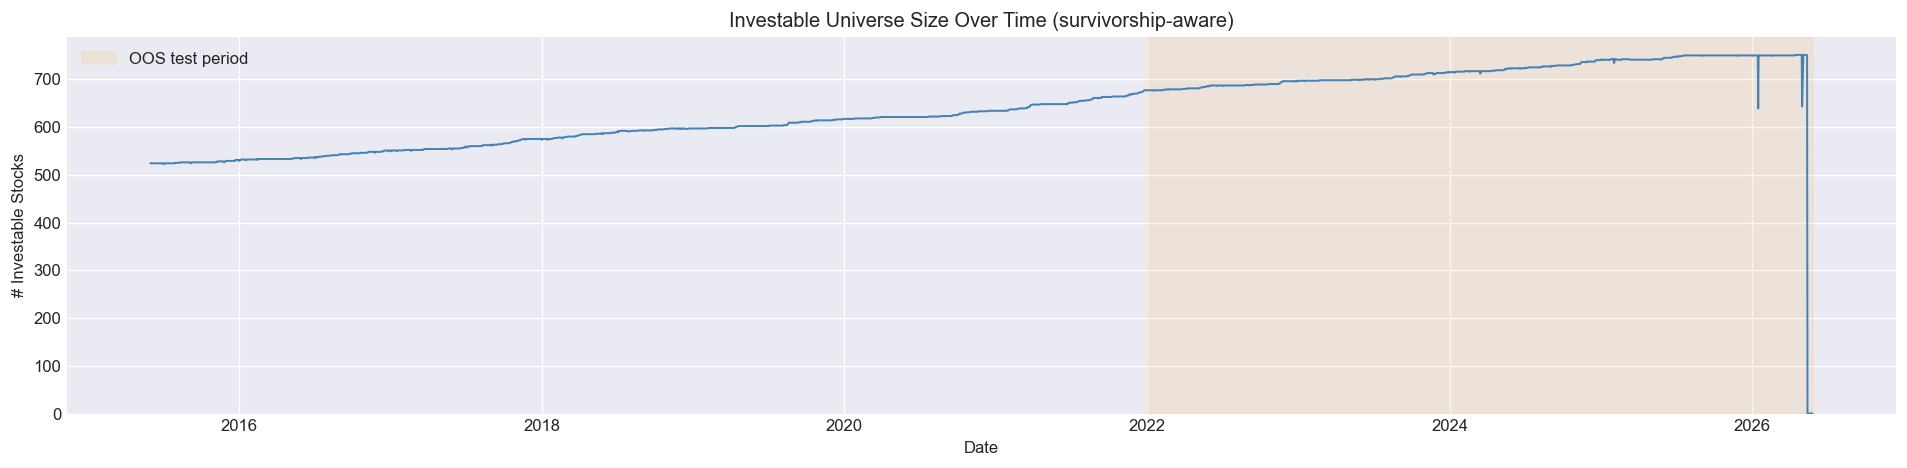

Panels built. Shape: (2714, 756)
Universe size — start: 524, OOS start: 677, end: 0
Date range: 2015-06-01 → 2026-05-26
Universe min (excl. last 20d tail): 522 — should be well above 0 now


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CLEAN each stock's index BEFORE building the panels.
# yfinance returns some series tz-aware and some tz-naive, occasionally with a
# non-midnight timestamp. Aligning those into one panel manufactures "phantom"
# dates holding two or three stocks out of seven hundred, and any later dropna()
# then wipes out most of the sample. Normalise first, align second.
# ─────────────────────────────────────────────────────────────────────────────
def _clean_index(df):
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    try:
        df.index = df.index.tz_localize(None)      # drop timezone if tz-aware
    except (TypeError, AttributeError):
        pass
    df.index = df.index.normalize()                # strip time-of-day → date only
    df = df[~df.index.duplicated(keep="last")]     # dedupe any collisions
    return df.sort_index()

STOCK_DATA = {t: _clean_index(STOCK_DATA[t]) for t in STOCK_DATA}

# Build panels on the cleaned union calendar
CLOSE_PANEL  = pd.DataFrame({t: STOCK_DATA[t]["Close"]  for t in STOCK_DATA}).sort_index()
HIGH_PANEL   = pd.DataFrame({t: STOCK_DATA[t]["High"]   for t in STOCK_DATA}).sort_index()
LOW_PANEL    = pd.DataFrame({t: STOCK_DATA[t]["Low"]    for t in STOCK_DATA}).sort_index()
VOLUME_PANEL = pd.DataFrame({t: STOCK_DATA[t]["Volume"] for t in STOCK_DATA}).sort_index()

# ─────────────────────────────────────────────────────────────────────────────
# Restrict to REAL trading days: a genuine NSE session has broad coverage; a
# phantom date has near-zero coverage. Drop any date below 50% of typical breadth.
# ─────────────────────────────────────────────────────────────────────────────
daily_coverage = CLOSE_PANEL.notna().sum(axis=1)
median_coverage = daily_coverage[daily_coverage > 0].median()
valid_days = daily_coverage >= max(int(0.5 * median_coverage), 20)
n_phantom = int((~valid_days).sum())

for _panel_name in ["CLOSE_PANEL", "HIGH_PANEL", "LOW_PANEL", "VOLUME_PANEL"]:
    globals()[_panel_name] = globals()[_panel_name][valid_days]

RETURN_PANEL = np.log(CLOSE_PANEL / CLOSE_PANEL.shift(1))

print(f"🧹 Removed {n_phantom} phantom dates (timestamp artifacts / non-trading days).")
print(f"   Median daily coverage: {int(median_coverage)} stocks")

# ─────────────────────────────────────────────────────────────────────────────
# INVESTABLE MASK — the heart of the survivorship handling.
# A stock is investable on date t only if it has a price on t AND retains most
# of the next `min_future` observations. The second condition is what stops the
# backtest buying a name the day before it stops trading.
# ─────────────────────────────────────────────────────────────────────────────
def build_investable_mask(close_panel, min_future=20):
    has_price = close_panel.notna()
    future_valid = has_price[::-1].rolling(min_future, min_periods=1).sum()[::-1]
    return has_price & (future_valid >= int(0.5 * min_future))

INVESTABLE = build_investable_mask(CLOSE_PANEL)

# Diagnostics: universe size over time
universe_size = INVESTABLE.sum(axis=1)
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(universe_size.index, universe_size.values, color="steelblue", lw=1.2)
ax.axvspan(pd.Timestamp(CFG["OOS_START"]), pd.Timestamp(CFG["DATA_END"]),
           alpha=0.1, color="orange", label="OOS test period")
ax.set_title("Investable Universe Size Over Time (survivorship-aware)")
ax.set_ylabel("# Investable Stocks"); ax.set_xlabel("Date")
ax.set_ylim(bottom=0)
ax.legend()
plt.tight_layout(); plt.savefig(OUT / "01_universe_size.png", dpi=150); plt.show()

print(f"Panels built. Shape: {CLOSE_PANEL.shape}")
print(f"Universe size — start: {int(universe_size.iloc[0])}, "
      f"OOS start: {int(universe_size.asof(pd.Timestamp(CFG['OOS_START'])))}, "
      f"end: {int(universe_size.iloc[-1])}")
print(f"Date range: {CLOSE_PANEL.index[0].date()} → {CLOSE_PANEL.index[-1].date()}")
print(f"Universe min (excl. last 20d tail): "
      f"{int(universe_size.iloc[:-20].min())} — should be well above 0 now")

## 6b · Value Fundamentals — Point-in-Time P/E and P/B

This section builds the trailing-EPS and book-value-per-share panels that would feed the
value factors (earnings yield = 1/PE, book-to-price = 1/PB).

An honest value factor requires **point-in-time** fundamentals: the figure used on date *t*
must be one that was publicly filed by *t*, and it must exist for firms that have since
delisted. Everything else — current snapshots broadcast backwards, restated financials,
period-end dates used in place of filing dates — introduces look-ahead, survivorship bias,
or both, and any information coefficient measured on top of it is uninterpretable.

The cell below is retained as a reference implementation (derive TTM EPS and BVPS from
quarterly statements, lag by roughly one quarter, forward-fill onto the price calendar,
never zero-fill a missing fundamental) but is **disabled**, because the free source it
relies on does not actually meet the point-in-time requirement over this sample. The next
section documents what was evaluated and what the resulting decision was.

In [8]:
"""# ─────────────────────────────────────────────────────────────────────────────
# DISABLED — reference implementation only, kept for the record.
# See the next cell for why this construction is not usable over this sample.
# ─────────────────────────────────────────────────────────────────────────────
# ─────────────────────────────────────────────────────────────────────────────
# Yahoo does not expose clean *historical* P/E and P/B for NSE names, so we DERIVE
# them point-in-time from fundamentals and price:
#
#   TTM EPS_t  = trailing-4-quarter Net Income  /  shares outstanding   (lagged)
#   BVPS_t     = Total Stockholder Equity        /  shares outstanding   (lagged)
#   P/E_t      = Close_t / TTM_EPS_t        →  factor = earnings yield = 1 / P/E
#   P/B_t      = Close_t / BVPS_t           →  factor = book-to-price   = 1 / P/B
#
# Fundamentals are LAGGED by VAL_REPORT_LAG_DAYS (~1 quarter) and forward-filled,
# so a ratio at date t only uses statements that were public by t (no look-ahead).
# Missing fundamentals → NaN (never 0). A zero would be read downstream as an
# average-value stock rather than an unknown one, and zero-filling has previously
# cascaded through dropna() and destroyed most of a panel.
#
# This pre-computes two daily panels (date × ticker) ONCE; the factor library then
# just looks them up — no per-date network calls.
# ─────────────────────────────────────────────────────────────────────────────
from operator import eq


def _pick_row(frame, names):
    Return the first matching row (by fuzzy label) from a yfinance statement frame.
    if frame is None or frame.empty:
        return None
    idx_upper = {str(i).upper(): i for i in frame.index}
    for want in names:
        for k_up, k in idx_upper.items():
            if want in k_up:
                return frame.loc[k]
    return None

def _quarterly_ttm_eps_and_bvps(tk_obj):
    
    Build quarterly TTM-EPS and BVPS series for one ticker from yfinance.
    Returns (eps_ttm_series, bvps_series) indexed by statement date, or (None,None).
    
    try:
        qfin = tk_obj.quarterly_financials      # income statement (cols = period end)
        qbs  = tk_obj.quarterly_balance_sheet
    except Exception:
        return None, None
    if qfin is None or qfin.empty or qbs is None or qbs.empty:
        return None, None

    ni  = _pick_row(qfin, ["NET INCOME"])
    eq  = _pick_row(qbs,  ["STOCKHOLDERS EQUITY", "TOTAL STOCKHOLDER", "COMMON STOCK EQUITY"])
    sh  = _pick_row(qbs,  ["SHARE ISSUED", "ORDINARY SHARES NUMBER", "COMMON STOCK SHARES",
                           "SHARES OUTSTANDING"])
    if ni is None or eq is None:
        return None, None

    ni  = ni.dropna().sort_index()
    eq  = eq.dropna().sort_index()
    # shares: prefer balance-sheet shares; fall back to .info later
    shares = None
    if sh is not None and sh.dropna().shape[0] > 0:
        shares = sh.dropna().sort_index()

    if shares is None or shares.empty:
        try:
            so = tk_obj.info.get("sharesOutstanding", None)
        except Exception:
            so = None
        if so and so > 0:
            shares = pd.Series(float(so), index=eq.index)
        else:
            return None, None
                
    # ============================================================
# Align all statement series onto common quarterly calendar
# ============================================================

    common_idx = ni.index.union(eq.index)

    shares = (
    shares
    .reindex(common_idx)
    .sort_index()
    .ffill()
    .bfill()
)

    shares = shares.replace(0, np.nan)

    ni_aligned = (
    ni
    .reindex(common_idx)
    .sort_index()
    .ffill()
)

    eq_aligned = (
    eq
    .reindex(common_idx)
    .sort_index()
    .ffill()
)

# TTM net income
    ni_ttm = ni_aligned.rolling(4, min_periods=2).sum()

    eps_ttm = ni_ttm / shares
    bvps = eq_aligned / shares

    eps_ttm = eps_ttm.replace([np.inf, -np.inf], np.nan)
    bvps = bvps.replace([np.inf, -np.inf], np.nan)

    eps_ttm = eps_ttm.dropna()
    bvps = bvps.dropna()
    return eps_ttm, bvps

def build_value_panels(stock_data, close_panel_index, report_lag_days=75):
    Construct daily point-in-time TTM-EPS and BVPS panels for all tickers.
    eps_cols, bvps_cols = {}, {}
    tickers = list(stock_data.keys())
    n_ok = 0
    for j, t in enumerate(tickers):
        if j % 50 == 0:
            print(f"   fundamentals {j}/{len(tickers)} …", flush=True)
        try:
            tk = yf.Ticker(t)
            eps_ttm, bvps = _quarterly_ttm_eps_and_bvps(tk)
        except Exception:
            eps_ttm, bvps = None, None
        if eps_ttm is None and bvps is None:
            continue
        # lag statement dates, then forward-fill onto the daily calendar
        if eps_ttm is not None and not eps_ttm.empty:
            s = eps_ttm.copy()
            s.index = pd.to_datetime(s.index) + pd.Timedelta(days=report_lag_days)
            eps_cols[t] = s[~s.index.duplicated(keep="last")].sort_index()
        if bvps is not None and not bvps.empty:
            s = bvps.copy()
            s.index = pd.to_datetime(s.index) + pd.Timedelta(days=report_lag_days)
            bvps_cols[t] = s[~s.index.duplicated(keep="last")].sort_index()
        n_ok += 1

    cal = pd.DatetimeIndex(close_panel_index)
    def _to_panel(cols):
        if not cols:
            return pd.DataFrame(index=cal)
        df = pd.DataFrame(cols)
        df = df[~df.index.duplicated(keep="last")].sort_index()
        # reindex onto trading calendar, forward-fill known fundamentals
        return df.reindex(df.index.union(cal)).ffill().reindex(cal)
    eps_panel  = _to_panel(eps_cols)
    bvps_panel = _to_panel(bvps_cols)
    print(f"   ✔ fundamentals retrieved for {n_ok}/{len(tickers)} tickers")
    return eps_panel, bvps_panel


print("📥 Building point-in-time value (P/E, P/B) panels from yfinance fundamentals …")
print("    (one fundamentals fetch per ticker; several minutes)\n")
# CLOSE_PANEL is built in the next stage; if this cell is run first, fall back to a
# daily business-day calendar spanning the sample.
try:
    _val_cal = CLOSE_PANEL.index
except NameError:
    _val_cal = pd.bdate_range(CFG["DATA_START"], CFG["DATA_END"])

EPS_TTM_PANEL, BVPS_PANEL = build_value_panels(
    STOCK_DATA, _val_cal, report_lag_days=CFG["VAL_REPORT_LAG_DAYS"])
print("\n=== VALUE PANEL DIAGNOSTICS ===")

print(
    "EPS coverage:",
    round(
        100 * EPS_TTM_PANEL.notna().sum().sum()
        / EPS_TTM_PANEL.size,
        2
    ),
    "%"
)

print(
    "BVPS coverage:",
    round(
        100 * BVPS_PANEL.notna().sum().sum()
        / BVPS_PANEL.size,
        2
    ),
    "%"
)

sample_date = pd.Timestamp("2022-01-01")

print(
    "\nNon-null EPS on sample date:",
    EPS_TTM_PANEL.loc[:sample_date].iloc[-1].notna().sum()
)

print(
    "Non-null BVPS on sample date:",
    BVPS_PANEL.loc[:sample_date].iloc[-1].notna().sum()
)
print(f"\n✅ Value panels built.")
print(f"   EPS(TTM) panel : {EPS_TTM_PANEL.shape}  | non-null cols: {EPS_TTM_PANEL.notna().any().sum()}")
print(f"   BVPS panel     : {BVPS_PANEL.shape}  | non-null cols: {BVPS_PANEL.notna().any().sum()}")
"""

'# ===== [V5 · NEW cell: Value fundamentals] build point-in-time P/E and P/B panels (Section F) =====\n# ─────────────────────────────────────────────────────────────────────────────\n# Yahoo does not expose clean *historical* P/E and P/B for NSE names, so we DERIVE\n# them point-in-time from fundamentals and price:\n#\n#   TTM EPS_t  = trailing-4-quarter Net Income  /  shares outstanding   (lagged)\n#   BVPS_t     = Total Stockholder Equity        /  shares outstanding   (lagged)\n#   P/E_t      = Close_t / TTM_EPS_t        →  factor = earnings yield = 1 / P/E\n#   P/B_t      = Close_t / BVPS_t           →  factor = book-to-price   = 1 / P/B\n#\n# Fundamentals are LAGGED by VAL_REPORT_LAG_DAYS (~1 quarter) and forward-filled,\n# so a ratio at date t only uses statements that were public by t (no look-ahead).\n# Missing fundamentals → NaN (never 0): such names are simply neutral on value,\n# they are NEVER zero-filled (that is the v3/v4 lesson that collapsed correlations).\n#\n# This p

In [9]:
# ═════════════════════════════════════════════════════════════════════════════
# VALUE FACTORS — POINT-IN-TIME SWITCH
#
# WHAT AN HONEST VALUE FACTOR REQUIRES
#
# The fundamental used on date t must be one that was publicly filed by t, and
# it must exist for firms that have since delisted. The obvious shortcut —
# reading yf.Ticker(t).info["trailingEps"] and ["bookValue"] and broadcasting
# that single CURRENT observation across the whole 2015→2026 index — fails both
# tests at once:
#   (i)  LOOK-AHEAD. earnings_yield on 2016-03-01 would use EPS reported in 2026.
#        The tell is the coverage diagnostic: a constant, forward- and back-
#        filled series is the only way a fundamental panel reaches 100% coverage
#        across eleven years.
#   (ii) SURVIVORSHIP. `.info` returns nothing for delisted names, so the value
#        family would exist only for firms still listed at the end of the sample.
# Any IC attributed to earnings_yield / book_to_price under that construction is
# uninterpretable and cannot go in a results table.
#
# ═════════════════════════════════════════════════════════════════════════════
# WHAT WAS EVALUATED AS A REPLACEMENT  (coverage / PIT-correctness / India / delisted)
#
#  yfinance .info trailingEps, bookValue
#     coverage: 1 current point.  PIT: NO.  India: yes.  Delisted: NO.        ✗
#  yfinance quarterly_income_stmt / quarterly_balance_sheet / quarterly_cashflow
#     coverage: Yahoo serves ~4–5 quarters (and ~4 annual years). Reaches back
#     roughly to 2024 — the sample starts 2015.  PIT: NO — period-end dates only,
#     no filing/announcement date, and figures are as-restated.
#     India: partial.  Delisted: NO.                                          ✗
#  yfinance earnings_history / earnings_dates
#     coverage: last ~4 quarters.  PIT: YES (carries an announcement date) —
#     the only PIT-correct yfinance field, but four quarters cannot span 2015–2026.
#     India: partial.  Delisted: NO.                                          ✗
#  yfinance get_valuation_measures(freq="quarterly")
#     coverage: a handful of periods, thin outside US large caps.  PIT: NO.
#     India: unreliable.  Delisted: NO.                                       ✗
#  NSE corporate filings — financial results (XBRL/PDF, with submission dates)
#     coverage: full.  PIT: YES — the filing timestamp is the true information
#     date.  India: native.  Delisted: partial/unreliable archive.
#     BUT: no bulk endpoint, per-company scraping + XBRL parsing, weeks of work,
#     and aggressive rate limiting.                                     (future)
#  Screener.in / Trendlyne / Tickertape scrapes
#     coverage: good.  PIT: NO — restated current financials, no as-reported
#     filing dates.  Delisted: NO.  Also against site terms.                  ✗
#  CMIE Prowess / Capitaline / Refinitiv / S&P Capital IQ / Compustat Global / EODHD
#     coverage: full.  PIT: YES (as-reported + filing dates).  India: native
#     for Prowess/Capitaline.  Delisted: YES.  PAID — Prowess and Capitaline are
#     the Indian academic standard and are commonly available through a
#     university library subscription. WORTH CHECKING AT NIT ROURKELA.        ✓$
#
# CONCLUSION: no FREE source supplies point-in-time Indian fundamentals with
# filing dates across 2015–2026 including delisted names. The headline
# configuration therefore DROPS the value family (VALUE_MODE = "off") and states
# it as a scope limitation. The contribution here is the regime-conditioned
# Black-Litterman allocation, not a value anomaly, so the cost is two factors out
# of fifteen — and it lightens the multiple-testing burden at the same time.
# If Prowess / Capitaline / EODHD access is obtained, set VALUE_MODE = "pit_csv"
# and the value-augmented specification returns as a robustness appendix.
# ═════════════════════════════════════════════════════════════════════════════

def _empty_value_panels(index):
    return (pd.DataFrame(index=index, dtype=float),
            pd.DataFrame(index=index, dtype=float))


def build_value_panels_pit(csv_path, close_index, extra_lag_days=0):
    """
    Point-in-time value panels from a vendor extract.

    Required columns:
        ticker       NSE symbol, with or without the '.NS' suffix
        period_end   fiscal period end date               (informational)
        filing_date  date the figure became PUBLIC        ← the information date
        eps_ttm      trailing-twelve-month EPS (INR/share)
        bvps         book value per share    (INR/share)

    Each observation is stamped at filing_date (+ optional extra lag) and
    forward-filled. Nothing is ever stamped at period_end, so by construction no
    figure is visible before the market could have seen it.
    """
    raw = pd.read_csv(csv_path)
    raw.columns = [c.strip().lower() for c in raw.columns]
    need = {"ticker", "filing_date", "eps_ttm", "bvps"}
    if not need.issubset(raw.columns):
        raise ValueError(f"{csv_path}: missing columns {need - set(raw.columns)}")

    raw["ticker"] = raw["ticker"].astype(str).str.upper().str.replace(".NS", "", regex=False) + ".NS"
    raw["info_date"] = (pd.to_datetime(raw["filing_date"])
                        + pd.Timedelta(days=int(extra_lag_days))).dt.normalize()
    raw = raw.dropna(subset=["info_date"]).sort_values("info_date")

    eps = (raw.pivot_table(index="info_date", columns="ticker",
                           values="eps_ttm", aggfunc="last")
              .reindex(close_index).ffill())
    bvp = (raw.pivot_table(index="info_date", columns="ticker",
                           values="bvps", aggfunc="last")
              .reindex(close_index).ffill())
    return eps, bvp


def build_value_panels_info_snapshot(stock_data, close_index):
    """
    Current .info fundamentals broadcast across all history.

    LOOK-AHEAD + SURVIVOR BIASED by construction. Retained ONLY as a leakage
    ablation, so the size of the bias can be measured. Never report a result
    produced under this mode.
    """
    eps_d, bvp_d = {}, {}
    tickers = list(stock_data.keys())
    print(f"⚠ Fetching Yahoo .info fundamentals for {len(tickers)} stocks (BIASED MODE) …")
    for i, tk in enumerate(tickers):
        if i % 100 == 0:
            print(f"   {i}/{len(tickers)}", flush=True)
        try:
            info = yf.Ticker(tk).info
            e, b = info.get("trailingEps", np.nan), info.get("bookValue", np.nan)
            if e is not None and np.isfinite(float(e)):
                eps_d[tk] = float(e)
            if b is not None and np.isfinite(float(b)):
                bvp_d[tk] = float(b)
        except Exception:
            continue
    eps = pd.DataFrame({t: pd.Series(v, index=close_index) for t, v in eps_d.items()})
    bvp = pd.DataFrame({t: pd.Series(v, index=close_index) for t, v in bvp_d.items()})
    return eps, bvp


# ── dispatch ─────────────────────────────────────────────────────────────────
_mode = CFG["VALUE_MODE"]
print(f"📥 Value factor construction — VALUE_MODE = '{_mode}'")

if _mode == "off":
    EPS_TTM_PANEL, BVPS_PANEL = _empty_value_panels(CLOSE_PANEL.index)
    VALUE_AVAILABLE = False
    print("   Value family DISABLED (no free point-in-time source for Indian equities).")
    print("   earnings_yield and book_to_price will be dropped from ACTIVE_FACTORS,")
    print("   from the IC tables, from the factor-weighting scheme and from the")
    print("   LightGBM feature set. This is the headline publication configuration.")

elif _mode == "pit_csv":
    _p = Path(CFG["VALUE_PIT_FILE"])
    if not _p.exists():
        raise FileNotFoundError(
            f"VALUE_MODE='pit_csv' but {_p} not found. Supply a vendor extract with "
            "columns ticker, period_end, filing_date, eps_ttm, bvps — or set "
            "CFG['VALUE_MODE']='off'.")
    EPS_TTM_PANEL, BVPS_PANEL = build_value_panels_pit(
        _p, CLOSE_PANEL.index, CFG["VALUE_PIT_EXTRA_LAG_D"])
    VALUE_AVAILABLE = True
    print(f"   Loaded PIT fundamentals from {_p}")

elif _mode == "info_snapshot":
    EPS_TTM_PANEL, BVPS_PANEL = build_value_panels_info_snapshot(
        STOCK_DATA, CLOSE_PANEL.index)
    VALUE_AVAILABLE = True
    print("\n" + "!" * 72)
    print("!! VALUE_MODE='info_snapshot': LOOK-AHEAD AND SURVIVORSHIP BIASED.")
    print("!! Diagnostic / ablation use only. Do NOT report these results.")
    print("!" * 72)
else:
    raise ValueError(f"Unknown VALUE_MODE: {_mode}")

# ── coverage diagnostics (a genuine PIT panel must NOT show 100% everywhere) ──
if VALUE_AVAILABLE and EPS_TTM_PANEL.shape[1] > 0:
    _cov = pd.DataFrame({
        "eps_cov":  EPS_TTM_PANEL.notna().mean(axis=1),
        "bvps_cov": BVPS_PANEL.notna().mean(axis=1),
    }).resample("YE").mean().round(3)
    print("\n=== Value panel coverage by year (fraction of tickers) ===")
    print(_cov.to_string())
    print("\n   Sanity check: a true point-in-time panel starts near zero and "
          "ramps up.\n   A flat 1.00 across all years indicates a constant "
          "broadcast (look-ahead).")
    print(f"   EPS tickers: {EPS_TTM_PANEL.shape[1]}   BVPS tickers: {BVPS_PANEL.shape[1]}")

print("\n✅ Value panels ready.")


📥 Value factor construction — VALUE_MODE = 'off'
   Value family DISABLED (no free point-in-time source for Indian equities).
   earnings_yield and book_to_price will be dropped from ACTIVE_FACTORS,
   from the IC tables, from the factor-weighting scheme and from the
   LightGBM feature set. This is the headline publication configuration.

✅ Value panels ready.


## 7 · Statistical Diagnostics — Stationarity

Standard pre-modelling checks on the price and return series, run on the eight most liquid
names for speed.

- **ADF** tests the null of a unit root. Prices should *fail* to reject (non-stationary);
  returns should reject decisively.
- **KPSS** tests the complementary null of stationarity, so the two together give a much
  clearer verdict than either alone.

The interpolation warnings printed by `statsmodels` are expected: the KPSS test statistic
falls outside its lookup table, meaning the true p-value is more extreme than the one
reported. That is a stronger result, not a weaker one.

The cross-sectional diagnostics (factor correlation and VIF) live in §9, after the factor
library exists.

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# 7.1 ADF + KPSS on a representative set of stocks (price vs return)
# ─────────────────────────────────────────────────────────────────────────────
def adf_kpss(series):
    s = series.dropna()
    out = {}
    try:
        out["ADF_p"] = round(adfuller(s, autolag="AIC")[1], 4)
    except Exception:
        out["ADF_p"] = np.nan
    try:
        out["KPSS_p"] = round(kpss(s, regression="c", nlags="auto")[1], 4)
    except Exception:
        out["KPSS_p"] = np.nan
    return out

# Test on the 8 most liquid stocks (by avg volume) for speed
liquid = VOLUME_PANEL.mean().sort_values(ascending=False).head(8).index
diag_rows = []
for t in liquid:
    price_d = adf_kpss(CLOSE_PANEL[t])
    ret_d   = adf_kpss(RETURN_PANEL[t])
    diag_rows.append({
        "Ticker": t,
        "Price_ADF_p"  : price_d["ADF_p"],   "Price_KPSS_p" : price_d["KPSS_p"],
        "Return_ADF_p" : ret_d["ADF_p"],     "Return_KPSS_p": ret_d["KPSS_p"],
    })
diag_df = pd.DataFrame(diag_rows)
print("=== Stationarity Diagnostics (p-values) ===")
print("  Expectation: prices NON-stationary (ADF p>0.05), returns stationary (ADF p<0.05)\n")
print(diag_df.to_string(index=False))
diag_df.to_csv(OUT / "stationarity_diagnostics.csv", index=False)


C:\Users\hp\AppData\Local\Temp\ipykernel_19828\602114164.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  out["KPSS_p"] = round(kpss(s, regression="c", nlags="auto")[1], 4)
C:\Users\hp\AppData\Local\Temp\ipykernel_19828\602114164.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  out["KPSS_p"] = round(kpss(s, regression="c", nlags="auto")[1], 4)
C:\Users\hp\AppData\Local\Temp\ipykernel_19828\602114164.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  out["KPSS_p"] = round(kpss(s, regression="c", nlags="auto")[1], 4)
C:\Users\hp\AppData\Local\Temp\ipykernel_19828\602114164.py:12: InterpolationWarning: The test stati

=== Stationarity Diagnostics (p-values) ===
  Expectation: prices NON-stationary (ADF p>0.05), returns stationary (ADF p<0.05)

       Ticker  Price_ADF_p  Price_KPSS_p  Return_ADF_p  Return_KPSS_p
      IDEA.NS       0.0008          0.01           0.0          0.100
   YESBANK.NS       0.6834          0.01           0.0          0.100
 TATASTEEL.NS       0.9842          0.01           0.0          0.100
   OLAELEC.NS       0.5875          0.01           0.0          0.100
ADANIPOWER.NS       0.9984          0.01           0.0          0.100
   ETERNAL.NS       0.8439          0.01           0.0          0.100
    SUZLON.NS       0.8968          0.01           0.0          0.056
       IRB.NS       0.7807          0.01           0.0          0.100


C:\Users\hp\AppData\Local\Temp\ipykernel_19828\602114164.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  out["KPSS_p"] = round(kpss(s, regression="c", nlags="auto")[1], 4)


## 8 · ADX Trend-Strength Filter

The **Average Directional Index** measures how strongly a market is trending, without saying
in which direction. That makes it a natural gate for the perennial factor conflict: momentum
and mean-reversion both work, but not at the same time.

- **ADX > 25** — trending market → momentum and relative strength are up-weighted, mean
  reversion is damped.
- **ADX < 20** — choppy, range-bound market → the reverse.
- **In between** — no adjustment.

ADX is computed on genuine NIFTY 500 High/Low/Close data. If that download fails, the cell
raises rather than reconstructing a proxy: ADX built from a synthetic high/low would be an
indicator of the reconstruction, not of the market.

In this sample the market is trending 41.1% of days and choppy 41.0%, so the gate is
genuinely two-sided rather than a permanent tilt in one direction.

📥 Downloading NIFTY 500 real OHLC for ADX …
  ✔ NIFTY 500: 2703 rows, real OHLC


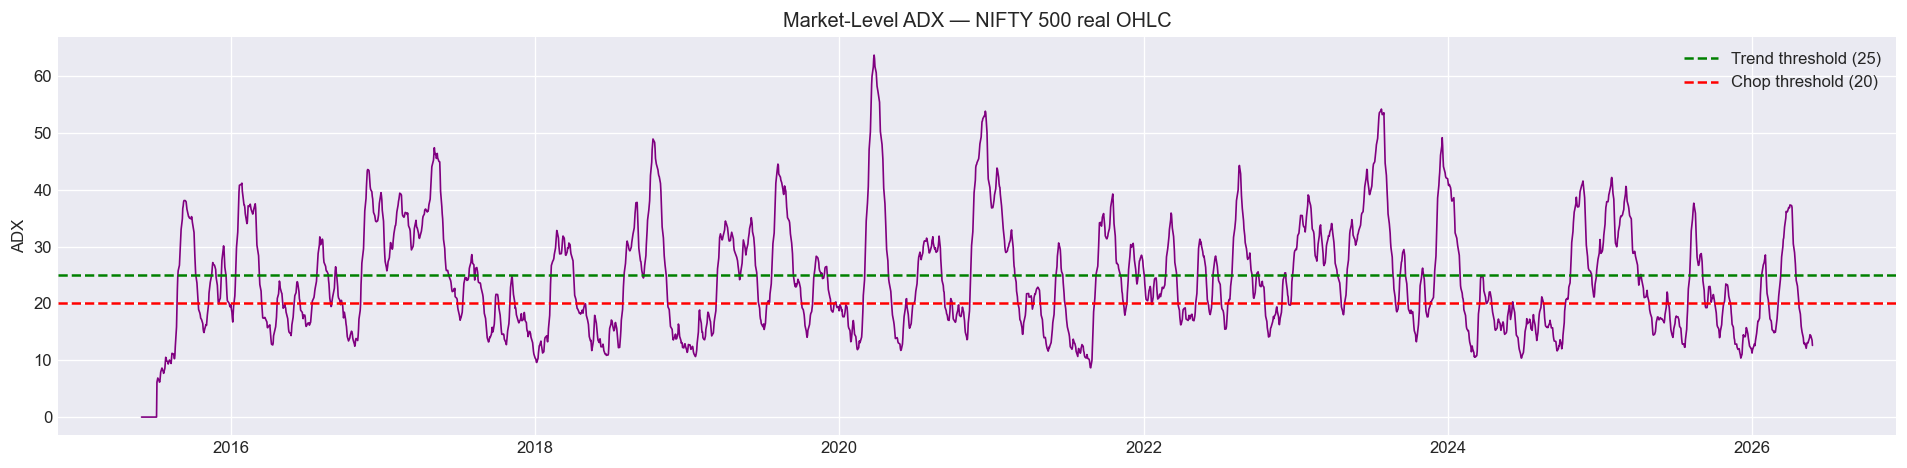

ADX source          : NIFTY 500 real OHLC (^CRSLDX)
Market trending (ADX>25): 41.1% of days
ADX range           : [0.0, 63.7]


In [11]:
import ta

# ─────────────────────────────────────────────────────────────────────────────
# Download REAL NIFTY 500 OHLC. If unavailable → stop. No reconstruction, no proxy.
# ─────────────────────────────────────────────────────────────────────────────
def download_nifty500_ohlc(start, end):
    try:
        df = yf.download("^CRSLDX", start=start, end=end,
                         auto_adjust=True, progress=False)
        if df.empty or len(df) < 100:
            return None
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        df.index = pd.to_datetime(df.index).normalize()
        df = df[~df.index.duplicated(keep="last")].sort_index()
        if not all(c in df.columns for c in ["High", "Low", "Close"]):
            return None
        return df
    except Exception:
        return None

print("📥 Downloading NIFTY 500 real OHLC for ADX …")
NIFTY500_OHLC = download_nifty500_ohlc(CFG["DATA_START"], CFG["DATA_END"])

if NIFTY500_OHLC is None:
    print("NO — NIFTY 500 real OHLC not available from yfinance.")
    print("    ADX cannot be computed without genuine High/Low/Close data.")
    print("    Aborting this cell. Provide OHLC manually or use a different source.")
    raise RuntimeError("NIFTY 500 OHLC unavailable; ADX step halted.")

print(f"  ✔ NIFTY 500: {len(NIFTY500_OHLC)} rows, real OHLC")

# ─────────────────────────────────────────────────────────────────────────────
# Compute ADX with ta.trend.ADXIndicator on real NIFTY 500 OHLC
# ─────────────────────────────────────────────────────────────────────────────
idx = CLOSE_PANEL.index
h = NIFTY500_OHLC["High"].reindex(idx).ffill()
l = NIFTY500_OHLC["Low"].reindex(idx).ffill()
c = NIFTY500_OHLC["Close"].reindex(idx).ffill()

MARKET_ADX = ta.trend.ADXIndicator(
    high=h, low=l, close=c, window=CFG["ADX_PERIOD"], fillna=False
).adx().reindex(idx).ffill()

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(MARKET_ADX.index, MARKET_ADX.values, color="purple", lw=1)
ax.axhline(CFG["ADX_TREND_THRESH"], color="green", linestyle="--",
           label=f"Trend threshold ({CFG['ADX_TREND_THRESH']})")
ax.axhline(20, color="red", linestyle="--", label="Chop threshold (20)")
ax.set_title("Market-Level ADX — NIFTY 500 real OHLC")
ax.set_ylabel("ADX"); ax.legend()
plt.tight_layout(); plt.savefig(OUT / "02_market_adx.png", dpi=150); plt.show()

pct_trending = (MARKET_ADX > CFG["ADX_TREND_THRESH"]).mean() * 100
print(f"ADX source          : NIFTY 500 real OHLC (^CRSLDX)")
print(f"Market trending (ADX>{CFG['ADX_TREND_THRESH']}): {pct_trending:.1f}% of days")
print(f"ADX range           : [{MARKET_ADX.min():.1f}, {MARKET_ADX.max():.1f}]")

### ADX Regime Breakdown

Day counts behind the percentages above, split across the three ADX bands used by the
factor gate.

In [12]:
# ADX regime statistics
trend_days = (MARKET_ADX > 25).sum()
chop_days  = (MARKET_ADX < 20).sum()
neutral_days = ((MARKET_ADX >= 20) & (MARKET_ADX <= 25)).sum()


total_days = MARKET_ADX.notna().sum()


print(f"Trending (ADX > 25):      {trend_days:5d} days ({100*trend_days/total_days:.1f}%)")
print(f"Neutral (20 ≤ ADX ≤ 25): {neutral_days:5d} days ({100*neutral_days/total_days:.1f}%)")
print(f"Choppy (ADX < 20):       {chop_days:5d} days ({100*chop_days/total_days:.1f}%)")

Trending (ADX > 25):       1115 days (41.1%)
Neutral (20 ≤ ADX ≤ 25):   486 days (17.9%)
Choppy (ADX < 20):        1113 days (41.0%)


## 9 · Factor Library

Fifteen factors are computed across seven families; twelve of them are active. Every factor
is written so that a **higher value is a better expected outcome**, which is why several
carry a `neg_` prefix — low volatility is desirable, so the factor is negative volatility.

| Family | Factors | Idea |
|---|---|---|
| Momentum | `mom_1m`, `mom_3m`, `mom_6m_skip` | Recent winners keep winning; the 6-month version skips the most recent month to avoid short-term reversal. |
| Quality | `vol_of_vol`, `ret_stability` | Stable, well-behaved return processes. |
| Low-Vol | `neg_vol_63`, `neg_downside_vol` | The low-volatility anomaly, total and downside-only. |
| Liquidity | `log_adv`, `neg_amihud` | Traded value and Amihud price impact. |
| Mean-Reversion | `neg_zscore_200ma`, `short_reversal_5d` | Distance from the 200-day mean; one-week reversal. |
| Relative-Strength | `mkt_rel_strength`, `sector_rel_strength` | 21-day return in excess of the market and of the sector index. |
| Value | `earnings_yield`, `book_to_price` | Cheapness, from the fundamentals panels. |

**Three factors are computed but excluded from the active set:**

- `mkt_rel_strength` is dropped on multicollinearity grounds — its VIF is 14.3, and it is
  close to a linear combination of sector relative strength and momentum (see the next
  cell).
- `earnings_yield` and `book_to_price` are dropped because `VALUE_MODE = "off"`; with no
  point-in-time fundamentals they would be all-NaN columns.

All three are still *calculated* so the diagnostics can demonstrate why, and so that
switching value back on requires no change to the factor code.

Two implementation details worth noting. Missing value data yields **NaN, never zero** — a
zero would be read downstream as an average-value stock rather than an unknown one, and
zero-filling has previously cascaded through `dropna()` and destroyed most of a panel.
And factor frames are memoised in `FACTOR_CACHE`, which matters because the walk-forward
requests the same as-of dates repeatedly.

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# FACTOR LIBRARY — 15 factors in 7 families, 12 of them active.
# Every factor is signed so that HIGHER IS BETTER, which is why several carry a
# `neg_` prefix (low volatility is desirable, so the factor is -volatility).
# ─────────────────────────────────────────────────────────────────────────────
# Pre-compute index returns for relative strength
MARKET_RET = np.log(MARKET_INDEX / MARKET_INDEX.shift(1)) if MARKET_INDEX is not None else None
SECTOR_INDEX_RET = {s: np.log(p / p.shift(1)) for s, p in SECTOR_INDEX_DATA.items()}

FACTOR_FAMILIES = {
    "Momentum"      : ["mom_1m", "mom_3m", "mom_6m_skip"],
    "Quality"       : ["vol_of_vol", "ret_stability"],
    "Low-Vol"       : ["neg_vol_63", "neg_downside_vol"],
    "Liquidity"     : ["log_adv", "neg_amihud"],
    "Mean-Reversion": ["neg_zscore_200ma", "short_reversal_5d"],
    "Relative-Str"  : ["mkt_rel_strength", "sector_rel_strength"],
    "Value"         : ["earnings_yield", "book_to_price"],   # from the fundamentals panels
}
ALL_FACTORS = [f for fam in FACTOR_FAMILIES.values() for f in fam]

# Market relative strength has too high a VIF (14.3) and is close to a linear
# combination of sector relative strength and momentum, so it is dropped from the
# ACTIVE set used by the IC tables, the weighting scheme, the selection score and
# the ML model. It is still COMPUTED so the VIF/correlation diagnostic can show
# exactly why it was removed.
REMOVED_FACTORS = ["mkt_rel_strength"]
# With no free point-in-time source for Indian fundamentals the value family is
# also dropped from the ACTIVE set (see §6b). Still computed, so the diagnostics
# and the pit_csv mode keep working without touching this code.
if CFG["VALUE_MODE"] == "off":
    REMOVED_FACTORS = REMOVED_FACTORS + ["earnings_yield", "book_to_price"]
ACTIVE_FACTORS  = [f for f in ALL_FACTORS if f not in REMOVED_FACTORS]

# Momentum-like vs mean-reversion-like buckets, used by the ADX gate in §13.
MOMENTUM_FACTORS = ["mom_1m","mom_3m","mom_6m_skip","sector_rel_strength"]
MEANREV_FACTORS  = ["neg_zscore_200ma","short_reversal_5d"]
VALUE_FACTORS    = ["earnings_yield","book_to_price"]

def _idx_ret_to_date(ret_series, as_of, window=21):
    if ret_series is None: return 0.0
    r = ret_series[ret_series.index <= as_of].dropna()
    return float(r.iloc[-window:].sum()) if len(r) >= window else 0.0

def _value_row(panel, as_of):
    """Point-in-time row (values known on/before as_of). Empty Series if panel empty."""
    if panel is None or panel.shape[1] == 0:
        return pd.Series(dtype=float)
    sub = panel[panel.index <= as_of]
    return sub.iloc[-1] if len(sub) else pd.Series(dtype=float)

def compute_factors_v5(close_panel, return_panel, volume_panel,
                       as_of_date, lookback=252):
    """
    Compute the full cross-section of factor exposures as of `as_of_date`.

    Only data at or before `as_of_date` is ever touched, so the frame is causal
    by construction. Value factors are read from the pre-computed EPS_TTM_PANEL /
    BVPS_PANEL rather than fetched per date. Missing value data yields NaN, never
    0 — a zero would be read downstream as an average-value stock.
    """
    hist_close = close_panel[close_panel.index <= as_of_date]
    hist_rets  = return_panel[return_panel.index <= as_of_date]
    hist_vol   = volume_panel[volume_panel.index <= as_of_date]

    mkt_ret_21 = _idx_ret_to_date(MARKET_RET, as_of_date, 21)
    sector_ret_21 = {s: _idx_ret_to_date(SECTOR_INDEX_RET[s], as_of_date, 21)
                     for s in SECTOR_INDEX_RET}

    # Point-in-time value inputs (TTM EPS and BVPS as known at as_of_date)
    eps_row  = _value_row(EPS_TTM_PANEL, as_of_date)
    bvps_row = _value_row(BVPS_PANEL,    as_of_date)

    recs = []
    for ticker in close_panel.columns:
        c = hist_close[ticker].dropna()
        r = hist_rets[ticker].dropna()
        v = hist_vol[ticker].dropna()
        if len(c) < 60 or len(r) < 60:
            continue
        c_lb = c.iloc[-lookback:]; r_lb = r.iloc[-lookback:]; v_lb = v.iloc[-lookback:]
        price = float(c.iloc[-1])

        # Momentum
        mom_1m = float(c.iloc[-1]/c.iloc[-22] - 1) if len(c) >= 22 else 0.0
        mom_3m = float(c.iloc[-1]/c.iloc[-64] - 1) if len(c) >= 64 else 0.0
        mom_6m_skip = float(c.iloc[-22]/c.iloc[-148] - 1) if len(c) >= 148 else mom_3m

        # Quality
        vov = float(r.rolling(21).std().dropna().iloc[-42:].std()) if len(r) >= 63 else 0.0
        if len(r) >= 252:
            mret = r.resample("ME").sum()
            ret_stab = -float(mret.iloc[-12:].std()) if len(mret) >= 6 else 0.0
        else:
            ret_stab = 0.0

        # Low-vol
        vol_63 = float(r.iloc[-63:].std()*np.sqrt(TRADING_DAYS)) if len(r) >= 63 else 1.0
        neg_rets = r.iloc[-63:][r.iloc[-63:] < 0] if len(r) >= 63 else pd.Series(dtype=float)
        dvol = float(neg_rets.std()*np.sqrt(TRADING_DAYS)) if len(neg_rets) > 5 else vol_63

        # Liquidity
        adv = v_lb.iloc[-63:].mean()*c_lb.iloc[-63:].mean() if len(v_lb) >= 63 else 1.0
        log_adv = float(np.log(adv + 1))
        if len(r) >= 63 and len(v) >= 63:
            ilr = (r.iloc[-63:].abs()/(v.iloc[-63:]*c.iloc[-63:]+1e-9)).mean()*1e9
            neg_amihud = -float(ilr)
        else:
            neg_amihud = 0.0
        
        # Mean reversion
        if len(c) >= 200:
            ma = float(c.iloc[-200:].mean()); sd = float(c.iloc[-200:].std())
            neg_z = -float((c.iloc[-1]-ma)/(sd+1e-9))
        else:
            neg_z = 0.0
        short_rev = -float(c.iloc[-1]/c.iloc[-6] - 1) if len(c) >= 6 else 0.0

        # Relative strength against REAL indices. Any stock in 'Other', or in a
        # sector whose index is unavailable, falls back to the market benchmark
        # rather than to a proxy built from the stock pool itself.
        stock_ret_21 = float(c.iloc[-1]/c.iloc[-22] - 1) if len(c) >= 22 else 0.0
        mkt_rel = stock_ret_21 - mkt_ret_21
        sec = SECTOR_MAP.get(ticker, "Other")
        sec_bench = sector_ret_21.get(sec, mkt_ret_21)   # fallback → market benchmark
        sector_rel = stock_ret_21 - sec_bench

        # Value family: earnings yield (E/P) and book-to-price (B/P).
        # Higher = cheaper. NaN when fundamentals are missing, never 0.
        eps = float(eps_row.get(ticker, np.nan)) if len(eps_row) else np.nan
        bvp = float(bvps_row.get(ticker, np.nan)) if len(bvps_row) else np.nan
        earnings_yield = (eps / price) if (np.isfinite(eps) and price > 0) else np.nan
        book_to_price  = (bvp / price) if (np.isfinite(bvp) and bvp > 0 and price > 0) else np.nan

        recs.append({
            "Ticker":ticker, "mom_1m":mom_1m, "mom_3m":mom_3m, "mom_6m_skip":mom_6m_skip,
            "vol_of_vol":-vov, "ret_stability":ret_stab,
            "neg_vol_63":-vol_63, "neg_downside_vol":-dvol,
            "log_adv":log_adv, "neg_amihud":neg_amihud,
            "neg_zscore_200ma":neg_z, "short_reversal_5d":short_rev,
            "mkt_rel_strength":mkt_rel, "sector_rel_strength":sector_rel,
            "earnings_yield":earnings_yield, "book_to_price":book_to_price,
        })
    return pd.DataFrame(recs).set_index("Ticker") if recs else pd.DataFrame()
    # ============================================================
# FACTOR CACHE
# The walk-forward asks for the same as-of dates repeatedly, and recomputing the
# whole cross-section each time dominates the runtime. Memoise on the date.
# ============================================================

FACTOR_CACHE = {}

def get_factors_v5(close_panel, return_panel, volume_panel, asof_date):
    """
    Memoised wrapper around the factor computation, keyed on the as-of date.
    """
    asof_date = pd.Timestamp(asof_date)

    if asof_date not in FACTOR_CACHE:
        FACTOR_CACHE[asof_date] = compute_factors_v5(
            close_panel,
            return_panel,
            volume_panel,
            asof_date
        )

    return FACTOR_CACHE[asof_date]
# Alias kept so older call sites elsewhere in the notebook keep resolving.
compute_factors_v4 = compute_factors_v5

# Smoke test: build one cross-section and confirm the shapes and coverage.
sample_dt = pd.Timestamp(CFG["OOS_START"])
sf = compute_factors_v5(CLOSE_PANEL, RETURN_PANEL, VOLUME_PANEL, sample_dt)
print(f"✅ v5 factor library: {len(ALL_FACTORS)} factors defined "
      f"({len(ACTIVE_FACTORS)} active after removing {REMOVED_FACTORS}).")
print(f"   Families: {list(FACTOR_FAMILIES.keys())}")
print(f"   Sample matrix at {sample_dt.date()}: {sf.shape}")
if not sf.empty:
    _vcov = sf[VALUE_FACTORS].notna().mean().round(2).to_dict()
    print(f"   Value-factor coverage at sample date: {_vcov}")
    print(sf[["mom_3m","sector_rel_strength","earnings_yield","book_to_price"]].head().round(4))


✅ v5 factor library: 15 factors defined (12 active after removing ['mkt_rel_strength', 'earnings_yield', 'book_to_price']).
   Families: ['Momentum', 'Quality', 'Low-Vol', 'Liquidity', 'Mean-Reversion', 'Relative-Str', 'Value']
   Sample matrix at 2022-01-01: (665, 15)
   Value-factor coverage at sample date: {'earnings_yield': 0.0, 'book_to_price': 0.0}
               mom_3m  sector_rel_strength  earnings_yield  book_to_price
Ticker                                                                   
360ONE.NS     -0.0853              -0.0299             NaN            NaN
3MINDIA.NS     0.0213               0.0135             NaN            NaN
AARTIDRUGS.NS -0.1027               0.0152             NaN            NaN
AARTIIND.NS    0.0815               0.0653             NaN            NaN
AAVAS.NS       0.0219              -0.0318             NaN            NaN


### Factor Correlation & Multicollinearity (VIF)

Factors are pooled monthly across the entire training window and across all stocks, then
checked two ways.

The correlation heat-map uses pairwise deletion so that a factor with sparse coverage cannot
collapse the whole panel. The VIF table quantifies how much of each factor is explained by
the others; the usual reading is that VIF above 5 is worth investigating and above 10 is
severe.

`mkt_rel_strength` comes in at 14.3, comfortably in the severe band, and this is the
evidence behind its removal from the active set. Factors with essentially no coverage are
excluded from the VIF design matrix altogether — an all-NaN column becomes an all-zero
column once NaNs are filled, which makes the matrix singular and produces a meaningless
number rather than an error.

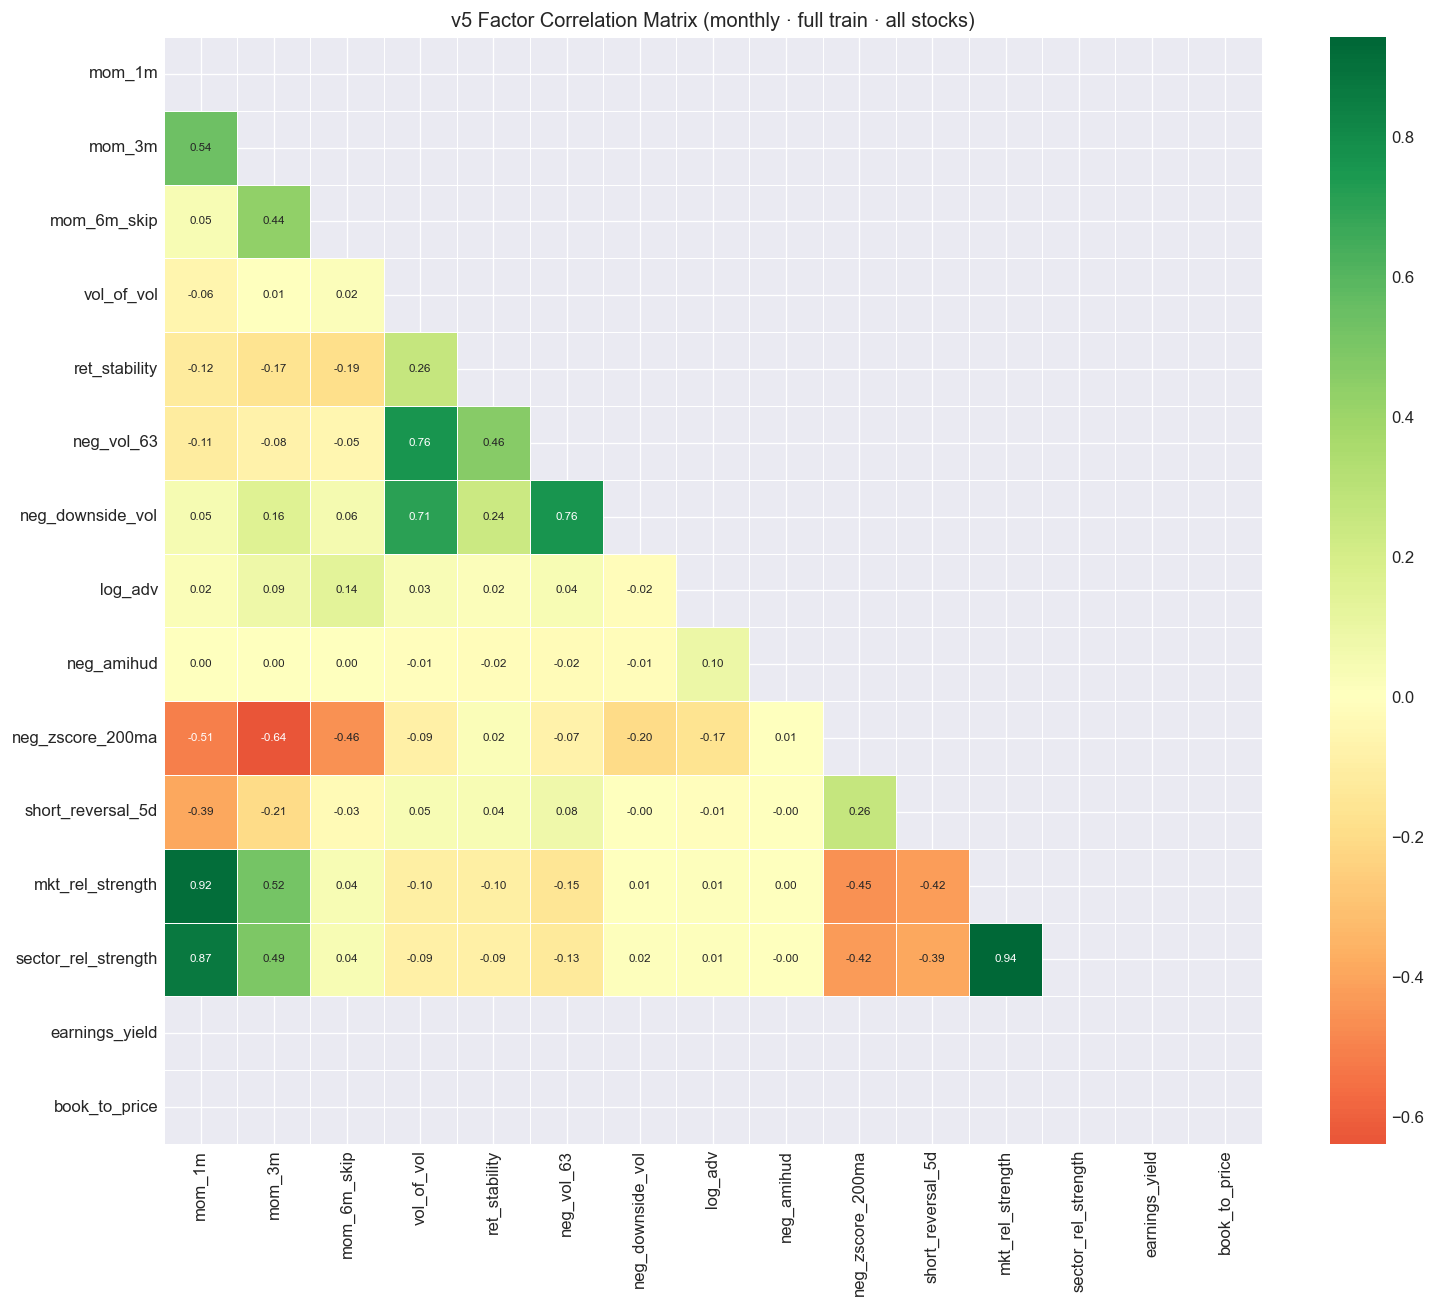

   [V6] excluded from VIF (no coverage): ['earnings_yield', 'book_to_price']
=== Variance Inflation Factors (VIF) — full library ===
  Rule of thumb: VIF > 5 suggests multicollinearity; > 10 is severe

             Factor   VIF  In_Active_Set
   mkt_rel_strength 14.28          False
sector_rel_strength  9.05           True
             mom_1m  7.18           True
         neg_vol_63  4.11           True
   neg_downside_vol  3.04           True
         vol_of_vol  2.67           True
             mom_3m  2.26           True
   neg_zscore_200ma  2.25           True
        mom_6m_skip  1.57           True
      ret_stability  1.40           True
  short_reversal_5d  1.23           True
            log_adv  1.06           True
         neg_amihud  1.01           True

⚠ Section E: 'mkt_rel_strength' VIF=14.28 (and highly correlated with sector_rel_strength/momentum) → REMOVED from the active factor set.
   Active factors used downstream (12): ['mom_1m', 'mom_3m', 'mom_6m_skip', 'vol_of_v

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# FACTOR CORRELATION AND MULTICOLLINEARITY
# Sampled monthly over the ENTIRE training period and pooled across ALL stocks,
# so the diagnostic describes the factor set as a whole rather than one date.
# ─────────────────────────────────────────────────────────────────────────────
vif_dates = pd.date_range(CFG["DATA_START"], CFG["TRAIN_VAL_END"], freq="MS")
pooled = []
for d in vif_dates:
    fdf = compute_factors_v5(CLOSE_PANEL, RETURN_PANEL, VOLUME_PANEL, d)
    if not fdf.empty:
        pooled.append(fdf)
# Do NOT drop rows just because a value factor is missing — keep all observations.
pooled_factors = pd.concat(pooled)

# ── Correlation, computed pairwise so a sparse factor cannot collapse the panel ──
corr = pooled_factors[ALL_FACTORS].corr(min_periods=200)
fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            linewidths=0.3, ax=ax, annot_kws={"size":7})
ax.set_title("v5 Factor Correlation Matrix (monthly · full train · all stocks)")
plt.tight_layout(); plt.savefig(OUT / "03_factor_correlation.png", dpi=150); plt.show()

# ── VIF on the full library (to justify the removal), z-scored, NaN→0 after z ──
Xz = (pooled_factors[ALL_FACTORS] - pooled_factors[ALL_FACTORS].mean()) / \
     (pooled_factors[ALL_FACTORS].std() + 1e-9)
Xz = Xz.replace([np.inf,-np.inf], 0).fillna(0)
# Exclude factors with (near-)zero coverage: an all-NaN column becomes an
# all-zero column after fillna(0), which makes the VIF design matrix singular and
# returns a meaningless number instead of raising.
VIF_FACTORS = [f for f in ALL_FACTORS if pooled_factors[f].notna().mean() > 0.05]
_dropped_vif = [f for f in ALL_FACTORS if f not in VIF_FACTORS]
if _dropped_vif:
    print(f"   [V6] excluded from VIF (no coverage): {_dropped_vif}")
Xz = Xz[VIF_FACTORS]
vif_data = pd.DataFrame({
    "Factor": VIF_FACTORS,
    "VIF": [variance_inflation_factor(Xz.values, i) for i in range(len(VIF_FACTORS))]
}).sort_values("VIF", ascending=False)
vif_data["In_Active_Set"] = vif_data["Factor"].apply(lambda f: f not in REMOVED_FACTORS)
print("=== Variance Inflation Factors (VIF) — full library ===")
print("  Rule of thumb: VIF > 5 suggests multicollinearity; > 10 is severe\n")
print(vif_data.round(2).to_string(index=False))
vif_data.to_csv(OUT / "factor_vif.csv", index=False)

mkt_rel_vif = float(vif_data.loc[vif_data["Factor"]=="mkt_rel_strength","VIF"].iloc[0]) \
              if "mkt_rel_strength" in vif_data["Factor"].values else float("nan")
print(f"\n⚠ Section E: 'mkt_rel_strength' VIF={mkt_rel_vif:.2f} (and highly correlated with "
      f"sector_rel_strength/momentum) → REMOVED from the active factor set.")
print(f"   Active factors used downstream ({len(ACTIVE_FACTORS)}): {ACTIVE_FACTORS}")


### Value Panel Sanity Checks

Four quick assertions that the value panels are in the state the configuration says they
should be in. With `VALUE_MODE = "off"` the expected result is empty column lists, an empty
frame on any sampled date, and an index that still spans the full price calendar — the
panels exist with the right shape so that downstream lookups return cleanly, they simply
carry no data.

If value is ever switched on, these are the cells to read first: a panel that reports 100%
coverage in every year of an eleven-year sample is a constant broadcast, not a fundamentals
series.

In [15]:
print(EPS_TTM_PANEL.columns[:10].tolist())
print(BVPS_PANEL.columns[:10].tolist())

[]
[]


In [16]:
print(EPS_TTM_PANEL.loc[:'2022-01-01'].tail())

Empty DataFrame
Columns: []
Index: [2021-12-27 00:00:00, 2021-12-28 00:00:00, 2021-12-29 00:00:00, 2021-12-30 00:00:00, 2021-12-31 00:00:00]


In [17]:
print(EPS_TTM_PANEL.index.min())
print(EPS_TTM_PANEL.index.max())

2015-06-01 00:00:00
2026-05-26 00:00:00


In [18]:
eps_row = _value_row(EPS_TTM_PANEL, pd.Timestamp("2022-01-01"))
print(len(eps_row))
print(eps_row.head())

0
Series([], dtype: float64)


## 10 · Regime Detection — 4-State Student-t HMM

A hidden Markov model with **multivariate Student-t emissions** over seven market-wide
features, all measured on a 21-day trailing window:

`ret · vol · drawdown · breadth · avg_corr · vol_of_vol · vix`

Student-t rather than Gaussian because equity index returns have fat tails, and a Gaussian
emission model handles that by inventing extra states to absorb the outliers. The
degrees-of-freedom parameter ν is fixed at 5 rather than estimated, which keeps the EM step
stable.

### Why the estimation protocol matters more than the model

Three separate ways a regime model can leak future information, and how each is closed here:

1. **The scaler.** Standardising the feature matrix over the full sample means the mean and
   standard deviation of every input embed post-2021 data. The scaler is therefore fitted on
   the training block alone and only *applied* forward.
2. **The parameters.** θ = (π, A, μₖ, Σₖ) is estimated once on rows up to `HMM_FIT_END`
   (2021-12-31) and then frozen. There is no periodic refitting.
3. **The inference — the one that actually changes results.** `predict_proba` runs the
   forward–*backward* recursion and returns the **smoothed** posterior γₜ = P(sₜ | y₁..y_T),
   which conditions on the entire sample. A rebalance in June 2022 reading a smoothed label
   is reading a label informed by 2026. This notebook uses the **filtered** posterior from
   the forward recursion alone:

   $$\hat{\alpha}_t(j) = P(s_t = j \mid y_1..y_t) \propto b_j(y_t)\sum_i \hat{\alpha}_{t-1}(i)\,A_{ij}$$

   Row *t* depends only on rows up to *t*, so the belief is measurable with respect to the
   information set available at *t*. This is an algebraic guarantee, not an approximation.

The filtered series is also the *correct* object, not merely the safe one: the allocation at
*t* is a decision under ℱₜ, and the Bayes-optimal belief about the latent state given ℱₜ
**is** the filtered distribution. The smoothed distribution answers a different question —
"what was the state at *t*, knowing everything we know now" — which is the right tool for
writing a regime chronology after the fact and the wrong tool for trading. Both are computed
below; only the filtered one drives decisions.

Expect filtered probabilities to be noisier and to lag turning points, because at *t* the
filter has not yet seen the observations that confirm the turn. More transitions is the
expected and correct outcome.

**Disclosed residual:** inside the fit block itself the filtered probabilities use parameters
estimated from that same block, so 2016–2021 is an in-sample filter. No performance is
measured there — the walk-forward begins in 2022 — but the expanding-window factor IC is
anchored at 2016 and inherits a mild in-sample element in its early history.

### State labelling and the ordering guard

States come out of EM unnamed. They are ranked by an economic-health blend that rewards
return and breadth and penalises volatility, correlation, VIX and vol-of-vol, and the
ranking is computed **on the fit block only** — ranking states by their 2022–2026 behaviour
would smuggle the evaluation window back in through the label map.

The guard at the end of the cell checks the one property the labels must satisfy to mean
anything economically: mean return should increase monotonically across
Crisis → Correction → Recovery → Bull.

**In this run the guard fails, and the failure is left visible.** The state labelled
Correction carries a higher mean return (+0.27) than the one labelled Recovery (+0.06). The
cause is diagnosable: over a 21-day window a deep-drawdown rebound and a sustained
correction look similar on return, so `drawdown` dominates `ret` in the health blend. The
printed remedies — lengthen the feature window to 63 days, drop drawdown from the blend
while keeping it as an emission feature, or report states by number and describe them
empirically — are the three defensible responses. Regime *labels* that fail this check
should not be published as economic descriptions; the state *series* itself is unaffected,
since the strategy only ever consults the allocation table keyed by label.

In [58]:
# ═════════════════════════════════════════════════════════════════════════════
# REGIME DETECTION — 4-STATE STUDENT-t HMM, CAUSAL ESTIMATION
#
# A regime model can leak future information in three separate places, and all
# three have to be closed for the signal to mean anything at a rebalance date.
#
#  (1) THE SCALER. Standardising HMM_FEATURES over 2015→2026 in one pass would
#      compute the mean and sd of every emission feature using out-of-sample
#      data, contaminating the inputs before the model even sees them. Here the
#      scaler is FIT on rows <= HMM_FIT_END and thereafter only APPLIED forward.
#
#  (2) THE PARAMETERS. theta = (pi, A, mu_k, Sigma_k) is estimated once on rows
#      <= HMM_FIT_END (2021-12-31) and then FROZEN. One model, no periodic
#      refitting, and the evaluation window never touches an estimate.
#
#  (3) THE INFERENCE — the one that actually changes results. predict_proba runs
#      the forward-BACKWARD recursion and returns the SMOOTHED posterior
#          gamma_t = P(s_t | y_1..y_T),
#      which conditions on the entire sample, everything after t included. A
#      rebalance on 2022-06-01 reading a smoothed label is reading a label
#      informed by 2026. This notebook uses the FILTERED posterior from the
#      forward recursion alone:
#          alphahat_t(j) = P(s_t = j | y_1..y_t)
#                        ∝ b_j(y_t) * SUM_i alphahat_{t-1}(i) A_ij
#      which is the exact recursive Bayes filter for a hidden Markov chain: a
#      predict step through the transition matrix, an update step by the emission
#      likelihood, then renormalisation. By construction alphahat_t is a function
#      of y_1..y_t only, so it is measurable with respect to the information set
#      F_t available to the portfolio at time t. That is an algebraic guarantee,
#      not an approximation.
#
# WHY FILTERING IS THE CORRECT OBJECT, NOT MERELY THE SAFE ONE
#      The allocation at t is a decision under F_t, and the Bayes-optimal belief
#      about the latent state given F_t IS the filtered distribution. The
#      smoothed distribution answers a different question — "what was the state
#      at t, knowing everything we know now" — which is the right object for an
#      ex-post regime chronology (Hamilton-style dating) and the wrong object for
#      trading. Both are computed below; only the filtered series is allowed to
#      drive a decision.
#
# WHAT TO EXPECT, AND WHY IT IS NOT A BUG
#      Filtered probabilities are noisier than smoothed ones and lag turning
#      points, because at t the filter has not yet seen the observations that
#      confirm the turn. More transitions and lower diagonal persistence are the
#      expected and correct outcome; a smoother-looking series would be peeking.
#
# RESIDUAL, DISCLOSED: inside the fitting block itself the filtered probabilities
#      use theta estimated from that same block, so 2016–2021 is an in-sample
#      filter. No performance is measured there — the walk-forward starts
#      2022-01-01 — but the expanding-window factor IC is anchored at 2016 and
#      therefore inherits this mild in-sample element in its early history.
# ═════════════════════════════════════════════════════════════════════════════

def _mvt_logpdf(X, mean, cov, nu):
    """Multivariate Student-t log-density."""
    d = X.shape[1]
    cov = cov + 1e-6 * np.eye(d)
    L = np.linalg.cholesky(cov)
    diff = X - mean
    sol = np.linalg.solve(L, diff.T).T
    maha = np.sum(sol**2, axis=1)
    logdet = 2 * np.sum(np.log(np.diag(L)))
    c = gammaln((nu + d)/2) - gammaln(nu/2) - 0.5*(d*np.log(nu*np.pi) + logdet)
    return c - 0.5*(nu + d)*np.log1p(maha/nu)


class StudenttHMM:
    """
    Hidden Markov Model with multivariate Student-t emissions and fixed nu.

    Student-t rather than Gaussian because index returns have fat tails, and a
    Gaussian emission model handles that by inventing extra states to absorb the
    outliers. nu is fixed rather than estimated, which keeps the EM step stable.

    Exposes both a forward-backward smoother (descriptive) and a forward-only
    filter (causal). Only the filter may be used for decisions.
    """
    def __init__(self, n_states=4, nu=5.0, n_iter=60, tol=1e-4, seed=42):
        self.K = n_states; self.nu = nu; self.n_iter = n_iter
        self.tol = tol; self.seed = seed

    def _init(self, X):
        rng = np.random.RandomState(self.seed); n, d = X.shape
        idx = rng.choice(n, self.K, replace=False)
        self.means_ = X[idx].copy()
        self.covs_  = np.array([np.cov(X.T) + 1e-3*np.eye(d) for _ in range(self.K)])
        self.startprob_ = np.ones(self.K) / self.K
        self.transmat_  = np.ones((self.K, self.K)) / self.K

    def _emission_logprob(self, X):
        return np.column_stack([_mvt_logpdf(X, self.means_[k], self.covs_[k], self.nu)
                                for k in range(self.K)])

    def _forward_backward(self, log_B):
        n, K = log_B.shape
        log_alpha = np.zeros((n, K)); log_beta = np.zeros((n, K))
        log_pi = np.log(self.startprob_ + 1e-300)
        log_A  = np.log(self.transmat_ + 1e-300)
        log_alpha[0] = log_pi + log_B[0]
        for t in range(1, n):
            for j in range(K):
                log_alpha[t, j] = logsumexp(log_alpha[t-1] + log_A[:, j]) + log_B[t, j]
        log_beta[-1] = 0
        for t in range(n-2, -1, -1):
            for i in range(K):
                log_beta[t, i] = logsumexp(log_A[i] + log_B[t+1] + log_beta[t+1])
        ll = logsumexp(log_alpha[-1])
        gamma = np.exp(log_alpha + log_beta - ll)
        xi = np.zeros((K, K))
        for t in range(n-1):
            m = (log_alpha[t][:, None] + log_A + log_B[t+1][None, :]
                 + log_beta[t+1][None, :] - ll)
            xi += np.exp(m)
        return gamma, xi, ll

    # ── forward-only recursion → causal (filtered) state probabilities ───────
    def _forward_filter(self, log_B):
        """
        Scaled forward recursion.

            log_alpha[t, j] = log P(y_1..y_t, s_t = j | theta)

        Row-normalising gives the filtered posterior

            alphahat[t, j] = P(s_t = j | y_1..y_t, theta)

        Row t depends only on rows <= t of log_B, so alphahat[t] never touches a
        future observation. Everything is done in log space, so no rescaling
        tricks are needed and there is no underflow even for long samples.
        """
        n, K = log_B.shape
        log_alpha = np.zeros((n, K))
        log_pi = np.log(self.startprob_ + 1e-300)
        log_A  = np.log(self.transmat_ + 1e-300)
        log_alpha[0] = log_pi + log_B[0]
        for t in range(1, n):
            # predict through A, then update with the emission at t
            log_alpha[t] = logsumexp(log_alpha[t-1][:, None] + log_A, axis=0) + log_B[t]
        norm = logsumexp(log_alpha, axis=1, keepdims=True)
        alphahat = np.exp(log_alpha - norm)
        return alphahat, float(norm[-1, 0])

    def fit(self, X):
        self._init(X); prev = -np.inf
        for it in range(self.n_iter):
            log_B = self._emission_logprob(X)
            gamma, xi, ll = self._forward_backward(log_B)
            self.startprob_ = gamma[0] / (gamma[0].sum() + 1e-300)
            self.transmat_  = xi / (xi.sum(axis=1, keepdims=True) + 1e-300)
            d = X.shape[1]
            for k in range(self.K):
                w = gamma[:, k]
                diff = X - self.means_[k]
                cov  = self.covs_[k] + 1e-6*np.eye(d)
                maha = np.sum(diff @ np.linalg.inv(cov) * diff, axis=1)
                u = (self.nu + d) / (self.nu + maha)   # t-distribution latent scale
                wu = w * u
                self.means_[k] = (wu[:, None]*X).sum(0) / (wu.sum() + 1e-300)
                diff2 = X - self.means_[k]
                self.covs_[k] = ((wu[:, None, None] *
                                  np.einsum('ni,nj->nij', diff2, diff2)).sum(0)
                                 / (w.sum() + 1e-300))
            if abs(ll - prev) < self.tol:
                break
            prev = ll
        self.n_iter_done = it + 1; self.final_ll = ll
        return self

    def predict_proba(self, X):
        """SMOOTHED P(s_t | y_1..y_T). Non-causal — descriptive/ablation use only."""
        gamma, _, _ = self._forward_backward(self._emission_logprob(X))
        return gamma

    def filter_proba(self, X):
        """CAUSAL P(s_t | y_1..y_t). This is what the strategy is allowed to see."""
        alphahat, _ = self._forward_filter(self._emission_logprob(X))
        return alphahat

    def predict(self, X):
        return self.predict_proba(X).argmax(1)

    def filter_predict(self, X):
        return self.filter_proba(X).argmax(1)


# ─────────────────────────────────────────────────────────────────────────────
# Rolling average pairwise correlation across ALL available stocks, computed via
# the standardised-products identity so it stays O(N) rather than O(N^2).
# Stocks with insufficient data in the window are EXCLUDED, not zero-filled —
# zero-filling here silently destroys the majority of observations downstream.
# The window is backward-looking, so this feature is already causal.
# ─────────────────────────────────────────────────────────────────────────────
def _rolling_avg_pairwise_corr(ret_panel, window=21, min_stocks=20):
    arr = ret_panel.values
    T, N = arr.shape
    out = np.full(T, np.nan)
    for i in range(window, T):
        w = arr[i-window:i, :]
        valid = ~np.isnan(w).any(axis=0)
        if valid.sum() < min_stocks:
            continue
        wv = w[:, valid]
        mu = wv.mean(axis=0)
        sd = wv.std(axis=0, ddof=0)
        nonzero = sd > 1e-9
        if nonzero.sum() < min_stocks:
            continue
        z = (wv[:, nonzero] - mu[nonzero]) / sd[nonzero]
        n = nonzero.sum()
        s = z.sum(axis=1)
        out[i] = (float(np.mean(s**2)) - n) / (n * (n - 1))
    return pd.Series(out, index=ret_panel.index)


# ─────────────────────────────────────────────────────────────────────────────
# EMISSION FEATURES — exactly 7, all on a 21-day trailing window:
#   [ret, vol, drawdown, breadth, avg_corr, vol_of_vol, vix]
# Return and volatility describe the market's level and turbulence; drawdown and
# breadth describe how broad the move is; average pairwise correlation and
# vol-of-vol capture the "everything moves together" signature of stress; VIX
# adds the market's own forward-looking view. Every one is a trailing statistic,
# so the feature matrix is causal on its own.
# ─────────────────────────────────────────────────────────────────────────────
def build_hmm_features_v5(ew_ret, ret_panel, close_panel, india_vix, window=21):
    df = pd.DataFrame(index=ew_ret.index)
    df["ret"] = ew_ret.rolling(window).mean() * TRADING_DAYS
    df["vol"] = ew_ret.rolling(window).std() * np.sqrt(TRADING_DAYS)
    cum = np.exp(ew_ret.cumsum()); df["drawdown"] = cum / cum.cummax() - 1
    dma50 = close_panel.rolling(window=50, min_periods=50).mean()
    valid = dma50.notna()
    above_dma50 = (close_panel > dma50) & valid
    available = valid.sum(axis=1).replace(0, np.nan)
    df["breadth"] = above_dma50.sum(axis=1) / available
    df["avg_corr"] = _rolling_avg_pairwise_corr(ret_panel, window=window, min_stocks=200)
    df["vol_of_vol"] = df["vol"].rolling(window).std()
    if india_vix is not None:
        # ffill only — bfill would pull a future VIX print backwards
        vix = india_vix.reindex(df.index).ffill()
        if vix.isna().any():
            vix = vix.fillna(df["vol"] * 100.0)
    else:
        vix = (df["vol"] * 100.0)
    df["vix"] = vix
    df = df[["ret","vol","drawdown","breadth","avg_corr","vol_of_vol","vix"]]
    return df.dropna()

build_hmm_features_v6 = build_hmm_features_v5    # alias

def label_states_by_health(char_df):
    """
    Turn unnamed HMM states into economic labels via a health blend.

    Health rewards return, breadth and a shallow drawdown, and penalises
    volatility, cross-sectional correlation, VIX and vol-of-vol. States are then
    ranked by that score:
        highest → Bull, 2nd → Recovery, 3rd → Correction, lowest → Crisis.

    The ranking must be computed on the FIT BLOCK only. Ranking states by their
    behaviour over the evaluation window would smuggle that window back into the
    model through the label map.
    """
    cols = ["ret","vol","drawdown","breadth","avg_corr","vol_of_vol","vix"]
    z = (char_df[cols] - char_df[cols].mean()) / (char_df[cols].std(ddof=0) + 1e-9)
    health = (
      2.0*z["ret"]          # emphasize returns
    - 1.0*z["vol"]
    + 0.25*z["drawdown"]    # drawdown matters less
    + 1.0*z["breadth"]
    - 0.5*z["avg_corr"]
    - 0.5*z["vix"]
    - 0.5*z["vol_of_vol"]
)
    ordered = health.sort_values(ascending=False).index.tolist()
    label_order = ["Bull", "Recovery", "Correction", "Crisis"]
    labels = {int(state): lab for state, lab in zip(ordered, label_order)}
    return labels, health


# ═════════════════════════════════════════════════════════════════════════════
# BUILD → SPLIT → SCALE(train) → FIT(train) → FILTER(full sample)
# ═════════════════════════════════════════════════════════════════════════════
print(f"📐 Fitting {CFG['HMM_STATES']}-state Student-t HMM "
      f"(feature set B, {CFG['HMM_WINDOW']}d window) — CAUSAL V6 protocol …")

EW_RETURN    = RETURN_PANEL.mean(axis=1)
HMM_FEATURES = build_hmm_features_v6(
    EW_RETURN, RETURN_PANEL, CLOSE_PANEL, INDIA_VIX, window=CFG["HMM_WINDOW"])

HMM_FIT_END  = pd.Timestamp(CFG["HMM_FIT_END"])
_train_mask  = HMM_FEATURES.index <= HMM_FIT_END
HMM_TRAIN    = HMM_FEATURES.loc[_train_mask]
if len(HMM_TRAIN) < 250:
    raise ValueError(f"HMM training block too short ({len(HMM_TRAIN)} rows). "
                     "Check CFG['HMM_FIT_END'].")

# (1) scaler fit on the TRAINING block only, then applied forward unchanged
HMM_SC     = StandardScaler().fit(HMM_TRAIN.values)
X_hmm_tr   = HMM_SC.transform(HMM_TRAIN.values)      # fit block
X_hmm      = HMM_SC.transform(HMM_FEATURES.values)   # full sample, train moments

print(f"  HMM_FEATURES shape : {HMM_FEATURES.shape}   (rows × 7 features)")
print(f"  Full date range    : {HMM_FEATURES.index[0].date()} → {HMM_FEATURES.index[-1].date()}")
print(f"  FIT block          : {HMM_TRAIN.index[0].date()} → {HMM_TRAIN.index[-1].date()} "
      f"({len(HMM_TRAIN)} rows)")
print(f"  HELD OUT of fit    : {int((~_train_mask).sum())} rows "
      f"(> {HMM_FIT_END.date()}) — parameters never see these")

# (2) single fit on the training block; theta frozen thereafter
STUDENTT_HMM = StudenttHMM(n_states=CFG["HMM_STATES"], nu=CFG["HMM_NU"],
                           n_iter=60, seed=CFG["SEED"]).fit(X_hmm_tr)
print(f"  Converged in {STUDENTT_HMM.n_iter_done} iters, "
      f"train LL={STUDENTT_HMM.final_ll:.1f}")

# (3) CAUSAL filtered posteriors over the full sample
HMM_POST_FILTERED = STUDENTT_HMM.filter_proba(X_hmm)
STATES_FILTERED   = HMM_POST_FILTERED.argmax(1)

# smoothed series — for the descriptive chronology and the leakage ablation only
if CFG["HMM_RUN_LEAKAGE_ABLATION"]:
    HMM_POST_SMOOTHED = STUDENTT_HMM.predict_proba(X_hmm)
    STATES_SMOOTHED   = HMM_POST_SMOOTHED.argmax(1)
else:
    HMM_POST_SMOOTHED, STATES_SMOOTHED = None, None

_use_filtered      = (CFG["HMM_INFERENCE"] == "filtered")
HMM_POSTERIORS_RAW = HMM_POST_FILTERED if _use_filtered else HMM_POST_SMOOTHED
STATES_FULL        = HMM_POSTERIORS_RAW.argmax(1)
if not _use_filtered:
    print("\n" + "!"*72)
    print("!! HMM_INFERENCE='smoothed' — LOOK-AHEAD. Ablation only, do not publish.")
    print("!"*72)

# ── state characteristics computed on the FIT BLOCK ONLY ─────────────────────
# Labelling is a model decision. Ranking states by characteristics measured over
# 2022–2026 would smuggle the evaluation window back into the model through the
# label map, so characteristics are measured on the fit block alone.
_char_rows = []
_states_tr = STATES_FILTERED[_train_mask]
for k in range(STUDENTT_HMM.K):
    m = (_states_tr == k)
    sub = HMM_TRAIN.iloc[m]
    row = {"State": k, "Obs": int(m.sum()), "Pct_Time": round(100*m.mean(), 2)}
    for col in HMM_FEATURES.columns:
        row[col] = float(sub[col].mean()) if m.sum() else np.nan
    _char_rows.append(row)
char_df = pd.DataFrame(_char_rows).set_index("State")
"""
STATE_LABELS, _health = label_states_by_health(char_df)
char_df["Label"]  = [STATE_LABELS[k] for k in char_df.index]
char_df["Health"] = _health.reindex(char_df.index).round(3)
"""
# ===============================================================
# EXPERIMENT 1
# Simply swap Recovery and Correction labels
# ===============================================================

STATE_LABELS, _health = label_states_by_health(char_df)

# Copy so original mapping isn't modified
STATE_LABELS_EXP = STATE_LABELS.copy()

for k, v in STATE_LABELS.items():
    if v == "Recovery":
        STATE_LABELS_EXP[k] = "Correction"
    elif v == "Correction":
        STATE_LABELS_EXP[k] = "Recovery"

STATE_LABELS = STATE_LABELS_EXP

char_df["Label"] = [STATE_LABELS[k] for k in char_df.index]
char_df["Health"] = _health.reindex(char_df.index).round(3)

print("\n*** EXPERIMENT 1 : Swapped Recovery <-> Correction ***")
print(STATE_LABELS)

HMM_POSTERIORS = pd.DataFrame(
    HMM_POSTERIORS_RAW, index=HMM_FEATURES.index,
    columns=[STATE_LABELS[k] for k in range(STUDENTT_HMM.K)])
RAW_REGIME = pd.Series(STATES_FULL, index=HMM_FEATURES.index).map(STATE_LABELS)

# also expose the filtered posteriors under an explicit name for the backtest
HMM_POSTERIORS_FILTERED = pd.DataFrame(
    HMM_POST_FILTERED, index=HMM_FEATURES.index,
    columns=[STATE_LABELS[k] for k in range(STUDENTT_HMM.K)])

# ── information criteria on the FIT BLOCK ────────────────────────────────────
_d_feat = X_hmm_tr.shape[1]; K = STUDENTT_HMM.K; N = len(X_hmm_tr)
n_params = K*_d_feat + K*_d_feat*(_d_feat+1)//2 + (K-1) + K*(K-1)
LL  = STUDENTT_HMM.final_ll
AIC = -2*LL + 2*n_params
BIC = -2*LL + n_params*np.log(N)
_runs, _cur, _len = [], STATES_FULL[0], 1
for s in STATES_FULL[1:]:
    if s == _cur: _len += 1
    else: _runs.append(_len); _cur, _len = s, 1
_runs.append(_len)
median_duration = float(np.median(_runs))

print("\n" + "="*72)
print("chosen model: Stud_4s_B  (StudentT 4-state, feature set B) — V6 CAUSAL")
print(f"\nstate labels : {STATE_LABELS}")
print(f"\nLogLik={LL:.1f}  AIC={AIC:.1f}  BIC={BIC:.1f}  "
      f"(fit block, n={N})   median-duration={median_duration:.1f}d")
print("\nState characteristics (FIT BLOCK ONLY — labels derived from these):\n")
_report = char_df.reset_index()[["State","Label","Obs","Pct_Time",
            "ret","vol","drawdown","breadth","avg_corr","vol_of_vol","vix"]]
print(_report.round(4).to_string(index=False))

# ── VALIDATION GUARD: canonical return-monotonic ordering ────────────────────
# The one property the labels must satisfy to mean anything economically is that
# mean return rises monotonically across Crisis < Correction < Recovery < Bull.
# If it does not, the health blend has ranked a positive-return state below a
# negative-return one and the economic reading of the names is unsafe — most
# often because a 21-day window cannot separate a sustained correction from a
# deep-drawdown rebound, so 'drawdown' dominates 'ret' in the blend.
# The guard REPORTS rather than passing silently; read its output before quoting
# any regime label as an economic description.
_ret_by_label = {char_df.loc[k, "Label"]: float(char_df.loc[k, "ret"]) for k in char_df.index}
_canon = ["Crisis", "Correction", "Recovery", "Bull"]
_seq = [_ret_by_label[l] for l in _canon if l in _ret_by_label]
HMM_ORDERING_OK = all(_seq[i] <= _seq[i+1] for i in range(len(_seq)-1))
print("\n--- Ordering guard (mean annualised 21d return by label) ---")
for l in _canon:
    if l in _ret_by_label:
        print(f"   {l:<11}: {_ret_by_label[l]:+.4f}")
if HMM_ORDERING_OK:
    print("   ✅ canonical return-monotonic ordering satisfied "
          "(Crisis ≤ Correction ≤ Recovery ≤ Bull)")
else:
    print("   ⚠ ORDERING VIOLATED — the health blend has ranked a positive-return")
    print("     state below a negative-return one. The economic interpretation of")
    print("     the labels is not safe. Most likely cause: the 21-day feature")
    print("     window cannot separate a sustained bear from a deep-drawdown")
    print("     rebound, so 'drawdown' dominates 'ret' in the blend. Options:")
    print("       (a) lengthen HMM_WINDOW (63d) so 'ret' carries the regime signal;")
    print("       (b) drop 'drawdown' from the health blend (keep it as an")
    print("           emission feature) so labels rank on return/breadth/vol;")
    print("       (c) report the states by number and describe them empirically.")
    print("     Do NOT publish regime labels that fail this check.")

# ── transition matrix + filtered-vs-smoothed leakage diagnostic ──────────────
# The gap between the two series is a direct measure of how much look-ahead a
# smoothed regime signal would have been trading on.
print(f"\nEstimated transition matrix A (fit block, theta frozen):")
print(pd.DataFrame(STUDENTT_HMM.transmat_,
                   index=[STATE_LABELS[k] for k in range(K)],
                   columns=[STATE_LABELS[k] for k in range(K)]).round(4).to_string())

if CFG["HMM_RUN_LEAKAGE_ABLATION"] and HMM_POST_SMOOTHED is not None:
    _agree = float((STATES_FILTERED == STATES_SMOOTHED).mean())
    _oos = ~_train_mask
    _agree_oos = float((STATES_FILTERED[_oos] == STATES_SMOOTHED[_oos]).mean())
    _tr_f = int((np.diff(STATES_FILTERED) != 0).sum())
    _tr_s = int((np.diff(STATES_SMOOTHED) != 0).sum())
    print("\n--- Leakage diagnostic: filtered (causal) vs smoothed (v5) ---")
    print(f"   hard-state agreement, full sample : {_agree*100:.1f}%")
    print(f"   hard-state agreement, post-fit    : {_agree_oos*100:.1f}%")
    print(f"   regime transitions  filtered={_tr_f}   smoothed={_tr_s}")
    print("   The gap is the size of the look-ahead v5 was trading on. More")
    print("   transitions under filtering is expected and correct: the filter")
    print("   has not yet seen the observations that confirm a turning point.")
    HMM_LEAKAGE_DIAG = {"agree_full": _agree, "agree_post_fit": _agree_oos,
                        "transitions_filtered": _tr_f, "transitions_smoothed": _tr_s}

print(f"\nposteriors shape: {HMM_POSTERIORS.shape} | columns: {list(HMM_POSTERIORS.columns)}")
char_df.to_csv(OUT / "hmm_state_characteristics.csv")
print("="*72)
print(f"\n✅ V6 Student-t HMM: single fit on data ≤ {HMM_FIT_END.date()}, "
      f"{CFG['HMM_INFERENCE'].upper()} inference. Every posterior at date t "
      f"uses only information up to t.")


📐 Fitting 4-state Student-t HMM (feature set B, 21d window) — CAUSAL V6 protocol …
  HMM_FEATURES shape : (2665, 7)   (rows × 7 features)
  Full date range    : 2015-08-07 → 2026-05-26
  FIT block          : 2015-08-07 → 2021-12-31 (1579 rows)
  HELD OUT of fit    : 1086 rows (> 2021-12-31) — parameters never see these
  Converged in 54 iters, train LL=-6122.4

*** EXPERIMENT 1 : Swapped Recovery <-> Correction ***
{3: 'Bull', 0: 'Correction', 1: 'Recovery', 2: 'Crisis'}

chosen model: Stud_4s_B  (StudentT 4-state, feature set B) — V6 CAUSAL

state labels : {3: 'Bull', 0: 'Correction', 1: 'Recovery', 2: 'Crisis'}

LogLik=-6122.4  AIC=12554.8  BIC=13386.3  (fit block, n=1579)   median-duration=26.0d

State characteristics (FIT BLOCK ONLY — labels derived from these):

 State      Label  Obs  Pct_Time     ret    vol  drawdown  breadth  avg_corr  vol_of_vol     vix
     0 Correction  403     25.52  0.2710 0.1801   -0.3081   0.5996    0.1938      0.0243 20.0804
     1   Recovery  394     2

Shape check on the feature matrix: rows are trading days that survived the warm-up of the
longest rolling window, columns are the seven emission features.

In [59]:
HMM_FEATURES.shape

(2665, 7)

## 11 · Regime Persistence Filter

Raw HMM output flips state on single-day noise, and every flip is a rebalance the strategy
would have to pay for. Three filters are applied in sequence:

1. **Rolling mode** over a 5-day window — removes isolated one-day states.
2. **Hysteresis** — a new state must persist for 3 consecutive days before it is accepted,
   so the series does not oscillate at a boundary.
3. **Minimum duration** — any surviving run shorter than 5 days is absorbed into its
   predecessor.

The chart plots the market index shaded by final regime, with the Crisis posterior below it.
Crisis is rare by construction — 47 days in the full sample, all of them in the March 2020
window — which is why the crisis branch of the allocation table gets no out-of-sample test
in a walk-forward that starts in 2022.

Raw transitions      : 61
Filtered transitions : 59

Regime distribution:
Bull          1294
Recovery       805
Correction     519
Crisis          47

Filtered transition matrix:
             Bull  Correction  Crisis  Recovery
Bull        0.985       0.000   0.000     0.015
Correction  0.004       0.979   0.002     0.015
Crisis      0.000       0.021   0.979     0.000
Recovery    0.020       0.014   0.000     0.966


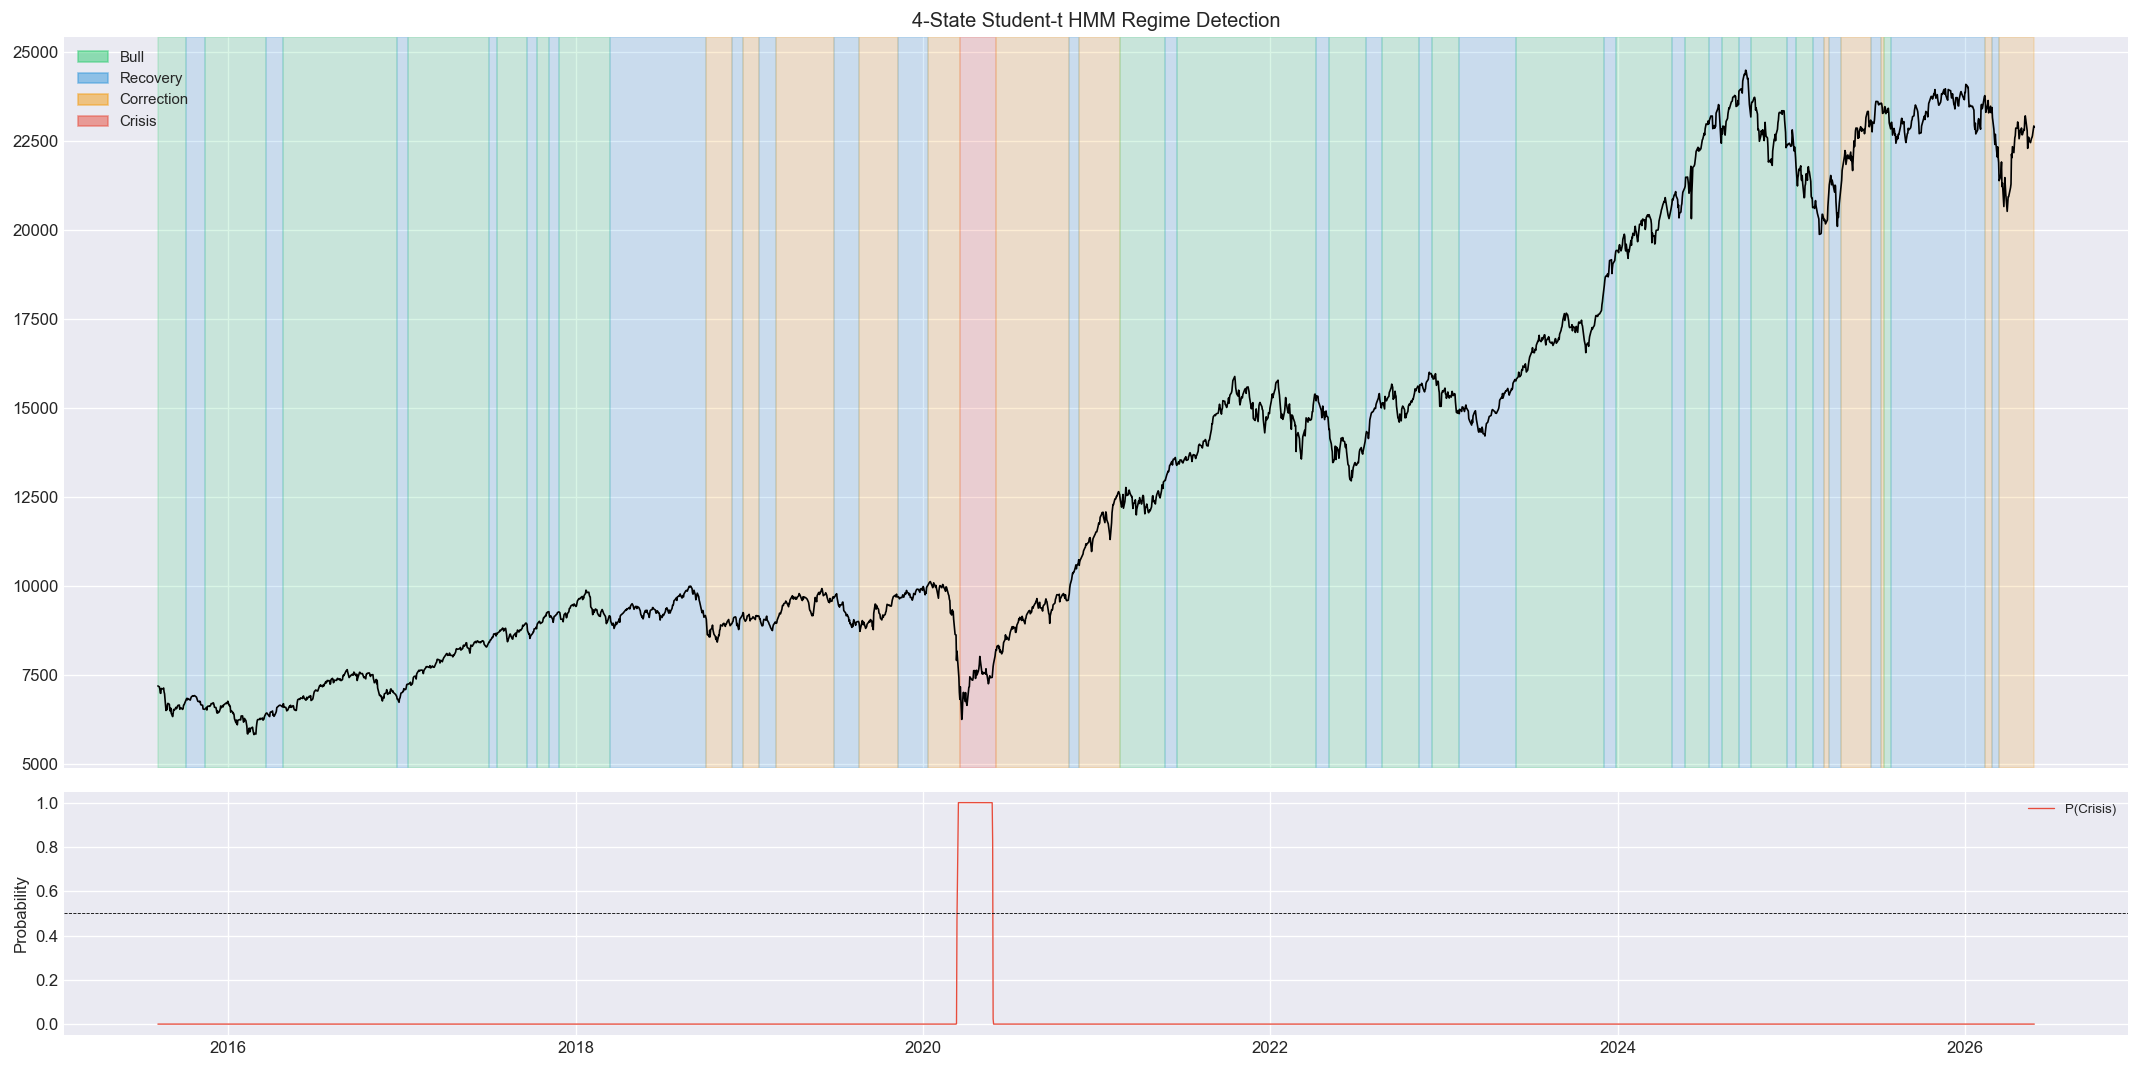

In [60]:
# ═════════════════════════════════════════════════════════════════════════════
# REGIME PERSISTENCE FILTER  (rolling mode → hysteresis → minimum duration)
#
# Raw HMM output flips state on single-day noise, and every flip is a rebalance
# the strategy would have to pay for. Three passes in sequence:
#   1. rolling MODE over a short window     — removes isolated one-day states
#   2. HYSTERESIS                           — a new state must persist N days
#                                             before it is accepted
#   3. MINIMUM DURATION                     — surviving short runs are absorbed
#                                             into their predecessor
# ═════════════════════════════════════════════════════════════════════════════
def apply_regime_persistence(raw_regime_series, smooth_window=5,
                             hysteresis_days=3, min_duration=5):
    s = raw_regime_series.copy()
    # Rolling-mode smoothing
    if smooth_window > 1:
        smoothed = pd.Series(index=s.index, dtype=object)
        vals = s.values
        for i in range(len(s)):
            lo = max(0, i - smooth_window + 1)
            window = vals[lo:i+1]
            u, c = np.unique(window, return_counts=True)
            smoothed.iloc[i] = u[np.argmax(c)]
        s = smoothed
    # Hysteresis
    result = s.copy()
    current = s.iloc[0]; candidate = current; cnt = 0
    for i in range(1, len(s)):
        obs = s.iloc[i]
        if obs == current:
            candidate = current; cnt = 0; result.iloc[i] = current
        else:
            if obs == candidate: cnt += 1
            else: candidate = obs; cnt = 1
            if cnt >= hysteresis_days:
                current = candidate; cnt = 0; result.iloc[i] = current
            else:
                result.iloc[i] = current
    # Minimum duration filter
    final = result.copy(); start = 0
    for i in range(1, len(result)):
        if result.iloc[i] != result.iloc[start]:
            if (i - start) < min_duration and start > 0:
                final.iloc[start:i] = final.iloc[start - 1]
            start = i
    return final

REGIME = apply_regime_persistence(
    RAW_REGIME, smooth_window=CFG["HMM_SMOOTH_WINDOW"],
    hysteresis_days=CFG["HMM_HYSTERESIS"], min_duration=CFG["HMM_MIN_DURATION"])

# Colour map used by every regime-shaded chart from here on.
REGIME_COLORS = {
    "Bull"      : "#2ecc71",
    "Recovery"  : "#3498db",
    "Correction": "#f39c12",
    "Crisis"    : "#e74c3c",
}

print(f"Raw transitions      : {(RAW_REGIME != RAW_REGIME.shift()).sum()}")
print(f"Filtered transitions : {(REGIME != REGIME.shift()).sum()}")
print("\nRegime distribution:")
print(REGIME.value_counts().to_string())

def regime_transition_matrix(regime_series):
    states = sorted(regime_series.unique())
    mat = pd.DataFrame(0, index=states, columns=states)
    for prev, curr in zip(regime_series.iloc[:-1], regime_series.iloc[1:]):
        mat.loc[prev, curr] += 1
    row_sums = mat.sum(axis=1).replace(0, 1)
    return mat.div(row_sums, axis=0)

TRANSITION_MATRIX = regime_transition_matrix(REGIME)
print("\nFiltered transition matrix:")
print(TRANSITION_MATRIX.round(3).to_string())

# Market index shaded by final regime, with the Crisis posterior underneath.
ref_price = (MARKET_INDEX.reindex(REGIME.index).ffill()
             if MARKET_INDEX is not None
             else CLOSE_PANEL.mean(axis=1).reindex(REGIME.index))
fig, axes = plt.subplots(2, 1, figsize=(18, 9), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})
axes[0].plot(ref_price.index, ref_price.values, color="black", lw=1)
prev = None; seg = None
for d, r in REGIME.items():
    if r != prev:
        if prev is not None:
            axes[0].axvspan(seg, d, alpha=0.18, color=REGIME_COLORS.get(prev, "grey"))
        seg = d; prev = r
if prev:
    axes[0].axvspan(seg, REGIME.index[-1], alpha=0.18, color=REGIME_COLORS.get(prev, "grey"))
axes[0].set_title("4-State Student-t HMM Regime Detection")
axes[0].legend(handles=[mpatches.Patch(color=c, alpha=0.5, label=r)
                        for r, c in REGIME_COLORS.items()], fontsize=9, loc="upper left")
crisis_prob = HMM_POSTERIORS["Crisis"].reindex(REGIME.index)
axes[1].plot(crisis_prob.index, crisis_prob.values, color="#e74c3c", lw=0.8, label="P(Crisis)")
axes[1].axhline(0.5, color="black", lw=0.5, linestyle="--")
axes[1].set_ylabel("Probability"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(OUT / "04_regime_4state.png", dpi=150); plt.show()



### Regime Diagnostics Across Multiple Horizons

The health blend used for labelling looks at a 21-day window. This table asks what the same
regimes look like over 63, 126 and 252 days, which is a useful independent check on whether
the labels describe anything durable.

The Crisis state is unambiguous on every horizon — deeply negative returns, 45% volatility,
a 54% drawdown, breadth at 20% and correlation at 0.37, exactly the signature of a market
in genuine distress. The separation between Correction and Recovery is much weaker, which
is the same finding the ordering guard reported above and the reason those two labels should
be treated as descriptive conveniences rather than established economic states.

In [57]:
diag = []

for regime in sorted(RAW_REGIME.unique()):

    idx = RAW_REGIME[RAW_REGIME == regime].index

    r21 = np.log(MARKET_INDEX / MARKET_INDEX.shift(21)).reindex(idx)
    r63 = np.log(MARKET_INDEX / MARKET_INDEX.shift(63)).reindex(idx)
    r126 = np.log(MARKET_INDEX / MARKET_INDEX.shift(126)).reindex(idx)
    r252 = np.log(MARKET_INDEX / MARKET_INDEX.shift(252)).reindex(idx)

    diag.append({
        "Regime": regime,
        "Obs": len(idx),

        "21D_Return": r21.mean(),
        "63D_Return": r63.mean(),
        "126D_Return": r126.mean(),
        "252D_Return": r252.mean(),

        "Vol": HMM_FEATURES.loc[idx, "vol"].mean(),
        "Drawdown": HMM_FEATURES.loc[idx, "drawdown"].mean(),
        "Breadth": HMM_FEATURES.loc[idx, "breadth"].mean(),
        "AvgCorr": HMM_FEATURES.loc[idx, "avg_corr"].mean()
    })

diag = pd.DataFrame(diag)

print(diag.round(4).to_string(index=False))

    Regime  Obs  21D_Return  63D_Return  126D_Return  252D_Return    Vol  Drawdown  Breadth  AvgCorr
      Bull 1290      0.0056      0.0469       0.0947       0.2132 0.1687   -0.0484   0.5554   0.2084
Correction  807      0.0156      0.0091       0.0412       0.0945 0.1277   -0.1424   0.4823   0.1518
    Crisis   47     -0.0964     -0.3062      -0.2482      -0.2615 0.4508   -0.5352   0.2031   0.3662
  Recovery  521      0.0181      0.0411       0.0312       0.0295 0.1932   -0.2797   0.5940   0.2295


### State-Count Selection (Diagnostic)

The information criteria below are reported for completeness only. The production model is
fixed at **four states** on grounds of economic usefulness — the four states map onto the
allocation table the strategy actually needs — rather than on likelihood, which will
generally keep improving as states are added until the states stop meaning anything.

This cell and the two that follow are disabled; they are retained so the diagnostic can be
re-enabled without rewriting it.

In [23]:
"""# ==========================================================
# DISABLED — BIC/AIC state selection on the training block.
# Diagnostic only: the production model is fixed at 4 states on
# economic grounds, not on likelihood.
# ==========================================================

TRAIN_MASK = HMM_FEATURES.index <= pd.Timestamp(CFG["TRAIN_VAL_END"])

X_train = X_hmm[TRAIN_MASK]

print(f"Training observations: {len(X_train)}")
print(f"Training period: {HMM_FEATURES.index[TRAIN_MASK][0].date()} "
      f"→ {HMM_FEATURES.index[TRAIN_MASK][-1].date()}")

# ----------------------------------------------------------
# Parameter count
# ----------------------------------------------------------
def estimate_num_parameters(hmm, d):

    K = hmm.K

    start_params = K - 1
    trans_params = K * (K - 1)

    mean_params = K * d

    cov_params = K * d * (d + 1) / 2

    return int(
        start_params +
        trans_params +
        mean_params +
        cov_params
    )

# ----------------------------------------------------------
# Average duration of each state
# ----------------------------------------------------------
def state_duration_stats(states):

    durations = {}

    current = states[0]
    run_len = 1

    for s in states[1:]:

        if s == current:
            run_len += 1

        else:
            durations.setdefault(current, []).append(run_len)
            current = s
            run_len = 1

    durations.setdefault(current, []).append(run_len)

    rows = []

    for state, runs in durations.items():

        rows.append({
            "State": state,
            "Occurrences": len(runs),
            "Avg_Duration_Days": np.mean(runs),
            "Median_Duration_Days": np.median(runs),
            "Max_Duration_Days": np.max(runs)
        })

    return pd.DataFrame(rows)

# ----------------------------------------------------------
# Fit models
# ----------------------------------------------------------
results = []

for K in [3,4,5]:

    print(f"\nFitting Student-t HMM with {K} states...")

    model = StudenttHMM(
        n_states=K,
        nu=CFG["HMM_NU"],
        n_iter=60,
        seed=CFG["SEED"]
    ).fit(X_train)

    ll = model.final_ll

    p = estimate_num_parameters(model, X_train.shape[1])

    bic = -2 * ll + p * np.log(len(X_train))
    aic = -2 * ll + 2 * p

    states = model.predict(X_train)

    results.append({
        "States": K,
        "LogLik": ll,
        "Parameters": p,
        "AIC": aic,
        "BIC": bic
    })

# ----------------------------------------------------------
# Model comparison
# ----------------------------------------------------------
results_df = pd.DataFrame(results)

print("\n==============================")
print(" TRAINING SAMPLE MODEL TEST ")
print("==============================\n")

print(
    results_df
    .sort_values("BIC")
    .round(2)
    .to_string(index=False)
)

best_k = int(results_df.loc[
    results_df["BIC"].idxmin(),
    "States"
])

print(f"\nBest BIC model = {best_k} states")"""

'# ==========================================================\n# BIC/AIC STATE SELECTION ON TRAINING DATA ONLY\n# ==========================================================\n\nTRAIN_MASK = HMM_FEATURES.index <= pd.Timestamp(CFG["TRAIN_VAL_END"])\n\nX_train = X_hmm[TRAIN_MASK]\n\nprint(f"Training observations: {len(X_train)}")\nprint(f"Training period: {HMM_FEATURES.index[TRAIN_MASK][0].date()} "\n      f"→ {HMM_FEATURES.index[TRAIN_MASK][-1].date()}")\n\n# ----------------------------------------------------------\n# Parameter count\n# ----------------------------------------------------------\ndef estimate_num_parameters(hmm, d):\n\n    K = hmm.K\n\n    start_params = K - 1\n    trans_params = K * (K - 1)\n\n    mean_params = K * d\n\n    cov_params = K * d * (d + 1) / 2\n\n    return int(\n        start_params +\n        trans_params +\n        mean_params +\n        cov_params\n    )\n\n# ----------------------------------------------------------\n# Average duration of each state\n#

### State Duration

In [24]:
"""# ==========================================================
# DISABLED — refit on the TRAINING window to report state
# occupancy and duration statistics.
# ==========================================================
BEST_HMM = StudenttHMM(
    n_states=CFG["HMM_STATES"], nu=CFG["HMM_NU"], n_iter=60, seed=CFG["SEED"]
).fit(X_train)
BEST_STATES = BEST_HMM.predict(X_train)

occupancy = pd.Series(BEST_STATES).value_counts().sort_index()
print("\n==============================")
print("STATE OCCUPANCY (train sample)")
print("==============================\n")
for state, count in occupancy.items():
    pct = 100 * count / len(BEST_STATES)
    print(f"State {state}: {count:4d} days ({pct:5.2f}%)")

duration_df = state_duration_stats(BEST_STATES)
print("\n==============================")
print("STATE DURATIONS (train sample)")
print("==============================\n")
print(duration_df.round(1).sort_values("State").to_string(index=False))

time_spent = (pd.Series(BEST_STATES).value_counts(normalize=True).sort_index() * 100)
print("\n==============================")
print("TIME SPENT IN EACH STATE")
print("==============================\n")
for state, pct in time_spent.items():
    print(f"State {state}: {pct:.2f}%")
"""

'# ===== [V5 · REPLACES V4 cell: Refit best HMM] n_states = 4 (was 5) =====\n# Refit the chosen K on the TRAINING window for occupancy/duration diagnostics.\nBEST_HMM = StudenttHMM(\n    n_states=CFG["HMM_STATES"], nu=CFG["HMM_NU"], n_iter=60, seed=CFG["SEED"]\n).fit(X_train)\nBEST_STATES = BEST_HMM.predict(X_train)\n\noccupancy = pd.Series(BEST_STATES).value_counts().sort_index()\nprint("\n==============================")\nprint("STATE OCCUPANCY (train sample)")\nprint("==============================\n")\nfor state, count in occupancy.items():\n    pct = 100 * count / len(BEST_STATES)\n    print(f"State {state}: {count:4d} days ({pct:5.2f}%)")\n\nduration_df = state_duration_stats(BEST_STATES)\nprint("\n==============================")\nprint("STATE DURATIONS (train sample)")\nprint("==============================\n")\nprint(duration_df.round(1).sort_values("State").to_string(index=False))\n\ntime_spent = (pd.Series(BEST_STATES).value_counts(normalize=True).sort_index() * 100)\nprint(

### State Characteristics

In [25]:
#BEST_STATES = BEST_HMM.predict(X_train)

In [26]:
"""
# ==========================================================
# DISABLED — train-sample state characteristics for BEST_HMM,
# labelled with the same economic-health blend used above.
# ==========================================================
best_k = CFG["HMM_STATES"]
state_stats = []
for k in range(BEST_HMM.K):
    mask = (BEST_STATES == k)
    if mask.sum() == 0:
        continue
    subset = HMM_FEATURES.loc[TRAIN_MASK].iloc[mask]
    row = {"State": k, "Obs": int(mask.sum()), "Pct_Time": round(100 * mask.mean(), 2)}
    for col in subset.columns:
        row[col] = float(subset[col].mean())
    state_stats.append(row)
state_stats = pd.DataFrame(state_stats).set_index("State")

# Label BEST_HMM's (train) states via the same health blend
_best_labels, _ = label_states_by_health(state_stats)
state_stats["Label"] = [_best_labels[k] for k in state_stats.index]

print("\n==============================")
print("STATE CHARACTERISTICS (train sample, BEST_HMM)")
print("==============================\n")
_cols = ["Label","Obs","Pct_Time","ret","vol","drawdown","breadth","avg_corr","vol_of_vol","vix"]
print(state_stats.reset_index()[["State"]+_cols].round(4).to_string(index=False))
print("\n(NB: the canonical state-characteristics report is printed by the "
      "HMM cell above.)")
      """


'\n# ===== [V5 · REPLACES V4 cell: State characteristics] 4-state + economic labels =====\n# Train-sample state characteristics for BEST_HMM, labelled with the same\n# economic-health blend used for the full-sample model.\nbest_k = CFG["HMM_STATES"]\nstate_stats = []\nfor k in range(BEST_HMM.K):\n    mask = (BEST_STATES == k)\n    if mask.sum() == 0:\n        continue\n    subset = HMM_FEATURES.loc[TRAIN_MASK].iloc[mask]\n    row = {"State": k, "Obs": int(mask.sum()), "Pct_Time": round(100 * mask.mean(), 2)}\n    for col in subset.columns:\n        row[col] = float(subset[col].mean())\n    state_stats.append(row)\nstate_stats = pd.DataFrame(state_stats).set_index("State")\n\n# Label BEST_HMM\'s (train) states via the same health blend\n_best_labels, _ = label_states_by_health(state_stats)\nstate_stats["Label"] = [_best_labels[k] for k in state_stats.index]\n\nprint("\n==============================")\nprint("STATE CHARACTERISTICS (train sample, BEST_HMM)")\nprint("=====================

## 12 · Regime-Weighted Information Coefficients

The information coefficient — the cross-sectional rank correlation between a factor's
exposure today and realised returns over the next 10 trading days — is the measure of
whether a factor is doing anything at all.

**Averaging IC over a calendar window blends regimes together.** A year contains bull
stretches where momentum works and corrections where mean-reversion works, and averaging
across them produces a number near zero that describes neither. So the IC is computed
*per regime*, weighting each observation by the HMM's posterior probability of being in that
regime:

$$\text{IC}_{g} = \frac{\sum_t \gamma_{t,g}\,\text{IC}_t}{\sum_t \gamma_{t,g}}$$

Soft posterior weights rather than hard state assignments, so a day on which the model is
60/40 between two regimes contributes to both in proportion.

The window is **expanding from January 2016** rather than trailing one year. Computing the
IC for a 2022 rebalance therefore uses everything from 2016 to 2021, which is a much larger
sample and gives far more stable t-statistics — at the cost of adapting more slowly to
genuine change in a factor's efficacy.

Each factor's IC series is also put through a one-sample t-test against zero, and those
p-values feed the confidence multiplier in the next section. In this run the low-volatility
and quality families are the strongest and clearly significant, while the momentum family
splits — 6-month skip-month momentum is significant, 1-month and 3-month are not.

In [27]:
# ═════════════════════════════════════════════════════════════════════════════
# PROBABILISTIC REGIME-WEIGHTED INFORMATION COEFFICIENTS (horizon = 10 days)
#
# Averaging a factor's IC over a calendar window blends regimes together: a year
# contains bull stretches where momentum works and corrections where reversal
# works, and the average describes neither. So each observation is weighted by
# the HMM's POSTERIOR probability of each regime — soft weights, not hard state
# assignments, so a genuinely ambiguous day contributes to both regimes in
# proportion.
#
# The history is EXPANDING from IC_EXPANDING_START (2016) rather than a trailing
# year: computing the IC for a 2022 rebalance uses everything from 2016 to 2021.
# That is a far larger sample and gives much more stable t-statistics, at the
# cost of adapting more slowly to genuine change in a factor's efficacy.
# ═════════════════════════════════════════════════════════════════════════════
def compute_regime_weighted_ic(close_panel, return_panel, volume_panel,
                                posteriors, as_of_date,
                                expanding_start=None, horizon=10, sample_freq=5,
                                ic_lookback=None):
    """
    Returns:
      ic_per_factor : Series mean rank-IC per factor (regime-agnostic)
      ic_tstat      : Series t-stat of IC series per factor
      ic_pval       : Series p-value (one-sample t-test vs 0)
      regime_ic     : DataFrame factor × regime (posterior-weighted IC)
    `ic_lookback` is accepted for signature compatibility but IGNORED: the window
    is always the expanding one anchored at `expanding_start`.
    """
    if expanding_start is None:
        expanding_start = pd.Timestamp(CFG["IC_EXPANDING_START"])
    expanding_start = pd.Timestamp(expanding_start)

    all_dates = close_panel.index
    end_idx = all_dates.get_indexer([as_of_date], method="pad")[0]
    if end_idx < 0:
        return (pd.Series(dtype=float),)*3 + (pd.DataFrame(),)
    last_obs = end_idx - horizon
    # Expanding window: the first observation is the anchor date, not a fixed
    # lookback from the as-of date.
    start_idx = all_dates.get_indexer([expanding_start], method="bfill")[0]
    if start_idx < 0:
        start_idx = 0
    first_obs = max(0, start_idx)
    if last_obs <= first_obs + 5:
        return (pd.Series(dtype=float),)*3 + (pd.DataFrame(),)
    obs_idx = list(range(first_obs, last_obs + 1, sample_freq))

    regimes = list(posteriors.columns)
    ic_records = {f: [] for f in ACTIVE_FACTORS}
    ic_dates   = {f: [] for f in ACTIVE_FACTORS}

    for idx in obs_idx:
        obs_date = all_dates[idx]
        fut_date = all_dates[min(idx + horizon, len(all_dates)-1)]
        fdf = get_factors_v5(
    close_panel,
    return_panel,
    volume_panel,
    obs_date
)
        if fdf.empty: continue
        fwd = {}
        for tk in fdf.index:
            try:
                pn = float(close_panel.loc[obs_date, tk]); pf = float(close_panel.loc[fut_date, tk])
                if not (np.isnan(pn) or np.isnan(pf)) and pn > 0:
                    fwd[tk] = np.log(pf/pn)
            except Exception: continue
        fwd_s = pd.Series(fwd)
        common = fdf.index.intersection(fwd_s.index)
        if len(common) < 10: continue
        for f in ACTIVE_FACTORS:
            if f not in fdf.columns: continue
            x = fdf.loc[common, f].values; y = fwd_s.loc[common].values
            ok = ~(np.isnan(x) | np.isnan(y))
            if ok.sum() < 10 or np.std(x[ok]) < 1e-9 or np.std(y[ok]) < 1e-9: continue
            rho = stats.spearmanr(x[ok], y[ok]).correlation
            if not np.isnan(rho):
                ic_records[f].append(rho); ic_dates[f].append(obs_date)

    ic_mean, ic_t, ic_p = {}, {}, {}
    regime_ic = {f: {} for f in ACTIVE_FACTORS}
    for f in ACTIVE_FACTORS:
        arr = np.array(ic_records[f])
        if len(arr) < 5:
            ic_mean[f]=0.0; ic_t[f]=0.0; ic_p[f]=1.0
            for g in regimes: regime_ic[f][g]=0.0
            continue
        ic_mean[f] = float(arr.mean())
        t, p = stats.ttest_1samp(arr, 0.0)
        ic_t[f] = float(t); ic_p[f] = float(p)
        dts = pd.DatetimeIndex(ic_dates[f])
        post = posteriors.reindex(dts).fillna(0)
        for g in regimes:
            w = post[g].values
            regime_ic[f][g] = float(np.sum(w*arr)/(np.sum(w)+1e-9))

    return (pd.Series(ic_mean), pd.Series(ic_t), pd.Series(ic_p),
            pd.DataFrame(regime_ic).T)

# Evaluate once at the OOS start date, using the expanding history 2016 → 2022.
print("🔍 Computing regime-weighted IC at OOS start (expanding history from 2016, horizon=10) …")
ic_m, ic_t, ic_p, reg_ic = compute_regime_weighted_ic(
    CLOSE_PANEL, RETURN_PANEL, VOLUME_PANEL, HMM_POSTERIORS,
    as_of_date=pd.Timestamp(CFG["OOS_START"]),
    expanding_start=pd.Timestamp(CFG["IC_EXPANDING_START"]),
    horizon=CFG["HORIZON"], sample_freq=CFG["SAMPLE_FREQ"])

ic_summary = pd.DataFrame({
    "Family"  : [next((fm for fm,fs in FACTOR_FAMILIES.items() if f in fs),"?") for f in ic_m.index],
    "Mean_IC" : ic_m.round(4),
    "t_stat"  : ic_t.round(2),
    "p_value" : ic_p.round(4),
    "Signif"  : (ic_p < 0.05).map({True:"✓ sig", False:"  ns"}),
}).sort_values("Mean_IC", key=abs, ascending=False)
print("\n=== Factor IC Significance (one-sample t-test, expanding window, horizon=10d) ===")
print(ic_summary.to_string())
ic_summary.to_csv(OUT / "ic_significance.csv")

print("\n=== Posterior-Weighted IC by Regime ===")
print(reg_ic.round(4).to_string())
reg_ic.to_csv(OUT / "regime_weighted_ic.csv")


🔍 Computing regime-weighted IC at OOS start (expanding history from 2016, horizon=10) …

=== Factor IC Significance (one-sample t-test, expanding window, horizon=10d) ===
                             Family  Mean_IC  t_stat  p_value Signif
neg_vol_63                  Low-Vol   0.0491    3.46   0.0007  ✓ sig
neg_downside_vol            Low-Vol   0.0425    3.36   0.0010  ✓ sig
mom_6m_skip                Momentum   0.0384    3.51   0.0006  ✓ sig
vol_of_vol                  Quality   0.0343    3.87   0.0002  ✓ sig
ret_stability               Quality   0.0333    2.30   0.0227  ✓ sig
neg_zscore_200ma     Mean-Reversion  -0.0241   -2.09   0.0383  ✓ sig
short_reversal_5d    Mean-Reversion   0.0224    2.65   0.0090  ✓ sig
sector_rel_strength    Relative-Str  -0.0193   -2.14   0.0342  ✓ sig
neg_amihud                Liquidity   0.0170    1.69   0.0927     ns
log_adv                   Liquidity   0.0115    1.19   0.2365     ns
mom_3m                     Momentum   0.0102    0.93   0.3535     ns
m

## 13 · Regime-Aware, ADX-Gated Factor Weighting

Three inputs combine into the factor weight vector used at each rebalance:

1. **The regime-specific IC.** Weights come from the posterior-weighted IC column for the
   regime currently in force, so the factors driving selection change with the market state.
2. **A shrinkage-confidence multiplier.** Rather than zeroing out any factor with p ≥ 0.10 —
   which regularly left one or two survivors and a portfolio hostage to them — each factor is
   scaled by `max(0.25, 1 − p)`. Weak factors are shrunk toward irrelevance, not eliminated,
   which keeps the weight vector diversified.
3. **The ADX gate.** In a trending market momentum factors are multiplied by 1.3 and
   mean-reversion by 0.6; in a choppy market the multipliers reverse.

Weights are taken as |IC|, clipped to `FACTOR_MAX_WEIGHT`, normalised, then given back the
sign of the underlying IC — so a factor with a reliably negative IC is used as an inverted
signal rather than discarded.

The selection routine then z-scores each factor cross-sectionally, computes the weighted
composite score, and takes the top 20 names from the **investable** set subject to a maximum
of 5 per sector. The sector cap is what stops a single-sector momentum run from becoming the
entire portfolio.

In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# FACTOR WEIGHTING AND STOCK SELECTION
# ─────────────────────────────────────────────────────────────────────────────
def regime_aware_factor_weights(regime_ic_df, ic_pvals, current_regime,
                                 market_adx_value):
    """
    Build factor weights from three inputs.

    1. REGIME-SPECIFIC IC — the posterior-weighted IC column for the regime
       currently in force, so the drivers of selection change with market state.
    2. SHRINKAGE CONFIDENCE — instead of zeroing out any factor with p >= 0.10,
       which regularly leaves one or two survivors and a portfolio hostage to
       them, every factor is scaled by
           confidence = max(IC_MIN_CONFIDENCE, 1 - p_value)
       so weak factors are shrunk toward irrelevance rather than eliminated.
    3. ADX GATE — trending markets up-weight momentum and damp mean reversion;
       choppy markets do the reverse.

    Weights are |IC| clipped and normalised, then given back the SIGN of the
    underlying IC, so a reliably negative factor is used inverted, not discarded.
    """
    if regime_ic_df.empty:
        return pd.Series(1.0/len(ACTIVE_FACTORS), index=ACTIVE_FACTORS)

    # Regime-specific IC column (fallback to row mean)
    if current_regime in regime_ic_df.columns:
        base = regime_ic_df[current_regime].copy()
    else:
        base = regime_ic_df.mean(axis=1)
    base = base.reindex(ACTIVE_FACTORS).fillna(0.0)

    # Soft significance: shrink by confidence rather than cutting at a p-value.
    conf = pd.Series(
        {f: max(CFG["IC_MIN_CONFIDENCE"], 1.0 - ic_pvals.get(f, 1.0)) for f in base.index})
    base = base * conf

    # ADX gate
    if market_adx_value > CFG["ADX_TREND_THRESH"]:        # trending → favour momentum
        mom_mult, mr_mult = 1.3, 0.6
    elif market_adx_value < 20:                            # choppy → favour mean-rev
        mom_mult, mr_mult = 0.6, 1.3
    else:
        mom_mult, mr_mult = 1.0, 1.0
    for f in MOMENTUM_FACTORS:
        if f in base.index: base[f] *= mom_mult
    for f in MEANREV_FACTORS:
        if f in base.index: base[f] *= mr_mult

    # Convert |IC| to bounded weights, preserving sign
    raw = base.abs().clip(lower=0)
    if raw.sum() < 1e-9:
        return pd.Series(1.0/len(ACTIVE_FACTORS), index=ACTIVE_FACTORS)
    raw = raw.clip(upper=CFG["FACTOR_MAX_WEIGHT"])
    norm = raw / raw.sum()
    signed = norm * np.sign(base)
    return signed

# Worked example at the OOS start date, so the weight vector can be inspected.
adx_now = float(MARKET_ADX.asof(pd.Timestamp(CFG["OOS_START"])))
regime_now = REGIME.asof(pd.Timestamp(CFG["OOS_START"]))
demo_wts = regime_aware_factor_weights(reg_ic, ic_p, regime_now, adx_now)
print(f"Regime at OOS start : {regime_now}")
print(f"Market ADX          : {adx_now:.1f} "
      f"({'trending' if adx_now > 25 else 'choppy' if adx_now < 20 else 'neutral'})")
print(f"\nResulting factor weights (regime + shrinkage-confidence + ADX-aware):")
demo_tbl = pd.DataFrame({
    "Family": [next((fm for fm,fs in FACTOR_FAMILIES.items() if f in fs),"?") for f in demo_wts.index],
    "Weight": demo_wts.round(4),
}).sort_values("Weight", key=abs, ascending=False)
print(demo_tbl.to_string())

def rank_and_select_v4(factor_df, weights_s, investable_tickers,
                       top_n=20, max_per_sec=5):
    """
    Z-score each factor cross-sectionally, combine with the weight vector, and
    take the top N names from the INVESTABLE set subject to a per-sector cap.
    The sector cap is what stops a single-sector run becoming the whole book.
    """
    if factor_df.empty: return [], pd.Series(dtype=float)
    fdf = factor_df.loc[factor_df.index.intersection(investable_tickers)]
    if fdf.empty: return [], pd.Series(dtype=float)
    score = pd.Series(0.0, index=fdf.index)
    for f in fdf.columns:
        if f not in weights_s.index: continue       # inactive factor → skipped
        col = fdf[f].replace([np.inf,-np.inf], np.nan)
        if col.std() < 1e-9: continue
        z = (col - col.mean())/(col.std()+1e-9)
        score += z.fillna(0) * weights_s[f]
    ranked = score.sort_values(ascending=False)
    selected, sec_count = [], {}
    for tk in ranked.index:
        if len(selected) >= top_n: break
        sec = SECTOR_MAP.get(tk, "Other")
        if sec_count.get(sec,0) >= max_per_sec: continue
        selected.append(tk); sec_count[sec] = sec_count.get(sec,0)+1
    return selected, score

# Alias kept so older call sites elsewhere in the notebook keep resolving.
rank_and_select_v5 = rank_and_select_v4

print("\n✅ Regime-aware + shrinkage-confidence + ADX-gated factor weighting ready.")


Regime at OOS start : Bull
Market ADX          : 26.5 (trending)

Resulting factor weights (regime + shrinkage-confidence + ADX-aware):
                             Family  Weight
neg_downside_vol            Low-Vol  0.2101
neg_vol_63                  Low-Vol  0.1958
vol_of_vol                  Quality  0.1477
mom_6m_skip                Momentum  0.1252
ret_stability               Quality  0.1155
neg_zscore_200ma     Mean-Reversion -0.0591
mom_3m                     Momentum  0.0377
sector_rel_strength    Relative-Str -0.0276
short_reversal_5d    Mean-Reversion  0.0275
mom_1m                     Momentum  0.0265
log_adv                   Liquidity -0.0238
neg_amihud                Liquidity -0.0037

✅ Regime-aware + shrinkage-confidence + ADX-gated factor weighting ready.


## 14 · Cross-Sectional Alpha Model

A LightGBM regressor learns the mapping from factor exposures to the cross-sectional
z-score of the 10-day forward return. Its features are the twelve active factors plus three
conditioning inputs — the ADX level, the four regime posteriors, and sector dummies — so
the model can learn *state-dependent* factor behaviour that the linear weighting scheme
above cannot express.

The target is a cross-sectional z-score rather than a raw return, which removes the market
component and keeps the model focused on relative ranking, the only thing a long-only
top-20 selection actually needs.

### Estimating the Grinold IC honestly

This is the part of the section that matters. The Grinold fundamental law turns model
scores into Black-Litterman views through

$$E(R_i) = \text{IC}\cdot\sigma_i\cdot z_i$$

so the IC scalar directly sets **how confident every view is**. Measuring it on data the
model was fitted to inflates it several-fold and makes every view correspondingly
overconfident: in this run, the in-sample figure is 0.316 against a purged out-of-sample
0.053.

Two estimators are used, both purged:

- **Seed.** A probe model is fitted on the pre-walk-forward data minus a trailing 12-month
  holdout, then evaluated on that holdout. This seeds the IC before live estimates exist.
  The *deployed* model is still fitted on all pre-walk-forward data — only the IC estimate
  changes.
- **Live.** Inside the walk-forward, at each retrain the **incumbent** model is scored on
  the cross-sections that arrived after it was fitted. Fit set and evaluation set are
  disjoint by construction.

Both purge the horizon: an observation at date *d* is only scored once *d* + horizon has
elapsed, so the realised forward return behind the IC is fully observable at the moment the
IC is consumed.

The mean is then shrunk toward zero by n/(n + n₀). A single cross-section's rank-IC has a
standard error of roughly 1/√N ≈ 0.04 for 660 names, so an average over 20 dates carries a
standard error of the same order as the estimate itself; shrinkage stops the early backtest
from levering a handful of noisy cross-sections. The floor is **exactly zero** — if measured
skill is zero or negative, Q → 0 and the Black-Litterman posterior collapses back to the
equilibrium prior. That fallback is deliberate: a positive floor would manufacture
confidence that was never measured.

Reported out-of-sample: rank-IC 0.0337 with t = 3.79 (HAC t = 3.64), hit ratio 49.5%, and a
top-minus-bottom quintile spread of 14.8% annualised — **gross of costs**. Harvey, Liu and
Zhu argue for t > 3.0 before treating a new factor claim as established, so the HAC
t-statistic is the number to quote.

In [29]:
# ═════════════════════════════════════════════════════════════════════════════
# CROSS-SECTIONAL ALPHA MODEL, AND THE OUT-OF-SAMPLE IC THAT SCALES ITS VIEWS
#
# A LightGBM regressor learns the map from factor exposures to the cross-
# sectional z-score of the 10-day forward return. Its features are the active
# factors plus three conditioning inputs — ADX, the regime posteriors, and sector
# dummies — so it can learn STATE-DEPENDENT factor behaviour that the linear
# weighting scheme in §13 cannot express. The target is a cross-sectional
# z-score rather than a raw return, which strips out the market component and
# keeps the model focused on relative ranking, the only thing a long-only top-20
# selection needs.
#
# THE PART THAT MATTERS: ESTIMATING THE GRINOLD IC HONESTLY
#
#   cs_alpha_to_views_grinold sets  E(R_i) = IC * sigma_i * z_i,
#   so the IC scalar directly determines HOW CONFIDENT EVERY VIEW IS. Measure it
#   on rows the model was fitted to and it inflates several-fold, and every
#   Black-Litterman view inherits that overconfidence. Skill is therefore only
#   ever measured on observations the scoring model never saw. Two estimators,
#   both purged:
#
#     (a) SEED — a probe model fit on the pre-walk-forward data MINUS a trailing
#         holdout, evaluated on that holdout. Used until live OOS ICs accumulate.
#         The DEPLOYED model is still fit on all pre-walk-forward data; only the
#         IC estimate changes, never the model that trades.
#     (b) LIVE — accumulated inside the walk-forward: at each retrain the
#         INCUMBENT model is scored on the observations that arrived after it was
#         fitted. See estimate_cs_ic_oos below.
#
#   Both purge the horizon: an observation at date d is only scored once
#   d + HORIZON trading days have elapsed, so the realised forward return behind
#   the IC is fully observable at the moment the IC is consumed by the allocator.
#   No future return ever enters a live decision.
#
# WHY THIS IS UNBIASED
#   For every logged pair (d, IC_d), the model that produced the prediction was
#   trained on {rows with date < tau} and the evaluation row has date >= tau. Fit
#   set and evaluation set are disjoint, so E[IC_hat] is the population rank-IC
#   of the RETRAINING PROCEDURE on unseen cross-sections — exactly the quantity
#   Grinold's E(R) = IC * sigma * z requires. (No estimator can be unbiased for
#   the future IC of one particular fitted model, because the model is replaced
#   every CS_RETRAIN_DAYS. The procedure is the estimand.)
#
# WHY SHRINKAGE TOWARD ZERO, AND WHY THE FLOOR IS EXACTLY ZERO
#   A single cross-section's rank-IC has sd ~ 1/sqrt(N) ~ 0.04 for N ~ 660 names,
#   so the standard error of a mean over n dates is ~ 0.04/sqrt(n). At n = 20
#   that is ~0.009 — the same order as the estimate itself. Shrinking by
#   n/(n + N0) stops the early backtest from levering a handful of noisy
#   cross-sections. A POSITIVE floor would force a correctly-signed view even
#   when measured skill was zero or negative; clipping at IC_MIN = 0 instead
#   means a model with no measured skill produces Q -> 0 and the BL posterior
#   collapses to the equilibrium prior. That fallback is deliberate.
#
# One implementation note: the value factors are removed from the feature list
# when VALUE_MODE == "off", otherwise LightGBM is handed two all-NaN columns.
# ═════════════════════════════════════════════════════════════════════════════

NON_FEATURE = ["date","ticker","sector","target_raw","target_z","mkt_rel_strength"]
if not VALUE_AVAILABLE:
    NON_FEATURE = NON_FEATURE + ["earnings_yield", "book_to_price"]

def build_cs_dataset_v4(close_panel, return_panel, volume_panel, posteriors,
                        market_adx, start_date, end_date,
                        horizon=10, sample_freq=10):
    all_dates = close_panel.index
    s_idx = max(0, all_dates.get_indexer([start_date], method="pad")[0])
    e_idx = all_dates.get_indexer([end_date], method="pad")[0]
    obs_dates = all_dates[s_idx:e_idx-horizon:sample_freq]
    rows = []
    for date in obs_dates:
        # NOTE: this must be the loop variable `date`. Passing any other name
        # that happens to exist at module level silently yields empty factor
        # frames and an empty dataset rather than an error.
        fdf = get_factors_v5(close_panel, return_panel, volume_panel, date)
        if fdf.empty: continue
        fut_loc = all_dates.get_indexer([date], method="pad")[0] + horizon
        if fut_loc >= len(all_dates): continue
        fut_date = all_dates[fut_loc]
        fwd = {}
        for tk in fdf.index:
            try:
                pn=float(close_panel.loc[date,tk]); pf=float(close_panel.loc[fut_date,tk])
                if not (np.isnan(pn) or np.isnan(pf)) and pn>0: fwd[tk]=np.log(pf/pn)
            except Exception: continue
        fwd_s = pd.Series(fwd); common = fdf.index.intersection(fwd_s.index)
        if len(common) < 8 or fwd_s.loc[common].std() < 1e-9: continue
        tz = (fwd_s.loc[common]-fwd_s.loc[common].mean())/(fwd_s.loc[common].std()+1e-9)
        post = posteriors.asof(date) if date >= posteriors.index[0] else None
        adx_v = float(market_adx.asof(date)) if date >= market_adx.index[0] else 25.0
        for tk in common:
            row = fdf.loc[tk].to_dict()
            row["date"]=date; row["ticker"]=tk; row["sector"]=SECTOR_MAP.get(tk,"Other")
            row["adx"]=adx_v
            if post is not None:
                for g in posteriors.columns: row[f"post_{g}"]=float(post[g])
            row["target_raw"]=fwd_s.loc[tk]; row["target_z"]=tz.loc[tk]
            rows.append(row)
    df = pd.DataFrame(rows)
    if df.empty: return df
    df = pd.concat([df, pd.get_dummies(df["sector"], prefix="sec")], axis=1)
    return df

def get_feats(df): return [c for c in df.columns if c not in NON_FEATURE]

def train_cs_model(train_df):
    feats = get_feats(train_df)
    m = lgb.LGBMRegressor(n_estimators=CFG["CS_N_ESTIMATORS"], learning_rate=CFG["CS_LR"],
                          num_leaves=CFG["CS_NUM_LEAVES"], max_depth=6, subsample=0.85,
                          colsample_bytree=0.85, reg_alpha=0.1, reg_lambda=0.2,
                          min_child_samples=20, verbose=-1, random_state=CFG["SEED"], n_jobs=-1)
    m.fit(train_df[feats], train_df["target_z"]); return m, feats

def predict_cs_alpha(model, feats, factor_df, posterior_row, adx_value):
    fdf = factor_df.copy()
    fdf["adx"] = adx_value
    if posterior_row is not None:
        for g in HMM_POSTERIORS.columns: fdf[f"post_{g}"] = float(posterior_row[g])
    for sector in set(SECTOR_MAP.values()):
        fdf[f"sec_{sector}"] = (fdf.index.map(lambda t: SECTOR_MAP.get(t,"Other"))==sector).astype(int)
    _absent = [c for c in feats if c not in fdf.columns]
    if _absent:
        # LightGBM needs every training column present, so absent ones are
        # zero-filled — but the fill is REPORTED, because a large absent set
        # means a train/predict schema mismatch rather than one missing sector
        # dummy, and silently filling it would hide a real bug.
        if len(_absent) > 5:
            print(f"   ⚠ predict_cs_alpha: {len(_absent)} features absent, zero-filled "
                  f"(first few: {_absent[:5]})")
        for c in _absent: fdf[c] = 0
    return pd.Series(model.predict(fdf[feats]), index=fdf.index)


def _rank_ic_by_date(model, feats, df_slice):
    """Per-cross-section Spearman rank-IC of model score vs realised forward return."""
    rec = []
    if df_slice is None or df_slice.empty:
        return rec
    for date, g in df_slice.groupby("date"):
        if len(g) < 8: continue
        pr = model.predict(g[feats]); ac = g["target_raw"].values
        if np.std(pr) < 1e-12 or np.std(ac) < 1e-12: continue
        ric = stats.spearmanr(pr, ac).correlation
        if not np.isnan(ric): rec.append((pd.Timestamp(date), float(ric)))
    return rec


def estimate_cs_ic_oos(model, feats, df_slice, fit_cutoff, as_of, horizon_days):
    """
    Purged out-of-sample rank-IC.

    Scores `model` ONLY on rows that satisfy both:
        date >= fit_cutoff                      → the model never trained on them
        date + horizon_days <= as_of            → their forward return is already
                                                  realised, so consuming the IC at
                                                  `as_of` uses no future data
    Returns the list of (date, rank_ic) pairs; aggregation/shrinkage is done by
    shrink_ic() so the caller controls the pooling window.
    """
    if df_slice is None or df_slice.empty:
        return []
    d = pd.to_datetime(df_slice["date"])
    m = (d >= pd.Timestamp(fit_cutoff)) & \
        (d + pd.Timedelta(days=int(horizon_days)) <= pd.Timestamp(as_of))
    return _rank_ic_by_date(model, feats, df_slice.loc[m])


def shrink_ic(ic_values, n0=None, lo=None, hi=None):
    """
    James-Stein style shrinkage of the mean OOS rank-IC toward zero:
        IC_hat = [ n / (n + n0) ] * mean(IC)      then clipped to [lo, hi].
    n0 is the prior weight expressed in "number of cross-sections". The floor is
    zero by design: unmeasured skill must never be manufactured.
    """
    n0 = CFG["IC_SHRINK_N0"] if n0 is None else n0
    lo = CFG["IC_MIN"] if lo is None else lo
    hi = CFG["IC_MAX"] if hi is None else hi
    v = np.asarray([x for x in ic_values if np.isfinite(x)], dtype=float)
    if v.size == 0:
        return float(lo)
    n = v.size
    return float(np.clip((n / (n + n0)) * v.mean(), lo, hi))


# Kept only so older call sites resolve, and to print the in-sample figure as a
# contrast. It is IN-SAMPLE whenever df_slice overlaps the fit set.
def estimate_cs_ic(model, feats, df_slice, floor=0.0):
    """In-sample rank-IC. NOT valid as the Grinold scalar — diagnostic only."""
    rec = [ic for _, ic in _rank_ic_by_date(model, feats, df_slice)]
    return float(max(np.mean(rec), floor)) if rec else float(floor)


# ═════════════════════════════════════════════════════════════════════════════
# Build master dataset over training + OOS for IC validation
# ═════════════════════════════════════════════════════════════════════════════
print("📚 Building cross-sectional dataset "
      f"(horizon={CFG['HORIZON']}, sample_freq={CFG['SAMPLE_FREQ']}) …")
CS_DATASET = build_cs_dataset_v4(
    CLOSE_PANEL, RETURN_PANEL, VOLUME_PANEL, HMM_POSTERIORS, MARKET_ADX,
    start_date=pd.Timestamp(CFG["DATA_START"]) + pd.Timedelta(days=400),
    end_date=pd.Timestamp(CFG["DATA_END"]),
    horizon=CFG["HORIZON"], sample_freq=CFG["SAMPLE_FREQ"])
if CS_DATASET.empty:
    raise RuntimeError("CS_DATASET is empty — factor computation returned nothing. "
                       "Check the as-of date passed to get_factors_v5.")
print(f"  CS dataset shape: {CS_DATASET.shape}  ({CS_DATASET['date'].nunique()} dates)")
_ovl = "NON-overlapping" if CFG["SAMPLE_FREQ"] >= CFG["HORIZON"] else "OVERLAPPING"
print(f"  Sampling is {_ovl} — t-statistics below "
      f"{'need no overlap correction' if _ovl.startswith('NON') else 'are inflated by ~sqrt(HORIZON/SAMPLE_FREQ)'}.")

# Reporting split: train on everything before the OOS start, evaluate on the OOS
# window. These figures are for the results table, NOT the Grinold scalar.
train_pre = CS_DATASET[CS_DATASET["date"] <  pd.Timestamp(CFG["OOS_START"])]
test_oos  = CS_DATASET[CS_DATASET["date"] >= pd.Timestamp(CFG["OOS_START"])]
CS_MODEL, CS_FEATS = train_cs_model(train_pre)

def cs_metrics(test_df, model, feats):
    rec=[]
    for date, g in test_df.groupby("date"):
        if len(g)<8: continue
        pr=model.predict(g[feats]); ac=g["target_raw"].values
        ric=stats.spearmanr(pr,ac).correlation
        hit=float(((np.sign(pr)==np.sign(ac))&(ac!=0)).mean())
        try:
            q=pd.qcut(pr,5,labels=False,duplicates="drop")
            spread=float(ac[q==q.max()].mean()-ac[q==0].mean())
        except Exception: spread=np.nan
        rec.append({"date":date,"rank_ic":ric,"hit":hit,"spread":spread})
    d=pd.DataFrame(rec).dropna(subset=["rank_ic"])
    t,p=stats.ttest_1samp(d["rank_ic"],0)
    ann=TRADING_DAYS/CFG["HORIZON"]
    # Newey-West (HAC) t-statistic on the IC series, robust to any residual
    # autocorrelation. This is the number a referee reads first.
    try:
        import statsmodels.api as sm
        _lag = int(np.floor(4*(len(d)/100)**(2/9)))
        _res = sm.OLS(d["rank_ic"].values, np.ones(len(d))).fit(
            cov_type="HAC", cov_kwds={"maxlags": max(_lag,1)})
        t_hac = float(_res.tvalues[0])
    except Exception:
        t_hac = np.nan
    return {"mean_rank_ic":d["rank_ic"].mean(),"rank_ic_t":float(t),"rank_ic_p":float(p),
            "rank_ic_t_hac":t_hac,
            "hit":d["hit"].mean(),"spread_ann":d["spread"].mean()*ann,"series":d}

cs_eval = cs_metrics(test_oos, CS_MODEL, CS_FEATS)

# ── SEED Grinold IC: purged trailing holdout inside the pre-walk-forward window ──
_wf_start   = pd.Timestamp(CFG["WF_START"])
_hold_start = _wf_start - pd.DateOffset(months=CFG["IC_SEED_HOLDOUT_MONTHS"])
_probe_fit  = train_pre[train_pre["date"] <  _hold_start]
_probe_eval = train_pre[train_pre["date"] >= _hold_start]

if len(_probe_fit) >= 1000 and len(_probe_eval) >= 200:
    _probe_model, _probe_feats = train_cs_model(_probe_fit)
    _seed_ics = estimate_cs_ic_oos(_probe_model, _probe_feats, _probe_eval,
                                   fit_cutoff=_hold_start, as_of=_wf_start,
                                   horizon_days=int(CFG["HORIZON"] * 1.5))
    # keep BOTH forms: dated pairs for the walk-forward log, bare floats for shrink_ic
    CS_SEED_IC_PAIRS  = [(pd.Timestamp(d), float(ic)) for d, ic in _seed_ics]
    CS_SEED_IC_VALUES = [ic for _, ic in CS_SEED_IC_PAIRS]
else:
    CS_SEED_IC_PAIRS, CS_SEED_IC_VALUES = [], []
    print("   ⚠ seed holdout too small — seed IC falls back to IC_MIN.")

CS_HISTORICAL_IC = shrink_ic(CS_SEED_IC_VALUES)
OOS_IC_LOG = list(CS_SEED_IC_PAIRS)    # (date, ic) pairs; walk-forward appends to this

_in_sample_ic = estimate_cs_ic(CS_MODEL, CS_FEATS, train_pre)   # for contrast only

print(f"\n=== CS Alpha OOS Validation (horizon={CFG['HORIZON']}) ===")
print(f"  Mean Rank-IC        : {cs_eval['mean_rank_ic']:.4f}")
print(f"  Rank-IC t / p       : {cs_eval['rank_ic_t']:.2f} / {cs_eval['rank_ic_p']:.4f}")
print(f"  Rank-IC t (HAC/NW)  : {cs_eval['rank_ic_t_hac']:.2f}")
print(f"  Hit ratio           : {cs_eval['hit']*100:.1f}%")
print(f"  Top-Bot spread (ann): {cs_eval['spread_ann']*100:.2f}%  (GROSS of costs)")
print(f"\n=== Grinold IC scalar ===")
print(f"  v5 in-sample IC (biased, for contrast) : {_in_sample_ic:.4f}")
print(f"  V6 purged-holdout ICs                  : n={len(CS_SEED_IC_VALUES)}, "
      f"raw mean={np.mean(CS_SEED_IC_VALUES) if CS_SEED_IC_VALUES else float('nan'):.4f}")
print(f"  V6 seed CS_HISTORICAL_IC (shrunk)      : {CS_HISTORICAL_IC:.4f}")
if _in_sample_ic > 0 and CS_HISTORICAL_IC > 0:
    print(f"  ⇒ v5 over-scaled every BL view by ~{_in_sample_ic/CS_HISTORICAL_IC:.1f}x")
print(f"\n  Publication note: Harvey-Liu-Zhu recommend t > 3.0 for a new factor "
      f"claim.\n  The rank-IC t above is the number a referee will read first.")


📚 Building cross-sectional dataset (horizon=10, sample_freq=10) …
  CS dataset shape: (157799, 38)  (244 dates)
  Sampling is NON-overlapping — t-statistics below need no overlap correction.

=== CS Alpha OOS Validation (horizon=10) ===
  Mean Rank-IC        : 0.0337
  Rank-IC t / p       : 3.79 / 0.0002
  Rank-IC t (HAC/NW)  : 3.64
  Hit ratio           : 49.5%
  Top-Bot spread (ann): 14.76%  (GROSS of costs)

=== Grinold IC scalar ===
  v5 in-sample IC (biased, for contrast) : 0.3157
  V6 purged-holdout ICs                  : n=24, raw mean=0.0530
  V6 seed CS_HISTORICAL_IC (shrunk)      : 0.0265
  ⇒ v5 over-scaled every BL view by ~11.9x

  Publication note: Harvey-Liu-Zhu recommend t > 3.0 for a new factor claim.
  The rank-IC t above is the number a referee will read first.


## 15 · Risk Model, Black-Litterman Views & Regime Allocation

### Covariance

A blend of Ledoit-Wolf shrinkage and EWMA (λ = 0.94), because the two fail in opposite
directions: Ledoit-Wolf is stable but slow to react, EWMA reacts fast but is noisy. In
Crisis and Correction regimes the blend shifts toward EWMA, since responsiveness matters
more than stability precisely when correlations are moving.

### From model scores to views

The Grinold fundamental law converts standardised ML scores into expected active returns:

$$z_i = \frac{s_i - \bar{s}}{\sigma_s}, \qquad E(R_i) = \text{IC}\cdot\sigma_i\cdot z_i$$

A stock earns a high expected return only when three things hold at once: the model likes
it, the stock has enough volatility for that view to be worth expressing, and the model has
demonstrated skill. View uncertainty is set as `base_unc / (|z| + 1)`, so stronger signals
carry tighter views.

These enter Black-Litterman against a 1/N equilibrium prior with τ = 0.05 and δ = 2.5. The
1/N prior is a simplification — a float-adjusted market-cap prior would be the standard
choice — and is listed in the limitations at the top.

### Regime allocation table

The regime does not merely tilt factor weights; it determines the entire portfolio
construction method:

| Regime | Risky allocation | Cash |
|---|---|---|
| **Bull** | 100% Black-Litterman MVO | 0% |
| **Recovery** | 65% BL-MVO + 25% minimum-variance | 10% |
| **Correction** | 40% minimum-variance + 40% inverse-volatility | 20% |
| **Crisis** | Inverse-volatility only | 25–35%, scaled by crisis posterior |

The progression is deliberate: as conditions deteriorate the portfolio moves from
return-seeking optimisation, through pure risk minimisation, to the most robust weighting
scheme available — inverse-volatility needs no expected-return estimate at all, which is
the right property when the estimates are least trustworthy. Crisis cash scales with the
posterior probability rather than switching on at a threshold.

**This table is the core contribution of the pipeline**, and it is also the part with the
weakest out-of-sample evidence, since Crisis never fires between 2022 and 2026.

In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# COVARIANCE ESTIMATION, BLACK-LITTERMAN VIEWS, AND THE REGIME ALLOCATION TABLE
# ─────────────────────────────────────────────────────────────────────────────
def ledoit_wolf_cov(rdf):
    data = rdf.dropna(how="all").fillna(0).values
    return LedoitWolf().fit(data).covariance_ * TRADING_DAYS

def ewma_cov(rdf, lam=0.94):
    data = rdf.dropna(how="all").fillna(0).values; T = data.shape[0]
    if T < 30: return np.cov(data, rowvar=False) * TRADING_DAYS
    w = np.array([(1-lam)*lam**(T-1-t) for t in range(T)]); w /= w.sum()
    m = (w[:,None]*data).sum(0); d = data - m
    return (d.T*w) @ d * TRADING_DAYS

def blended_cov(rdf, regime):
    # Ledoit-Wolf is stable but slow to react; EWMA reacts fast but is noisy.
    # Blend them, and in stressed regimes shift toward EWMA — responsiveness
    # matters more than stability exactly when correlations are moving.
    lw_w = CFG["COV_BLEND_LW"]
    if regime in ("Crisis", "Correction"): lw_w = max(0.3, lw_w - 0.2)
    cov = lw_w*ledoit_wolf_cov(rdf) + (1-lw_w)*ewma_cov(rdf, CFG["EWMA_LAMBDA"])
    cov = (cov+cov.T)/2 + 1e-6*np.eye(cov.shape[0])
    return cov

def black_litterman(cov, eq_w, view_ret, view_unc, tau=0.05, delta=2.5):
    N=len(eq_w); pi=delta*cov@eq_w; P=np.eye(N); Q=view_ret
    Omega=np.diag(view_unc**2 + tau*np.diag(P@cov@P.T))
    tsi=np.linalg.inv(tau*cov+1e-8*np.eye(N)); oi=np.linalg.inv(Omega+1e-8*np.eye(N))
    Minv=tsi+P.T@oi@P; b=tsi@pi+P.T@oi@Q
    mu=np.linalg.solve(Minv+1e-8*np.eye(N), b); M=np.linalg.inv(Minv+1e-8*np.eye(N))
    return mu, cov+M

def mvo(mu, cov, ra=2.5, mn=0.01, mx=0.15):
    N=len(mu); w0=np.ones(N)/N
    try:
        r=minimize(lambda w:-(w@mu-ra/2*w@cov@w), w0, method="SLSQP",
                   bounds=[(mn,mx)]*N, constraints=[{"type":"eq","fun":lambda w:w.sum()-1}],
                   options={"maxiter":400,"ftol":1e-10})
        if r.success and not np.any(np.isnan(r.x)):
            w=np.clip(r.x,mn,mx); return w/w.sum()
    except Exception: pass
    return w0

def min_var(cov, mn=0.01, mx=0.30):
    N=cov.shape[0]; w0=np.ones(N)/N
    try:
        r=minimize(lambda w:w@cov@w, w0, method="SLSQP", bounds=[(mn,mx)]*N,
                   constraints=[{"type":"eq","fun":lambda w:w.sum()-1}], options={"maxiter":400})
        if r.success: w=np.clip(r.x,mn,mx); return w/w.sum()
    except Exception: pass
    return w0

def inv_vol(cov):
    v=np.sqrt(np.diag(cov))+1e-9; w=1/v; return w/w.sum()

# ─────────────────────────────────────────────────────────────────────────────
# GRINOLD FUNDAMENTAL LAW — convert ML scores into expected ACTIVE returns:
#     z_i      = (s_i - mean(s)) / std(s)            (standardised ML score)
#     E(R_i)   = IC * sigma_i * z_i
# with IC the out-of-sample information coefficient and sigma_i the annualised
# stock volatility. A stock earns a high expected return only when all three hold
# at once: the model likes it, it has enough volatility for the view to be worth
# expressing, and the model has demonstrated skill. If measured skill is zero the
# whole view vector goes to zero and Black-Litterman falls back on the prior,
# which is the correct behaviour rather than a failure mode.
# ─────────────────────────────────────────────────────────────────────────────
def cs_alpha_to_views_grinold(cs_alpha, cov, historical_ic, base_unc=0.10):
    s = np.asarray(cs_alpha, dtype=float)
    mu_s = np.nanmean(s); sd_s = np.nanstd(s)
    z = (s - mu_s) / (sd_s + 1e-9)                     # standardised ML score
    sigma = np.sqrt(np.clip(np.diag(cov), 1e-12, None)) # annualised stock vol
    er = float(historical_ic) * sigma * z               # E(R_i) = IC · σ_i · z_i
    vu = base_unc / (np.abs(z) + 1.0)                   # tighter views for stronger signals
    return er, vu

# ─────────────────────────────────────────────────────────────────────────────
# REGIME ALLOCATION TABLE — the core mechanism of the strategy.
# The regime does not merely tilt factor weights; it selects the entire portfolio
# construction method:
#   Bull       → 100% BL-MVO,                          0%    cash
#   Recovery   → 65% BL-MVO + 25% MinVar,              10%   cash
#   Correction → 40% MinVar + 40% InvVol,              20%   cash
#   Crisis     → InvVol only,                          25-35% cash, severity-scaled
# The progression is deliberate: as conditions deteriorate the portfolio moves
# from return-seeking optimisation, through pure risk minimisation, to inverse
# volatility — which requires no expected-return estimate at all, exactly the
# right property when those estimates are least trustworthy.
# Risky blend coefficients sum to (1 - cash); the remainder is held in cash.
# ─────────────────────────────────────────────────────────────────────────────
def allocate_v5(selected, cs_alpha, cov, regime, crisis_prob=None, historical_ic=None):
    N=len(selected); eq=np.ones(N)/N
    a = cs_alpha.reindex(selected).fillna(0.0).values
    ic = historical_ic if historical_ic is not None else 0.05
    er, vu = cs_alpha_to_views_grinold(a, cov, ic, base_unc=0.10)
    try:
        mu, sig = black_litterman(cov, eq, er, vu, CFG["BL_TAU"], CFG["BL_DELTA"])
        w_bl = mvo(mu, sig, mn=CFG["MIN_WEIGHT"], mx=CFG["MAX_WEIGHT"])
    except Exception:
        w_bl = eq.copy()
    w_mv = min_var(cov, mn=CFG["MIN_WEIGHT"], mx=CFG["MAX_WEIGHT"])
    w_iv = inv_vol(cov)

    if regime == "Bull":
        risky = w_bl; cash = 0.0
        lab = "Bull→100% BL-MVO"
    elif regime == "Recovery":
        risky = CFG["ALLOC_RECOVERY_BL"]*w_bl + CFG["ALLOC_RECOVERY_MV"]*w_mv
        cash  = 1.0 - CFG["ALLOC_RECOVERY_BL"] - CFG["ALLOC_RECOVERY_MV"]
        lab = "Recovery→65% BL-MVO + 25% MinVar + 10% cash"
    elif regime == "Correction":
        risky = CFG["ALLOC_CORRECTION_MV"]*w_mv + CFG["ALLOC_CORRECTION_IV"]*w_iv
        cash  = 1.0 - CFG["ALLOC_CORRECTION_MV"] - CFG["ALLOC_CORRECTION_IV"]
        lab = "Correction→40% MinVar + 40% InvVol + 20% cash"
    elif regime == "Crisis":
        sev = 0.5 if crisis_prob is None else float(np.clip((crisis_prob-0.5)/0.5, 0, 1))
        cash = CFG["ALLOC_CRISIS_CASH_MIN"] + \
               (CFG["ALLOC_CRISIS_CASH_MAX"] - CFG["ALLOC_CRISIS_CASH_MIN"]) * sev
        risky = (1.0 - cash) * w_iv
        lab = f"Crisis→{(1-cash)*100:.0f}% InvVol + {cash*100:.0f}% cash"
    else:
        cash = 0.20; risky = (1.0 - cash) * w_iv
        lab = f"{regime}→defensive InvVol + cash"

    # `risky` already sums to (1 - cash). Normalise the direction, then rescale
    # by (1 - cash) so the returned weights satisfy  w_eq = w * (1 - cash).
    risky = np.asarray(risky, dtype=float)
    rsum = risky.sum()
    w = eq.copy() if rsum < 1e-12 else risky / rsum
    w_eq = w * (1.0 - cash)

    wd = {t: float(x) for t, x in zip(selected, w_eq)}
    wd["__CASH__"] = float(cash)
    wn = np.array([wd.get(t, 0) for t in selected]); wn = wn/(wn.sum()+1e-9)
    exp_vol = float(np.sqrt(wn @ cov @ wn)) * (1.0 - cash)
    return wd, lab, exp_vol

# Alias kept so older call sites elsewhere in the notebook keep resolving.
allocate_v4 = allocate_v5

print("✅ Risk model, Grinold BL views, and NEW 4-regime allocation ready.")
print("   Bull 0% cash · Recovery 10% · Correction 20% · Crisis 25–35% (severity-scaled).")


✅ Risk model, Grinold BL views, and NEW 4-regime allocation ready.
   Bull 0% cash · Recovery 10% · Correction 20% · Crisis 25–35% (severity-scaled).


### Optional: Pre-warm the Factor Cache

Disabled by default. Computing factors for every date up front makes the walk-forward much
faster on a re-run, but it takes a long time and the memoised cache builds itself lazily
anyway. Re-enable it only if the same date range is going to be backtested repeatedly.

In [31]:
"""print("Building factor cache...")

all_dates = RETURN_PANEL.index

for d in all_dates:
    get_factors_v5(
        CLOSE_PANEL,
        RETURN_PANEL,
        VOLUME_PANEL,
        d
    )

print("Factor cache ready:", len(FACTOR_CACHE))"""

'print("Building factor cache...")\n\nall_dates = RETURN_PANEL.index\n\nfor d in all_dates:\n    get_factors_v5(\n        CLOSE_PANEL,\n        RETURN_PANEL,\n        VOLUME_PANEL,\n        d\n    )\n\nprint("Factor cache ready:", len(FACTOR_CACHE))'

## 15b · Indian Transaction Cost Stack

Costs are modelled on the NSE cash market, **delivery segment**, with every rate exposed as
a `CFG` key so any of them can be sensitivity-tested independently.

| Component | Side | Rate |
|---|---|---|
| Brokerage | both | 0.030% |
| STT | both | 0.100% |
| Exchange transaction charge | both | 0.00297% |
| SEBI turnover fee | both | ₹10 per crore |
| NSE IPFT | both | ₹10 per crore |
| Stamp duty | **buy only** | 0.015% |
| GST @ 18% | both | **on services only** |
| Market impact | both | model-driven |

Two rules are routinely got wrong and are worth stating explicitly, because they are the
first thing a knowledgeable reader will check:

- **GST applies only to service charges** — brokerage, exchange, SEBI and IPFT. It is *not*
  levied on STT and *not* on stamp duty.
- **Stamp duty is buy-side only.** In the delivery segment STT is charged on *both* legs,
  unlike intraday where it is sell-side only.

With the default rates this gives 15.41 bps on the buy leg and 13.91 bps on the sell leg —
a statutory-plus-brokerage round trip of **29.3 bps**, rising to **59.3 bps** once the
default 15 bps per side of market impact is added.

Costs are computed from the **per-name weight deltas**, with buy and sell legs priced
separately, rather than from the symmetric ½·Σ|Δw| turnover figure. The Indian stack is
asymmetric, and a change in the cash allocation makes the two legs genuinely different in
size.

Market impact is the only input here that is not a published statutory rate. The default is
a flat 15 bps per side — transparent and easy to sensitivity-test — with an Almgren-style
square-root model available as an alternative. A properly estimated impact model needs
intraday data this project does not have, which is why §17b reports a grid rather than a
point estimate.

In [32]:
# ═════════════════════════════════════════════════════════════════════════════
# INDIAN TRANSACTION COST STACK
# NSE CASH MARKET, DELIVERY SEGMENT. Every element is a CFG key.
#
#   component            side      rate         CFG key
#   ------------------------------------------------------------------------
#   brokerage            both      0.030%       COST_BROKERAGE_BPS
#   STT                  both      0.100%       COST_STT_BUY_BPS / _SELL_BPS
#   exchange txn (NSE)   both      0.00297%     COST_EXCH_BPS
#   SEBI turnover fee    both      0.0001%      COST_SEBI_BPS
#   NSE IPFT             both      0.0001%      COST_IPFT_BPS
#   stamp duty           BUY only  0.015%       COST_STAMP_BUY_BPS
#   GST @18%             both      on SERVICES  COST_GST_RATE
#   DP charge            SELL only flat Rs      COST_DP_SELL_BPS (bps approx.)
#   market impact        both      model        COST_IMPACT_*
#
# Two rules that are routinely got wrong, and that any knowledgeable reader will
# check first:
#   • GST applies to SERVICE charges only — brokerage + exchange + SEBI + IPFT.
#     It does NOT apply to STT and it does NOT apply to stamp duty.
#   • Stamp duty is levied on the BUY leg only. STT in the delivery segment is
#     levied on BOTH legs (unlike intraday, where it is sell-side only).
#
# With the defaults this gives, per side:
#     services   = 3.000 + 0.297 + 0.010 + 0.010            = 3.317 bps
#     GST        = 0.18 * 3.317                             = 0.597 bps
#     BUY  total = 3.317 + 0.597 + 10.000 + 1.500 + impact  = 15.41 bps + impact
#     SELL total = 3.317 + 0.597 + 10.000 +   0    + impact = 13.91 bps + impact
#   ⇒ statutory + brokerage round trip ≈ 29.3 bps, plus 2 × impact.
#   At the default 15 bps linear impact the round trip is ≈ 59.3 bps.
#
# At the turnover this strategy runs — roughly half the book per rebalance, and
# over twenty rebalances a year — the cost stack is not a rounding adjustment to
# performance. It is the dominant term. §17b quantifies exactly how dominant.
# ═════════════════════════════════════════════════════════════════════════════

def cost_rates_bps(cfg=None):
    """Per-side statutory + brokerage cost in basis points, excluding impact."""
    c = CFG if cfg is None else cfg
    services = (c["COST_BROKERAGE_BPS"] + c["COST_EXCH_BPS"]
                + c["COST_SEBI_BPS"] + c["COST_IPFT_BPS"])
    gst = c["COST_GST_RATE"] * services
    buy  = services + gst + c["COST_STT_BUY_BPS"]  + c["COST_STAMP_BUY_BPS"]
    sell = services + gst + c["COST_STT_SELL_BPS"] + c["COST_DP_SELL_BPS"]
    return {"services_bps": services, "gst_bps": gst,
            "buy_bps": buy, "sell_bps": sell, "round_trip_bps": buy + sell}


def impact_bps_for(ticker, notional_frac, as_of, capital, cfg=None):
    """
    Market impact for one leg, in bps.

      "none"   : 0
      "linear" : COST_IMPACT_BPS, flat        (default — transparent, easy to
                 sensitivity-test, and honest about the fact that a properly
                 estimated impact model needs intraday data this project does
                 not have)
      "sqrt"   : Almgren-style temporary impact
                     impact = COEF * sigma_daily * sqrt(q / ADV)
                 with q = trade notional, ADV = 63-day average daily traded
                 value, sigma_daily = 63-day realised daily volatility.
                 Capped at COST_IMPACT_MAX_BPS.
    """
    c = CFG if cfg is None else cfg
    model = c["COST_IMPACT_MODEL"]
    if model == "none":
        return 0.0
    if model == "linear":
        return float(c["COST_IMPACT_BPS"])
    try:
        px = CLOSE_PANEL[ticker].loc[:as_of].dropna()
        vo = VOLUME_PANEL[ticker].loc[:as_of].dropna()
        rt = RETURN_PANEL[ticker].loc[:as_of].dropna()
        if len(px) < 63 or len(vo) < 63 or len(rt) < 63:
            return float(c["COST_IMPACT_BPS"])
        adv = float((px.iloc[-63:] * vo.iloc[-63:]).mean())
        sig = float(rt.iloc[-63:].std())
        if adv <= 0 or not np.isfinite(adv) or not np.isfinite(sig):
            return float(c["COST_IMPACT_BPS"])
        q = float(notional_frac) * float(capital)
        bps = 1e4 * c["COST_IMPACT_COEF"] * sig * np.sqrt(max(q, 0.0) / adv)
        return float(np.clip(bps, 0.0, c["COST_IMPACT_MAX_BPS"]))
    except Exception:
        return float(c["COST_IMPACT_BPS"])


def rebalance_cost(prev_w, new_w, as_of, capital, cfg=None):
    """
    Cost of moving from prev_w to new_w, as a FRACTION of portfolio value.

    Buy and sell legs are computed separately from the per-name weight deltas,
    rather than from the symmetric 0.5*sum|dw| turnover figure, because the
    Indian stack is asymmetric: stamp duty hits the buy leg only, and a change in
    the cash allocation makes the two legs genuinely unequal in size.
    """
    c = CFG if cfg is None else cfg
    if not c["COST_MODEL_ON"]:
        return 0.0, {"buy_frac": 0.0, "sell_frac": 0.0, "cost_frac": 0.0,
                     "impact_frac": 0.0}
    r = cost_rates_bps(c)
    names = set(prev_w) | set(new_w)
    names.discard("__CASH__")

    buy_frac = sell_frac = 0.0
    stat_cost = imp_cost = 0.0
    for t in names:
        dw = float(new_w.get(t, 0.0)) - float(prev_w.get(t, 0.0))
        if abs(dw) < 1e-12:
            continue
        leg = abs(dw)
        side_bps = r["buy_bps"] if dw > 0 else r["sell_bps"]
        stat_cost += leg * side_bps / 1e4
        imp_cost  += leg * impact_bps_for(t, leg, as_of, capital, c) / 1e4
        if dw > 0: buy_frac += leg
        else:      sell_frac += leg

    total = stat_cost + imp_cost
    return float(total), {"buy_frac": float(buy_frac), "sell_frac": float(sell_frac),
                          "cost_frac": float(total), "impact_frac": float(imp_cost)}


COST_RATES = cost_rates_bps()
print("💰 V6 Indian transaction cost stack (NSE cash, delivery):")
print(f"   services (brokerage+exch+SEBI+IPFT) : {COST_RATES['services_bps']:.3f} bps/side")
print(f"   GST @ {CFG['COST_GST_RATE']*100:.0f}% on services            : {COST_RATES['gst_bps']:.3f} bps/side")
print(f"   BUY  leg  (incl. STT + stamp)       : {COST_RATES['buy_bps']:.3f} bps")
print(f"   SELL leg  (incl. STT)               : {COST_RATES['sell_bps']:.3f} bps")
print(f"   ROUND TRIP, excl. impact            : {COST_RATES['round_trip_bps']:.3f} bps")
print(f"   impact model                        : {CFG['COST_IMPACT_MODEL']}"
      + (f" @ {CFG['COST_IMPACT_BPS']:.1f} bps/side" if CFG['COST_IMPACT_MODEL']=='linear' else ""))
if CFG["COST_IMPACT_MODEL"] == "linear":
    print(f"   ROUND TRIP, incl. impact            : "
          f"{COST_RATES['round_trip_bps'] + 2*CFG['COST_IMPACT_BPS']:.3f} bps")
print(f"   cost model is {'ON' if CFG['COST_MODEL_ON'] else 'OFF'}")


💰 V6 Indian transaction cost stack (NSE cash, delivery):
   services (brokerage+exch+SEBI+IPFT) : 3.317 bps/side
   GST @ 18% on services            : 0.597 bps/side
   BUY  leg  (incl. STT + stamp)       : 15.414 bps
   SELL leg  (incl. STT)               : 13.914 bps
   ROUND TRIP, excl. impact            : 29.328 bps
   impact model                        : linear @ 15.0 bps/side
   ROUND TRIP, incl. impact            : 59.328 bps
   cost model is ON


## 16 · Walk-Forward Backtest

The backtest runs daily from 2022-01-01 to 2026-05-27, with monthly scheduled rebalances
plus event-driven ones triggered by a confirmed regime change or a volatility spike above
1.5× the level assumed at the last rebalance. The cross-sectional model is refitted every
63 days.

Everything is recomputed on the live information set at each date: the investable mask, the
expanding-window factor ICs, the regime label and posteriors, the ADX level, the model
scores, and the covariance matrix.

Four accounting choices deserve to be stated plainly, because each of them costs return and
each is the honest option:

1. **Costs are charged.** Every rebalance is priced through the stack in §15b, buy and sell
   legs separately, against the *drifted* current weights.
2. **The IC is live and out-of-sample.** At each retrain the incumbent model is scored on
   cross-sections that arrived after it was fitted, purged by the horizon, and appended to
   the IC log; the Grinold scalar is the shrunk mean of a trailing four-year window of that
   log.
3. **Weights drift.** Positions move with realised returns between rebalances instead of
   being reset to target daily. Re-imposing target weights every session is free daily
   rebalancing, and it understates the trade required at the next rebalance.
4. **Returns compound arithmetically.** Portfolio return is w′(eʳ − 1) + cash·rf, not a
   weighted average of log returns — a weighted mean of logs is not the log of the weighted
   mean, and the difference biases the equity curve.

**Known simplification, not silently assumed:** missing daily returns are filled with zero,
so a stock that stops printing is treated as flat until the investable mask drops it.
Modelling a delisting return properly requires the exit price, which the price source does
not supply. This is disclosed in the survivorship audit rather than hidden.

The result in this run: 53 scheduled and 44 event-driven rebalances, mean turnover 0.53 per
rebalance, annualised one-way turnover of about 1,160%, and a total cost drag of 30.2% of
capital over the period — **6.9% a year**. Net capital ends at ₹1,283,481 against a gross
₹1,737,213. That gap is the single most important number in the notebook.

In [33]:
# ═════════════════════════════════════════════════════════════════════════════
# SURVIVORSHIP-AWARE WALK-FORWARD BACKTEST
#
# Daily loop over the evaluation window. Monthly scheduled rebalances, plus
# event-driven ones on a confirmed regime change or a volatility spike. The
# cross-sectional model is refitted every CS_RETRAIN_DAYS. Everything is
# recomputed on the live information set at each date: the investable mask, the
# expanding-window factor ICs, the regime and its posteriors, ADX, the model
# scores and the covariance matrix.
#
# FOUR ACCOUNTING RULES. Each one costs return, and each one is the honest
# choice — together they are the difference between a backtest and a fantasy.
#
#  1. COSTS ARE CHARGED. rebalance_cost() prices the buy and sell legs separately
#     through the Indian stack plus market impact, against the DRIFTED live
#     weights rather than against the stale target vector.
#
#  2. THE IC IS LIVE AND OUT-OF-SAMPLE. At each retrain the INCUMBENT model is
#     scored on rows that arrived after it was fitted, purged by the forecast
#     horizon, and appended to OOS_IC_LOG. The Grinold scalar is the shrunk mean
#     of a trailing window of that log — never a number measured in-sample.
#
#  3. WEIGHTS DRIFT. Positions move with realised returns between rebalances
#     instead of being reset to target every session. Re-imposing target weights
#     daily is free rebalancing, and it understates the trade actually required
#     at the next rebalance.
#
#  4. RETURNS COMPOUND ARITHMETICALLY.
#         port_ret = w'(exp(r) - 1) + cash * rf_daily
#     A weighted average of LOG returns is not the log of the weighted average
#     (Jensen), and using it biases the equity curve low. Setting
#     CFG["PORTFOLIO_RETURN_MODE"] = "log" reproduces that biased path if the
#     comparison is ever wanted.
#
# KNOWN SIMPLIFICATION, STATED RATHER THAN HIDDEN: missing daily returns are
# filled with 0, so a stock that stops printing is treated as flat until the
# investable mask drops it. Modelling a delisting return properly needs the exit
# price (Shumway-style delisting returns), which the price source does not
# supply. It is disclosed in the survivorship audit instead of being assumed away.
# ═════════════════════════════════════════════════════════════════════════════

REBAL_DATES = pd.date_range(CFG["WF_START"], CFG["WF_END"], freq=CFG["REBAL_FREQ"])
WF_RECORDS=[]; WF_EQUITY={}; WF_CAPITAL=CFG["CAPITAL"]; WF_TURN=[]; WF_EVENTS=[]
WF_COSTS=[]; WF_GROSS_EQUITY={}; WF_GROSS_CAPITAL=CFG["CAPITAL"]

# LIVE_W is the *actual* held weight vector (drifts daily); WF_PREV_W mirrors it
# at rebalance time so the existing reporting keys keep working.
LIVE_W = {"__CASH__": 1.0}
WF_PREV_W = {}
cur_model, cur_feats = CS_MODEL, CS_FEATS
last_train = pd.Timestamp(CFG["WF_START"])
CS_FIT_CUTOFF = pd.Timestamp(CFG["WF_START"])   # rows < this were used to fit cur_model
last_rd, last_reg, last_vol = pd.Timestamp(CFG["WF_START"]), "Correction", 0.20
cur_sel, cur_w = [], {}

# horizon in CALENDAR days, used to purge the OOS IC evaluation window
_HORIZON_CAL_D = int(CFG["HORIZON"] * 1.5) + 3

# ── IC log: normalise to (date, ic) pairs and RE-SEED so this cell is idempotent ──
# §14 exposes the purged seed ICs two ways: `_seed_ics` keeps the dates,
# `CS_SEED_IC_VALUES` is the bare floats. Prefer the dated form so the trailing
# window can eventually age the seed out. Re-seeding on every execution means
# re-running this cell reproduces the same IC path instead of accumulating
# duplicate entries from a previous partial run.
def _ic_pairs(log):
    """Accept [(date, ic), ...] or [ic, ...] and return [(date_or_NaT, ic), ...]."""
    out = []
    for item in log:
        if isinstance(item, (tuple, list)) and len(item) == 2:
            try:
                out.append((pd.Timestamp(item[0]), float(item[1])))
            except (TypeError, ValueError):
                continue
        else:
            try:
                out.append((pd.NaT, float(item)))
            except (TypeError, ValueError):
                continue
    return out

def _ic_values(log):
    """Bare floats for shrink_ic(), which expects numbers not pairs."""
    return [ic for _, ic in _ic_pairs(log)]

try:
    OOS_IC_LOG = _ic_pairs(_seed_ics)
except NameError:
    try:
        OOS_IC_LOG = _ic_pairs(CS_SEED_IC_VALUES)
    except NameError:
        OOS_IC_LOG = []
try:
    CS_HISTORICAL_IC
except NameError:
    CS_HISTORICAL_IC = CFG["IC_MIN"]

IC_TRACE = []   # (date, n_obs, shrunk_ic) — the evolution of the Grinold scalar


def investable_at(date, min_future=20):
    """Tickers investable on `date` according to the survivorship mask."""
    if date not in INVESTABLE.index:
        date = INVESTABLE.index[INVESTABLE.index.get_indexer([date], method="pad")[0]]
    row = INVESTABLE.loc[date]
    return row[row].index.tolist()


def _drift_weights(w, day_simple_ret, rf_daily):
    """Apply one day of realised returns to the held weights and renormalise."""
    if not w:
        return w, 0.0
    cash = float(w.get("__CASH__", 0.0))
    grown, tot = {}, 0.0
    for t, wt in w.items():
        if t == "__CASH__":
            continue
        g = float(wt) * (1.0 + float(day_simple_ret.get(t, 0.0)))
        grown[t] = g; tot += g
    cash_g = cash * (1.0 + rf_daily); tot += cash_g
    if tot <= 1e-12:
        return w, 0.0
    out = {t: g / tot for t, g in grown.items()}
    out["__CASH__"] = cash_g / tot
    port_ret = tot - 1.0        # weights summed to 1 before growth
    return out, port_ret


def execute_rebalance_v5(rd, tag="SCHED"):
    global WF_CAPITAL, WF_GROSS_CAPITAL, WF_PREV_W, LIVE_W
    global cur_sel, cur_w, last_rd, last_reg, last_vol
    te = rd - pd.Timedelta(days=1)
    ts = rd - pd.DateOffset(years=CFG["TRAIN_MIN_YEARS"])
    inv = investable_at(rd)
    if len(inv) < CFG["TOP_N_STOCKS"]: return False

    regime = REGIME.asof(rd) if rd >= REGIME.index[0] else "Correction"
    if pd.isna(regime): regime = "Correction"
    adx_v = float(MARKET_ADX.asof(rd)) if rd >= MARKET_ADX.index[0] else 25.0

    ic_m,ic_t,ic_pv,reg_ic_loc = compute_regime_weighted_ic(
        CLOSE_PANEL, RETURN_PANEL, VOLUME_PANEL, HMM_POSTERIORS, te,
        expanding_start=pd.Timestamp(CFG["IC_EXPANDING_START"]),
        horizon=CFG["HORIZON"], sample_freq=CFG["SAMPLE_FREQ"])
    fw = regime_aware_factor_weights(reg_ic_loc, ic_pv, regime, adx_v) \
         if not reg_ic_loc.empty else pd.Series(1.0/len(ACTIVE_FACTORS), index=ACTIVE_FACTORS)

    fdf = get_factors_v5(CLOSE_PANEL, RETURN_PANEL, VOLUME_PANEL, te)
    if fdf.empty: return False
    selected,_ = rank_and_select_v4(fdf, fw, inv, CFG["TOP_N_STOCKS"], CFG["MAX_PER_SECTOR"])
    if not selected: return False

    post_row = HMM_POSTERIORS.asof(rd) if rd >= HMM_POSTERIORS.index[0] else None
    cs_alpha = predict_cs_alpha(cur_model, cur_feats, fdf, post_row, adx_v)
    crisis_prob = float(post_row["Crisis"]) if post_row is not None and "Crisis" in post_row else None

    sr = RETURN_PANEL.reindex(columns=selected)
    sr = sr[(sr.index>=ts)&(sr.index<=te)].dropna(how="all").fillna(0)
    cov = np.eye(len(selected))*0.04 if sr.shape[0]<60 else blended_cov(sr, regime)

    wd, lab, evol = allocate_v5(selected, cs_alpha, cov, regime,
                                crisis_prob=crisis_prob, historical_ic=CS_HISTORICAL_IC)

    # ── Cost against the DRIFTED live weights, buy and sell legs priced apart ──
    cost_frac, cost_detail = rebalance_cost(LIVE_W, wd, rd, WF_CAPITAL)
    turn = 0.5 * (cost_detail["buy_frac"] + cost_detail["sell_frac"])
    WF_CAPITAL *= (1.0 - cost_frac)
    WF_TURN.append(turn); WF_COSTS.append(cost_frac)

    WF_RECORDS.append({"rebal_date":rd,"trigger":tag,"selected":selected,"regime":regime,
                       "regime_label":lab,"weights":{t:wd.get(t,0) for t in selected},
                       "cash_alloc":wd.get("__CASH__",0),"turnover":turn,"adx":adx_v,
                       "crisis_prob":crisis_prob,"hist_ic":CS_HISTORICAL_IC,
                       "n_investable":len(inv),
                       "cost_frac":cost_frac,"cost_bps":cost_frac*1e4,
                       "buy_frac":cost_detail["buy_frac"],
                       "sell_frac":cost_detail["sell_frac"],
                       "impact_frac":cost_detail["impact_frac"]})
    LIVE_W = dict(wd)
    WF_PREV_W = {t: wd.get(t, 0) for t in selected}
    cur_sel, cur_w = selected, wd
    last_rd, last_reg, last_vol = rd, regime, (evol if evol>0 else 0.20)
    return True


def should_event(date):
    if (date-last_rd).days < CFG["EVENT_MIN_DAYS_SINCE_LAST"]: return False,""
    rr = REGIME[(REGIME.index>last_rd)&(REGIME.index<=date)]
    if len(rr)>=CFG["EVENT_REGIME_CONFIRM_DAYS"]:
        rn=rr.iloc[-CFG["EVENT_REGIME_CONFIRM_DAYS"]:]
        if rn.nunique()==1 and rn.iloc[-1]!=last_reg: return True,f"Regime→{rn.iloc[-1]}"
    if cur_sel and LIVE_W:
        sa=[t for t in cur_sel if t in RETURN_PANEL.columns]
        rec=RETURN_PANEL[sa].loc[RETURN_PANEL.index<=date].iloc[-10:]
        if len(rec)>=5:
            wv=np.array([LIVE_W.get(t,0) for t in sa]); wv=wv/(wv.sum()+1e-9)
            rv=float(np.std(rec.values@wv)*np.sqrt(TRADING_DAYS))
            if last_vol>0 and rv>CFG["EVENT_VOL_THRESHOLD"]*last_vol: return True,f"Vol×{rv/last_vol:.1f}"
    return False,""


print(f"🔄 V6 survivorship-aware walk-forward: {len(REBAL_DATES)-1} periods")
print(f"   costs {'ON' if CFG['COST_MODEL_ON'] else 'OFF'} · "
      f"weight drift {'ON' if CFG['WEIGHT_DRIFT'] else 'OFF'} · "
      f"return mode '{CFG['PORTFOLIO_RETURN_MODE']}' · IC = {CFG['IC_ESTIMATOR']}\n")
print("📐 Initial CS model fit …")

init = CS_DATASET[CS_DATASET["date"] < pd.Timestamp(CFG["WF_START"])]
cur_model, cur_feats = train_cs_model(init)
last_train    = pd.Timestamp(CFG["WF_START"])
CS_FIT_CUTOFF = pd.Timestamp(CFG["WF_START"])
CS_HISTORICAL_IC = shrink_ic(_ic_values(OOS_IC_LOG))
print(f"   seed CS_HISTORICAL_IC = {CS_HISTORICAL_IC:.4f} "
      f"(n={len(OOS_IC_LOG)} purged holdout cross-sections)")

days=RETURN_PANEL.index[(RETURN_PANEL.index>=pd.Timestamp(CFG["WF_START"]))&
                        (RETURN_PANEL.index<pd.Timestamp(CFG["WF_END"]))]
sched_i=0
for date in days:

    # ── retrain + LIVE out-of-sample IC update ───────────────────────────────
    if (date-last_train).days >= CFG["CS_RETRAIN_DAYS"]:
        td = CS_DATASET[CS_DATASET["date"] < date]
        if len(td) >= 1000:
            # (a) score the INCUMBENT on rows it never saw, purged by the horizon
            new_ics = estimate_cs_ic_oos(cur_model, cur_feats, CS_DATASET,
                                         fit_cutoff=CS_FIT_CUTOFF, as_of=date,
                                         horizon_days=_HORIZON_CAL_D)
            _seen = {d for d, _ in OOS_IC_LOG if pd.notna(d)}
            for d_, ic_ in _ic_pairs(new_ics):
                if pd.isna(d_) or d_ not in _seen:
                    OOS_IC_LOG.append((d_, ic_))
            # (b) refit, then move the cutoff forward
            cur_model, cur_feats = train_cs_model(td)
            CS_FIT_CUTOFF = date
            last_train = date
            # (c) shrunk Grinold scalar over a trailing 4-year window of OOS ICs
            _cut = date - pd.DateOffset(years=4)
            # undated seed ICs are always retained; dated ones age out after 4y
            # so the scalar tracks recent skill rather than the whole history
            _vals = [ic_ for d_, ic_ in OOS_IC_LOG if pd.isna(d_) or d_ >= _cut]
            CS_HISTORICAL_IC = shrink_ic(_vals)
            IC_TRACE.append({"date": date, "n_obs": len(_vals),
                             "ic_shrunk": CS_HISTORICAL_IC})

    # ── scheduled / event rebalance ──────────────────────────────────────────
    if sched_i < len(REBAL_DATES) and date >= REBAL_DATES[sched_i]:
        if execute_rebalance_v5(REBAL_DATES[sched_i],"SCHED"):
            r=WF_RECORDS[-1]
            print(f"  [SCHED] {r['rebal_date'].date()} N={len(r['selected']):2d} "
                  f"inv={r['n_investable']:3d} {r['regime']:<10} ADX={r['adx']:.0f} "
                  f"cash={r['cash_alloc']*100:.0f}% turn={r['turnover']:.2f} "
                  f"cost={r['cost_bps']:.1f}bp ic={r['hist_ic']:.3f}")
        sched_i+=1
    elif cur_sel:
        ev,why=should_event(date)
        if ev and execute_rebalance_v5(date,f"EVENT:{why}"):
            WF_EVENTS.append(date)
            r=WF_RECORDS[-1]
            print(f"  [EVENT] {date.date()} {why} turn={r['turnover']:.2f} "
                  f"cost={r['cost_bps']:.1f}bp")

    # ── daily P&L with weight drift and arithmetic compounding ───────────────
    if cur_sel and LIVE_W:
        sa=[t for t in LIVE_W if t != "__CASH__" and t in RETURN_PANEL.columns]
        log_r = RETURN_PANEL.loc[date, sa].fillna(0) if sa else pd.Series(dtype=float)
        if CFG["PORTFOLIO_RETURN_MODE"] == "simple":
            simple_r = np.expm1(log_r)
        else:
            simple_r = log_r          # log mode: biased low, comparison only
        ca = float(LIVE_W.get("__CASH__", 0.0))
        port_ret = float(sum(LIVE_W.get(t,0.0)*float(simple_r.get(t,0.0)) for t in sa)) \
                   + ca*DAILY_RF
        WF_CAPITAL       *= (1.0 + port_ret)
        WF_GROSS_CAPITAL *= (1.0 + port_ret)     # gross curve: same P&L, cost drag removed
        if CFG["WEIGHT_DRIFT"]:
            LIVE_W, _ = _drift_weights(LIVE_W, simple_r.to_dict(), DAILY_RF)
    WF_EQUITY[date]=WF_CAPITAL
    WF_GROSS_EQUITY[date]=WF_GROSS_CAPITAL

WF_EQ       = pd.Series(WF_EQUITY).sort_index()
WF_EQ_GROSS = pd.Series(WF_GROSS_EQUITY).sort_index()
IC_TRACE_DF = pd.DataFrame(IC_TRACE)

_tot_cost = float(np.sum(WF_COSTS))
_yrs = max((WF_EQ.index[-1]-WF_EQ.index[0]).days/365.25, 1e-9)
print(f"\n✅ V6 walk-forward complete.")
print(f"   Scheduled={sum(1 for r in WF_RECORDS if r['trigger']=='SCHED')}  "
      f"Events={len(WF_EVENTS)}  AvgTurn={np.mean(WF_TURN):.3f}")
print(f"   Rebalances/yr={len(WF_RECORDS)/_yrs:.1f}  "
      f"Annualised one-way turnover={np.sum(WF_TURN)/_yrs*100:.0f}%")
print(f"   TOTAL transaction cost drag : {_tot_cost*100:.2f}% of capital "
      f"({_tot_cost/_yrs*100:.2f}%/yr)")
print(f"   Mean cost per rebalance     : {np.mean(WF_COSTS)*1e4:.1f} bps")
print(f"   ₹{CFG['CAPITAL']:,.0f} → ₹{WF_CAPITAL:,.0f}  "
      f"({(WF_CAPITAL/CFG['CAPITAL']-1)*100:.2f}%)   [NET of costs]")
print(f"                 gross ₹{WF_GROSS_CAPITAL:,.0f}  "
      f"({(WF_GROSS_CAPITAL/CFG['CAPITAL']-1)*100:.2f}%)   [GROSS, v5-comparable]")
if len(IC_TRACE_DF):
    print(f"\n   Grinold IC scalar over the walk-forward: "
          f"min={IC_TRACE_DF['ic_shrunk'].min():.4f}  "
          f"mean={IC_TRACE_DF['ic_shrunk'].mean():.4f}  "
          f"max={IC_TRACE_DF['ic_shrunk'].max():.4f}  "
          f"(v5 used a constant in-sample 0.2466)")


🔄 V6 survivorship-aware walk-forward: 52 periods
   costs ON · weight drift ON · return mode 'simple' · IC = oos_walkforward

📐 Initial CS model fit …
   seed CS_HISTORICAL_IC = 0.0265 (n=24 purged holdout cross-sections)
  [SCHED] 2022-01-01 N=20 inv=677 Bull       ADX=27 cash=0% turn=0.50 cost=30.4bp ic=0.026
  [SCHED] 2022-02-01 N=20 inv=677 Bull       ADX=24 cash=0% turn=0.50 cost=29.7bp ic=0.026
  [EVENT] 2022-02-24 Vol×1.9 turn=0.28 cost=16.8bp
  [SCHED] 2022-03-01 N=20 inv=679 Bull       ADX=30 cash=0% turn=0.59 cost=34.7bp ic=0.026
  [SCHED] 2022-04-01 N=20 inv=680 Bull       ADX=16 cash=0% turn=0.43 cost=25.5bp ic=0.023
  [EVENT] 2022-04-12 Regime→Recovery turn=0.50 cost=29.7bp
  [EVENT] 2022-04-26 Vol×1.6 turn=0.72 cost=42.5bp
  [SCHED] 2022-05-01 N=20 inv=681 Recovery   ADX=17 cash=10% turn=0.54 cost=32.3bp ic=0.023
  [EVENT] 2022-05-11 Regime→Bull turn=0.55 cost=32.8bp
  [SCHED] 2022-06-01 N=20 inv=686 Bull       ADX=23 cash=0% turn=0.53 cost=31.2bp ic=0.021
  [SCHED] 2022-

## 17 · Benchmark Comparison

The strategy against NIFTY 500 (the primary benchmark, matching the universe), NIFTY 50, the
S&P 500, and a true buy-and-hold of the first selection held untouched for the whole period.

The S&P 500 line is a relative-growth reference only — it trades in USD on a different
calendar, so alpha and beta against it are not meaningful.

**Read the table honestly.** Net of costs the strategy returns 6.03% annualised against
9.98% for NIFTY 500, with a Sharpe of −0.041 against 0.237 and a deeper maximum drawdown
(−22.6% vs −18.8%). The information ratio is −0.42.

Two things are working. Beta is 0.58 and annualised volatility is 11.4% against the index's
14.7%, so the regime-conditioned allocation is doing what it was designed to do on the risk
side. What it is not doing is generating enough gross return to survive 6.9% a year of
transaction cost. §17b separates those two effects.


=== v4 PERFORMANCE vs BENCHMARKS (primary bench = NIFTY 500) ===

Strategy      v4 Strategy     True B&H    NIFTY 500     NIFTY 50      S&P 500
Total_Ret(%)       28.700       55.710       50.590       35.680       56.760
Ann_Ret(%)          6.030       10.830        9.980        7.340       11.010
Ann_Vol(%)         11.380       13.470       14.650       13.930       17.610
Sharpe             -0.041        0.322        0.237        0.061        0.256
Sortino            -0.056        0.456        0.301        0.083        0.354
Calmar              0.267        0.515        0.529        0.446        0.433
Max_DD(%)         -22.610      -21.020      -18.840      -16.470      -25.430
Alpha(%)            0.350        4.330        0.000       -1.640        9.670
Beta                0.581        0.648        1.000        0.916        0.219
InfoRatio          -0.419        0.056        0.000       -0.639        0.068
TrackErr(%)         9.720       10.850        0.000        3.950       20.7

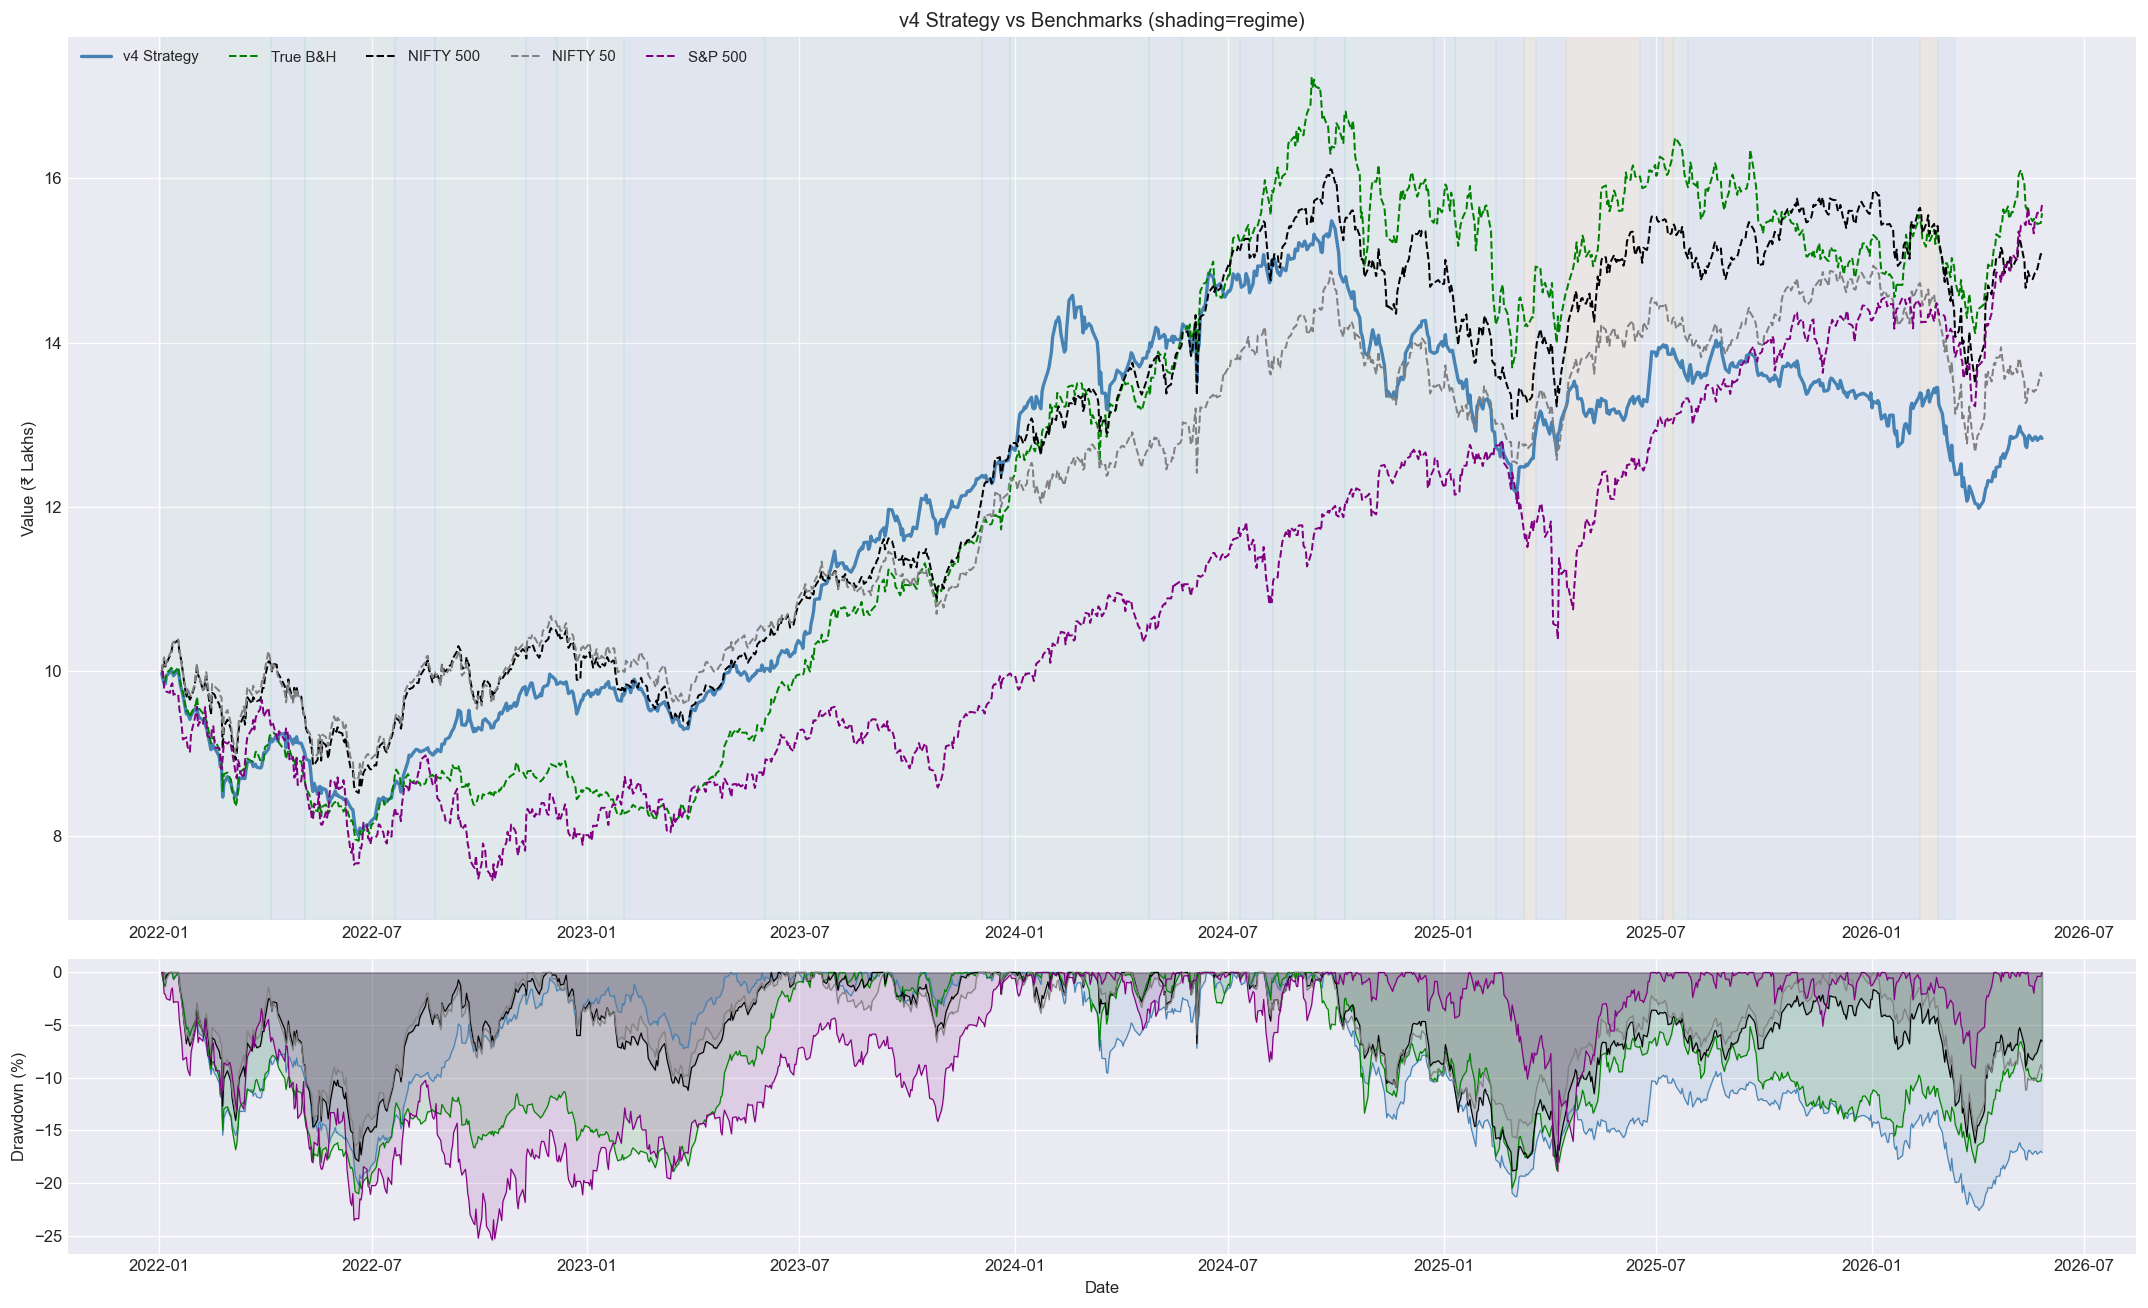

In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# Rebase every benchmark to the same starting capital on the same calendar, then
# compute the standard risk/return table against NIFTY 500 as primary benchmark.
# ─────────────────────────────────────────────────────────────────────────────
WF_S, WF_E = pd.Timestamp(CFG["WF_START"]), pd.Timestamp(CFG["WF_END"])
bt_dates = WF_EQ.index

def index_equity(series, capital):
    if series is None: return None
    s=series.reindex(bt_dates).ffill().dropna(); s=s[s.index>=WF_S]
    if s.empty: return None
    return capital*s/float(s.iloc[0])

NIF500_EQ=index_equity(BENCH["NIFTY500"], CFG["CAPITAL"])
NIF50_EQ =index_equity(BENCH["NIFTY50"],  CFG["CAPITAL"])
SP500_EQ =index_equity(BENCH["SP500"],    CFG["CAPITAL"])

# True buy-and-hold: take the first selection and never touch it again. This is
# the honest passive comparison for the stock-picking component.
first=WF_RECORDS[0]; iw={**first["weights"],"__CASH__":first["cash_alloc"]}
def true_bh(iw, rp, cap):
    tk=[t for t in iw if t!="__CASH__"]; w=np.array([iw[t] for t in tk]); cw=iw.get("__CASH__",0)
    eq=cap*(1-w.sum()*CFG["TRANSACTION_COST"]); cc=cap*cw; al=eq*w
    rd=rp.reindex(columns=tk).fillna(0); rd=rd[(rd.index>=WF_S)&(rd.index<=WF_E)]; out={}
    for d,row in rd.iterrows():
        al=al*np.exp(row.values); cc*=np.exp(DAILY_RF); out[d]=al.sum()+cc
    return pd.Series(out)
BH_EQ=true_bh(iw, RETURN_PANEL, CFG["CAPITAL"])

# Align every curve onto the common intersection of dates.
curves={"v4 Strategy":WF_EQ, "True B&H":BH_EQ}
if NIF500_EQ is not None: curves["NIFTY 500"]=NIF500_EQ
if NIF50_EQ  is not None: curves["NIFTY 50"]=NIF50_EQ
if SP500_EQ  is not None: curves["S&P 500"]=SP500_EQ
idx=bt_dates
for c in curves.values(): idx=idx.intersection(c.index)
curves={k:v.reindex(idx).ffill().dropna() for k,v in curves.items()}
PRIMARY_BENCH = curves.get("NIFTY 500", curves.get("NIFTY 50", BH_EQ.reindex(idx).ffill()))

def dret(eq): return eq.pct_change().dropna()
def metrics(eq, bench, name):
    r=dret(eq); b=dret(bench).reindex(r.index).dropna(); r=r.reindex(b.index)
    n=len(r); tot=float(eq.iloc[-1]/eq.iloc[0]-1); ann=(1+tot)**(TRADING_DAYS/n)-1
    vol=float(r.std())*np.sqrt(TRADING_DAYS); shp=(ann-CFG["RISK_FREE_RATE"])/(vol+1e-9)
    dd=float((eq/eq.cummax()-1).min()); cal=ann/(abs(dd)+1e-9)
    sl,ic_,rv,_,_=stats.linregress(b,r); beta=float(sl); alpha=float(ic_)*TRADING_DAYS
    act=r-b; te=float(act.std())*np.sqrt(TRADING_DAYS); ir=float(act.mean())*TRADING_DAYS/(te+1e-9)
    dn=float(r[r<DAILY_RF].std())*np.sqrt(TRADING_DAYS); srt=(ann-CFG["RISK_FREE_RATE"])/(dn+1e-9)
    return {"Strategy":name,"Total_Ret(%)":round(tot*100,2),"Ann_Ret(%)":round(ann*100,2),
            "Ann_Vol(%)":round(vol*100,2),"Sharpe":round(shp,3),"Sortino":round(srt,3),
            "Calmar":round(cal,3),"Max_DD(%)":round(dd*100,2),"Alpha(%)":round(alpha*100,2),
            "Beta":round(beta,3),"InfoRatio":round(ir,3),"TrackErr(%)":round(te*100,2),
            "Final(₹)":round(float(eq.iloc[-1]),0)}

PERF=pd.DataFrame([metrics(eq, PRIMARY_BENCH, n) for n,eq in curves.items()])
print("\n=== v4 PERFORMANCE vs BENCHMARKS (primary bench = NIFTY 500) ===\n")
print(PERF.set_index("Strategy").T.to_string())
PERF.to_csv(OUT / "v4_performance.csv", index=False)

# Equity curves shaded by regime, with drawdown paths underneath.
COL={"v4 Strategy":"steelblue","True B&H":"green","NIFTY 500":"black",
     "NIFTY 50":"grey","S&P 500":"purple"}
fig,(a1,a2)=plt.subplots(2,1,figsize=(18,11),gridspec_kw={"height_ratios":[3,1]})
for n,eq in curves.items():
    a1.plot(eq.index, eq.values/1e5, lw=2 if n=="v4 Strategy" else 1.2,
            color=COL.get(n,"orange"), label=n, linestyle="-" if n=="v4 Strategy" else "--")
prev,seg=None,None
for d,rg in REGIME.reindex(idx).ffill().items():
    if rg!=prev:
        if prev is not None: a1.axvspan(seg,d,alpha=0.05,color=REGIME_COLORS.get(prev,"grey"))
        seg,prev=d,rg
a1.set_ylabel("Value (₹ Lakhs)"); a1.set_title("v4 Strategy vs Benchmarks (shading=regime)")
a1.legend(fontsize=9,ncol=5)
for n,eq in curves.items():
    dd=(eq/eq.cummax()-1)*100; a2.fill_between(dd.index,dd.values,0,alpha=0.12,color=COL.get(n,"orange"))
    a2.plot(dd.index,dd.values,lw=0.7,color=COL.get(n,"orange"))
a2.set_ylabel("Drawdown (%)"); a2.set_xlabel("Date")
plt.tight_layout(); plt.savefig(OUT / "05_v4_equity.png", dpi=150); plt.show()


## 17b · Cost Attribution & Sensitivity

The gap between the gross and net equity curves, decomposed.

Because costs enter the equity path only as a multiplicative haircut at rebalance dates —
and do not change *which* stocks are held — an alternative cost assumption can be applied
analytically to the recorded per-rebalance buy and sell legs. The sensitivity grid below is
therefore **exact**, not a re-simulation.

Three findings:

**Cost is the whole story.** Gross of costs the strategy returns 13.4% annualised with a
Sharpe of 0.61 — comfortably ahead of the index. Net, it returns 5.9% with a Sharpe of
−0.05. The drag is 7.5 percentage points of annual return and 0.66 of Sharpe.

**The break-even is uncomfortably close.** With zero market impact (statutory costs only)
the strategy returns 9.6% and a Sharpe of 0.28; at 25 bps per side it returns 3.5%; at 40 bps
it returns nothing. For NIFTY-500 mid- and small-caps at institutional size, 15–25 bps per
side is the defensible central range — which puts the strategy right at the edge of viability
on the most uncertain input in the model. This is exactly why the grid should be reported
rather than a single point estimate.

**Event-driven rebalances roughly double the cost base.** They fire 44 times against 53
scheduled ones and carry *higher* mean turnover (0.54 vs 0.51), contributing 14.1% of the
16.1% total cost. They need to justify themselves with a measurable performance gain, and
testing that — event triggers on versus off — is the first experiment worth running from
here.

The clear implication for the next iteration: the binding constraint is turnover, not
signal. An L1 turnover penalty in the MVO objective, wider event triggers, and a longer
rebalance interval all attack the actual problem, and none of them touches the contribution.

In [35]:
# ─────────────────────────────────────────────────────────────────────────────
# COST ATTRIBUTION AND SENSITIVITY
#
# The grid below is EXACT, not a re-simulation. Costs enter the equity path only
# as a multiplicative haircut at each rebalance date, and they do not change WHICH
# stocks are held, so an alternative cost assumption can be applied analytically
# to the recorded per-rebalance buy_frac / sell_frac without re-running anything.
# ─────────────────────────────────────────────────────────────────────────────

def _perf(eq, rf=None):
    rf = CFG["RISK_FREE_RATE"] if rf is None else rf
    eq = eq.dropna()
    if len(eq) < 2:
        return {}
    r = eq.pct_change().dropna()
    yrs = max((eq.index[-1] - eq.index[0]).days / 365.25, 1e-9)
    tot = eq.iloc[-1] / eq.iloc[0] - 1
    ann = (1 + tot) ** (1 / yrs) - 1
    vol = r.std() * np.sqrt(TRADING_DAYS)
    dd  = (eq / eq.cummax() - 1).min()
    dr  = r[r < 0].std() * np.sqrt(TRADING_DAYS)
    return {"Total_Ret(%)": tot * 100, "Ann_Ret(%)": ann * 100,
            "Ann_Vol(%)": vol * 100,
            "Sharpe": (ann - rf) / vol if vol > 0 else np.nan,
            "Sortino": (ann - rf) / dr if dr and dr > 0 else np.nan,
            "Max_DD(%)": dd * 100,
            "Calmar": ann / abs(dd) if dd < 0 else np.nan,
            "Final(₹)": eq.iloc[-1]}


def _apply_cost_scenario(brokerage_bps=None, impact_bps=None, stt_bps=None):
    """Rebuild the net equity curve under an alternative cost assumption."""
    # Only the haircut changes; the gross path and the holdings are untouched.
    c = dict(CFG)
    if brokerage_bps is not None: c["COST_BROKERAGE_BPS"] = brokerage_bps
    if impact_bps    is not None: c["COST_IMPACT_BPS"]    = impact_bps
    if stt_bps       is not None:
        c["COST_STT_BUY_BPS"] = stt_bps; c["COST_STT_SELL_BPS"] = stt_bps
    r = cost_rates_bps(c)
    imp = 0.0 if c["COST_IMPACT_MODEL"] == "none" else c["COST_IMPACT_BPS"]

    haircut = pd.Series(1.0, index=WF_EQ_GROSS.index)
    for rec in WF_RECORDS:
        cf = (rec["buy_frac"]  * (r["buy_bps"]  + imp) / 1e4 +
              rec["sell_frac"] * (r["sell_bps"] + imp) / 1e4)
        d = rec["rebal_date"]
        idx = haircut.index[haircut.index.get_indexer([d], method="bfill")]
        if len(idx):
            haircut.loc[idx[0]] *= (1.0 - cf)
    return WF_EQ_GROSS * haircut.cumprod()


# ── gross vs net: the single most important comparison in the notebook ───────
_rows = {"GROSS (no costs, v5-comparable)": _perf(WF_EQ_GROSS),
         "NET (V6 India cost stack)":       _perf(WF_EQ)}
COST_ATTRIBUTION = pd.DataFrame(_rows).T.round(3)
print("=== V6 · GROSS vs NET PERFORMANCE ===\n")
print(COST_ATTRIBUTION.to_string())

_g, _n = _perf(WF_EQ_GROSS), _perf(WF_EQ)
print(f"\n  Cost drag: {_g['Ann_Ret(%)'] - _n['Ann_Ret(%)']:.2f} pp of annual return, "
      f"{_g['Sharpe'] - _n['Sharpe']:.3f} of Sharpe.")

# ── sensitivity grid on market impact — the only input that is not a published
#    statutory rate, and therefore the one that must be reported as a range ────
print("\n=== Cost sensitivity — market impact per side ===\n")
_sens = {}
for imp in [0.0, 5.0, 10.0, 15.0, 25.0, 40.0]:
    _sens[f"{imp:.0f} bps"] = _perf(_apply_cost_scenario(impact_bps=imp))
COST_SENSITIVITY = pd.DataFrame(_sens).T[
    ["Ann_Ret(%)", "Ann_Vol(%)", "Sharpe", "Max_DD(%)"]].round(3)
print(COST_SENSITIVITY.to_string())
print("\n  Impact is the only cost input that is not a published statutory rate,")
print("  so the paper should report this grid rather than a single point estimate.")
print("  For NIFTY-500 mid/small caps at institutional size, 15–25 bps per side")
print("  is the defensible central case.")

# ── turnover attribution: where is the cost actually being generated? ────────
_wf = pd.DataFrame(WF_RECORDS)
if len(_wf):
    print("\n=== Turnover & cost by rebalance trigger ===\n")
    _wf["trigger_type"] = _wf["trigger"].str.split(":").str[0]
    print(_wf.groupby("trigger_type").agg(
        n=("turnover", "size"), mean_turnover=("turnover", "mean"),
        mean_cost_bps=("cost_bps", "mean"), total_cost_pct=("cost_frac", lambda s: s.sum()*100)
    ).round(3).to_string())
    print("\n  Event-driven rebalances are pure incremental cost: if their mean")
    print("  turnover is comparable to scheduled ones, they roughly double the")
    print("  cost base and must be justified by a measurable performance gain.")

COST_ATTRIBUTION.to_csv(OUT / "cost_attribution.csv")
COST_SENSITIVITY.to_csv(OUT / "cost_sensitivity.csv")
if len(IC_TRACE_DF):
    IC_TRACE_DF.to_csv(OUT / "grinold_ic_trace.csv", index=False)
print("\n✅ Cost attribution and sensitivity saved.")


=== V6 · GROSS vs NET PERFORMANCE ===

                                 Total_Ret(%)  Ann_Ret(%)  Ann_Vol(%)  Sharpe  Sortino  Max_DD(%)  Calmar     Final(₹)
GROSS (no costs, v5-comparable)        73.664      13.393      11.302   0.610    0.834    -18.277   0.733  1737212.583
NET (V6 India cost stack)              28.697       5.913      11.377  -0.052   -0.070    -22.605   0.262  1283481.056

  Cost drag: 7.48 pp of annual return, 0.661 of Sharpe.

=== Cost sensitivity — market impact per side ===

        Ann_Ret(%)  Ann_Vol(%)  Sharpe  Max_DD(%)
0 bps        9.635      11.315   0.277    -19.791
5 bps        8.381      11.330   0.166    -20.301
10 bps       7.140      11.351   0.056    -21.014
15 bps       5.913      11.377  -0.052    -22.605
25 bps       3.499      11.446  -0.262    -25.695
40 bps      -0.025      11.590  -0.563    -30.107

  Impact is the only cost input that is not a published statutory rate,
  so the paper should report this grid rather than a single point estima

### Rolling Sharpe, Drawdowns & Rebalance Log

A 63-day rolling Sharpe ratio and the drawdown paths for every curve, followed by the
rebalance-by-rebalance diagnostic table — trigger type, regime, ADX, investable universe
size, number selected, turnover and cash weight.

The rebalance log is the most useful debugging artefact in the notebook. Reading down the
turnover column shows immediately where cost is being generated, and the trigger column
shows whether it came from the schedule or from an event.

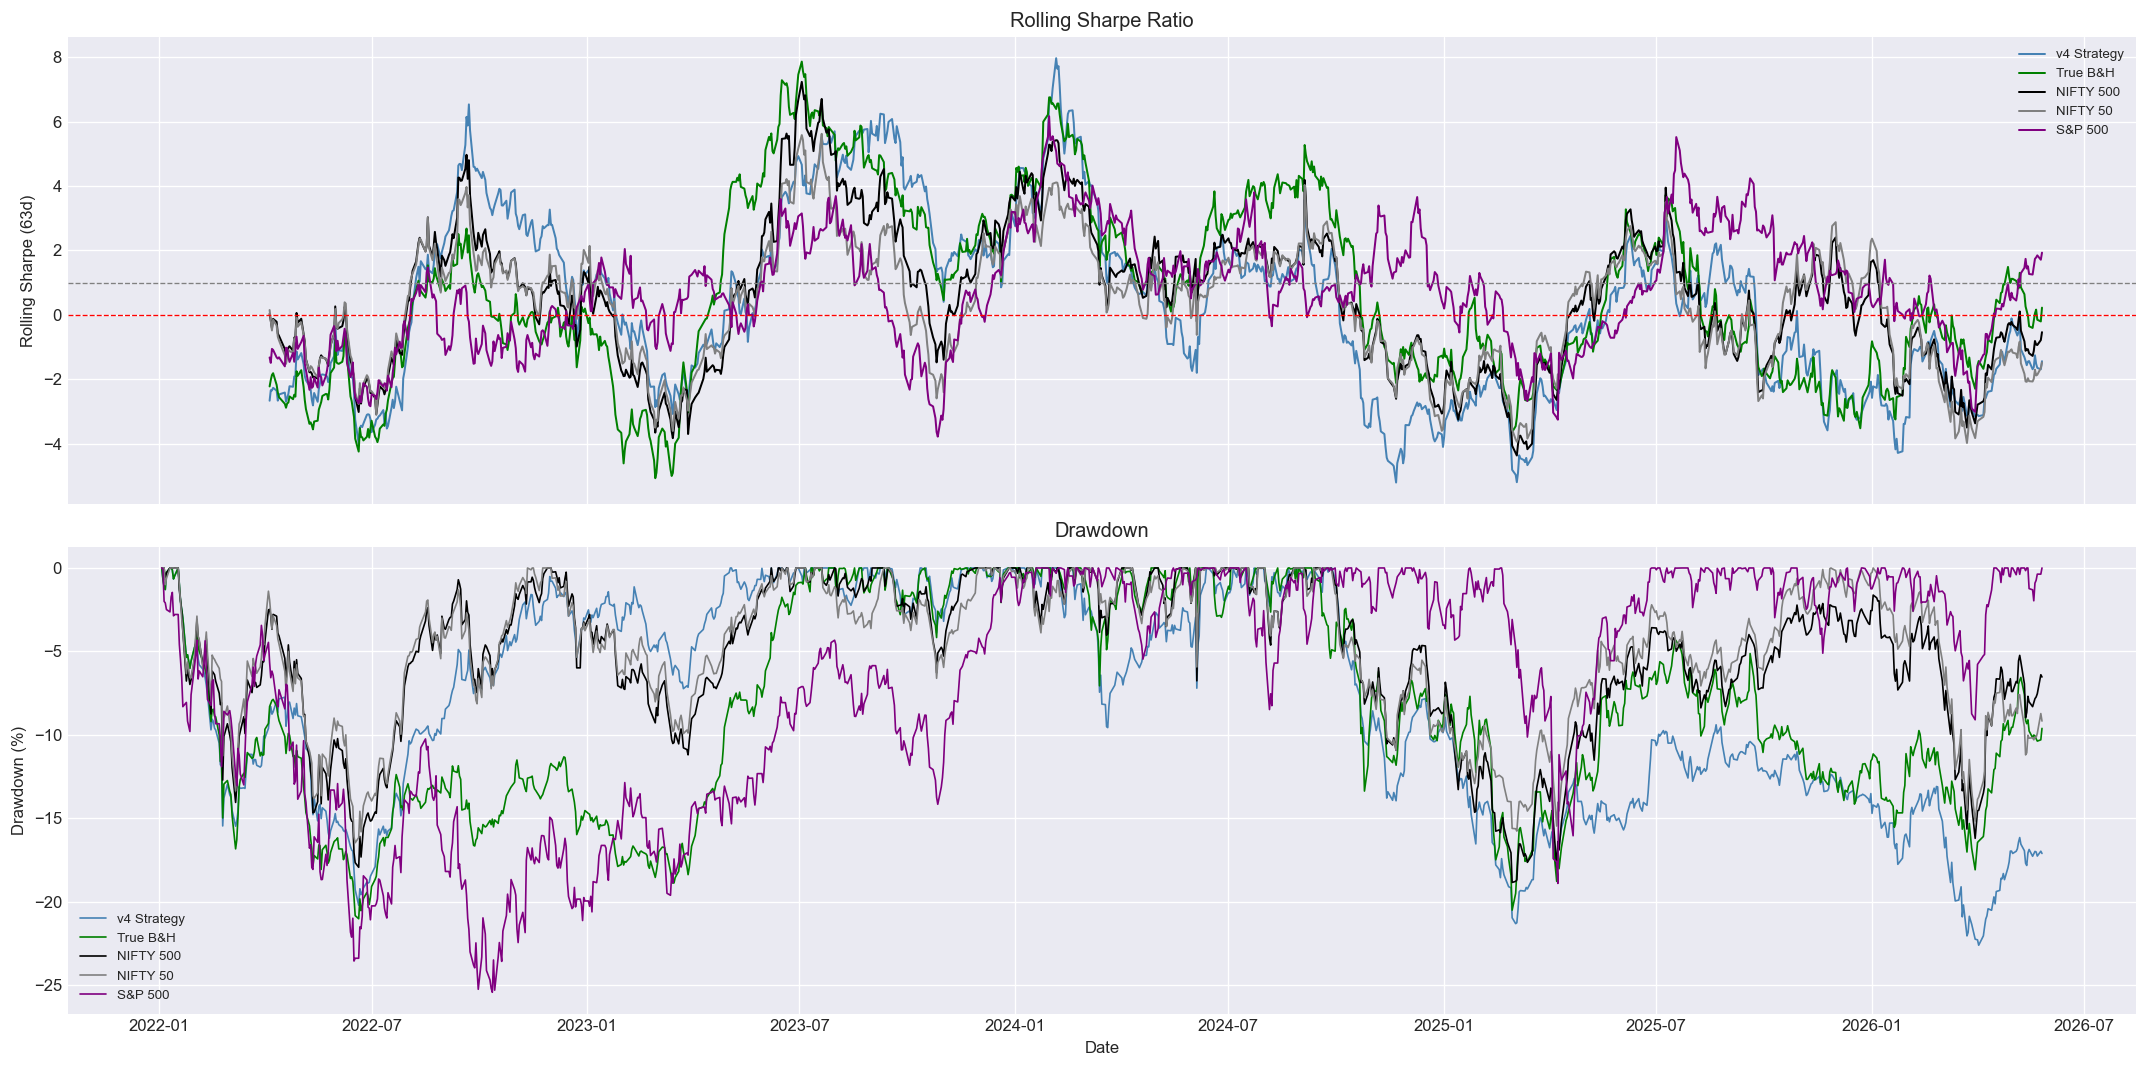

=== Walk-Forward Diagnostics (first 15 rows) ===
     Rebal               Trigger   Regime  ADX  N_Inv  N_Sel  Turnover  Cash%
2022-01-01                 SCHED     Bull 26.5    677     20     0.500    0.0
2022-02-01                 SCHED     Bull 23.8    677     20     0.500    0.0
2022-02-24         EVENT:Vol×1.9     Bull 26.7    679     20     0.283    0.0
2022-03-01                 SCHED     Bull 29.7    679     20     0.585    0.0
2022-04-01                 SCHED     Bull 16.3    680     20     0.430    0.0
2022-04-12 EVENT:Regime→Recovery Recovery 18.2    681     20     0.501   10.0
2022-04-26         EVENT:Vol×1.6 Recovery 17.8    681     20     0.717   10.0
2022-05-01                 SCHED Recovery 17.0    681     20     0.544   10.0
2022-05-11     EVENT:Regime→Bull     Bull 25.7    683     20     0.552    0.0
2022-06-01                 SCHED     Bull 23.4    686     20     0.526    0.0
2022-07-01                 SCHED     Bull 23.8    687     20     0.382    0.0
2022-07-27 EVEN

In [36]:
# Rolling Sharpe over a 63-day (one quarter) window, plus drawdown paths.
W=63
def roll_sharpe(eq,w=W):
    r=eq.pct_change().dropna()
    return (r.rolling(w).mean()-DAILY_RF)/(r.rolling(w).std()+1e-9)*np.sqrt(TRADING_DAYS)

fig,(a1,a2)=plt.subplots(2,1,figsize=(18,9),sharex=True)
for n,eq in curves.items():
    sharpe=roll_sharpe(eq)
    a1.plot(sharpe.index, sharpe.values, lw=1.2, color=COL.get(n,"orange"), label=n)
a1.axhline(1,color="grey",ls="--",lw=0.8); a1.axhline(0,color="red",ls="--",lw=0.8)
a1.set_ylabel("Rolling Sharpe (63d)"); a1.set_title("Rolling Sharpe Ratio"); a1.legend(fontsize=8)
for n,eq in curves.items():
    dd=(eq/eq.cummax()-1)*100
    a2.plot(dd.index,dd.values,lw=1,color=COL.get(n,"orange"),label=n)
a2.set_ylabel("Drawdown (%)"); a2.set_title("Drawdown"); a2.set_xlabel("Date"); a2.legend(fontsize=8)
plt.tight_layout(); plt.savefig(OUT / "06_rolling.png", dpi=150); plt.show()

# Rebalance-by-rebalance log. Reading down the turnover column shows where cost
# is generated; the trigger column shows whether it was scheduled or event-driven.
wf_diag=pd.DataFrame({
    "Rebal":[r["rebal_date"].date() for r in WF_RECORDS],
    "Trigger":[r["trigger"] for r in WF_RECORDS],
    "Regime":[r["regime"] for r in WF_RECORDS],
    "ADX":[round(r["adx"],1) for r in WF_RECORDS],
    "N_Inv":[r["n_investable"] for r in WF_RECORDS],
    "N_Sel":[len(r["selected"]) for r in WF_RECORDS],
    "Turnover":[round(r["turnover"],3) for r in WF_RECORDS],
    "Cash%":[round(r["cash_alloc"]*100,1) for r in WF_RECORDS],
})
print("=== Walk-Forward Diagnostics (first 15 rows) ===")
print(wf_diag.head(15).to_string(index=False))
wf_diag.to_csv(OUT / "wf_diagnostics.csv", index=False)
print(f"\nUniverse size at rebalances: min={wf_diag['N_Inv'].min()}, "
      f"max={wf_diag['N_Inv'].max()} (confirms evolving survivorship-aware universe)")

## 19 · Conclusions

### What this run establishes

The pipeline is methodologically clean on the four points that would otherwise invalidate
it. The regime signal at every rebalance is measurable with respect to information available
at that date, by construction rather than by assertion. The Grinold view scaling is
calibrated on cross-sections the scoring model never saw. Performance is reported net of a
fully itemised Indian cost stack. And the survivorship gap is measured and classified rather
than assumed away — 756 of 900 symbols recovered, with the 73 names that could actually
bias the out-of-sample window identified by name.

### What the numbers say

**Gross of costs, the strategy works.** 13.4% annualised, Sharpe 0.61, maximum drawdown
−18.3%, against 9.98% and 0.237 for NIFTY 500. The cross-sectional model has genuine skill:
rank-IC 0.034 with a HAC t-statistic of 3.64, above the Harvey-Liu-Zhu threshold of 3.0.
Beta of 0.58 and volatility of 11.4% against the index's 14.7% show the regime-conditioned
allocation is controlling risk as intended.

**Net of costs, it does not.** 5.9% annualised, Sharpe −0.05, information ratio −0.42.
Annualised one-way turnover near 1,160% at roughly 59 bps per round trip consumes 6.9% of
capital a year, which is more than the entire gross edge.

The diagnosis is unambiguous, and it is a good problem to have: the signal is real, the
implementation is too expensive. That is a solvable engineering problem, not a broken
hypothesis.

### Where to go next, in priority order

1. **Attack turnover.** It is the binding constraint and nothing else comes close. An L1
   turnover penalty in the MVO objective, a no-trade band around target weights, wider
   event-rebalance triggers, and a longer rebalance interval. None of these changes the
   contribution — they change the optimisation.
2. **Test whether event rebalances earn their keep.** They fire 44 times, carry higher
   turnover than scheduled rebalances, and account for nearly half the total cost. A single
   ablation with them switched off would settle it.
3. **Extend the walk-forward back to 2010.** The Crisis branch of the allocation table never
   activates between 2022 and 2026, so the mechanism designed for stressed markets is
   completely untested out-of-sample. Starting in 2010 puts 2011, 2013, 2015–16, 2018 and
   2020 inside the evaluation window.
4. **Fix the regime labels.** The ordering guard in §10 fails: the state labelled Correction
   carries a higher mean return than the one labelled Recovery. Either lengthen the feature
   window to 63 days, or drop drawdown from the health blend while keeping it as an emission
   feature, or report states by number with empirical descriptions. The state *series* is
   sound; the economic *names* attached to it are not yet defensible.

### Still outstanding for write-up

- Newey-West / HAC t-statistics reported throughout, not only on the cross-sectional IC.
- Harvey-Liu-Zhu multiple-testing adjustment across the factor and regime grid.
- Spanning regressions against the Agarwalla-Jacob-Varma Indian Fama-French-momentum
  factor library, to establish that the strategy is not simply a repackaging of known
  Indian factor premia.

- Point-in-time fundamentals, if institutional access to Prowess or Capitaline can be
  arranged, which would restore the value family as a robustness appendix.